# Notebook for compiling VGP level data of Keweenawan Track


- this notebook is modified from the Keweenawan Track compilation work of Swanson-Hysell et al., 2019 (http://dx.doi.org/10.1130/B31944.1)

- additional datasets include:
    - Duluth Complex (Swanson-Hysell et al. 2021)
    - Beaver Bay Complex (Zhang et al., 2021)
    - Cut Face Creek sandstone (Pierce et al., 2022)
    - Cardenas Basalt (Zhang et al., 2024)
    - Nonesuch Formation (Slotznick et al., 2023)

**Beyond what was done in Swanson-Hysell et al., 2019, we focus on compiling site-based VGP compilation in this study and will assign new columns named "height" (together with "height type" and  "height upper" and "height lower") to each compiled study. This column hosts stratigraphic heights to each site which can be used to take resampled age model results from Chron.jl Bayesian age models as a step in the bootstrap resampling routine. If the heights are not available for a study (usually legacy study), we will assign an estimated height or None and use the previous method of resampling from a uniform distribution or abnormal distribution. If the heights are available in terms of being correlated with another section, we can assign upper and lower heights and combining the resampling of heights with resampling of age models**

### controlled vocabulary for height type:
- bracket --- draw from a uniform distribution with the given height upper and height lower bracketing values
- exact --- exact as is in the height column
- none --- no height information available, use the traditional method of monte carlo resampling with either uniform or normal distribution based on the age, age upper, age lower columns


# Import libraries for data analysis

This code blocks imports necessary libraries and defines functions that will be used in the data analysis below. The code below  the pmag.py and ipmag.py modules of the the PmagPy software package (https://github.com/PmagPy/PmagPy). The other modules are currently included with standard scientific python distributions.

In [1]:
import pmagpy.pmag as pmag
import pmagpy.ipmag as ipmag

import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
import numpy as np
import scipy.stats as st
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
%config InlineBackend.figure_formats = 'retina'

Same as in Swanson-Hysellet al., 2019, let's create an empty dataframe that will be populated with pole means called 'pole_means'.

<b>PoleName | SLat | SLon | PLat | Plon | A95 | PolarityZone | PmagRef | AgeNominal | AgeLower | AgeUpper | AgeInfo | Q  </b>

<b>Pole_name</b> = Name of pole which corresponds to volcanic group <br>
<b>SLat</b> = Sample area decimal latitude (e.g. -56.2)<br>
<b>SLon</b> = Sample area decimal longitude (e.g. 134.8)<br>
<b>PLat</b> = Palaeomagnetic pole decimal latitude (e.g. -56.2)<br>
<b>PLon</b> = Palaeomagnetic pole decimal longitude (e.g. 134.8)<br>
<b>A95</b> = 95% confidence limit on pole in degrees (e.g. 6.2)<br>
<b>k</b> = Fisher precision parameter (e.g. 42.5)<br>
<b>N</b> = Number of VGPs used to calculate the mean<br>
<b>PolarityZone</b> = Assigned polarity zone<br>
<b>AgeNominal</b> = Mean / representative age of sampled formation (e.g. 1105.1)<br>
<b>AgeLower</b> = Estimate lower bound on age uncertainty (e.g. 1103.2)<br>
<b>AgeUpper</b> = Estimate upper bound on age uncertainty (e.g. 1107.4)<br>
<b>Gaussian_2sigma</b> = 2sigma error if Gaussian Distribution is to be used<br>
<b>GaussianOrUniform</b> = Distribution type used for Bayesian inversion<br>
<b>Q</b> = Van der Voo quality criteria (0 - 7)<br>


Because we are using MagIC format data files, we will also concatenate all site level data into a single dataframe for bootstrap resampling of VGP data and construct a VGP-based APWP. 

In [2]:
pole_means = pd.DataFrame(columns=['PoleName','SLat','SLon','PLat','PLon',
                                   'A95','K','N','PolarityZone','PmagRef',
                                   'AgeNominal','AgeLower','AgeUpper',
                                   'AgeInfo','AgeRef','Gaussian_2sigma',
                                   'GaussianOrUniform','Q','color'])

make color map for pole means plot

In [3]:
vmin = 1075
vmax = 1110
colormap = 'viridis_r'

color_mapping = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))

# Critical additional attributes compiled in this study

`age_model`: name of the age model to use for resampling site age associated with strat height

`height_type`: type of height data to use\
                uniform: need to resample for a height within the strat boundary and resampling age model to estimate age\
                exact: use the exact height value and only resample age model

`height`: strat height from the base of the stratigraphic section

`height_upper`: upper bound of the strat height

`height_lower`: lower bound of the strat height

`age`: nominal age for the pole mean

`age_high`: nominal upper age for the pole mean

`age_low`: nominal lower age for the pole mean

`age_uncertainty`: type of age uncertainty\
                uniform: use uniform distribution for resampling nominal age\
                normal: use normal distribution for resampling nominal age\

`dir_k`: Fisher precision parameter at the site level
          This is a critical parameter to have for the resampling algorithm \
          if the original dataset does not have this value, we need to assign one. \
          either take the site-mean precision parameter or assign a value based on the total average of the entire compilation\
          
`dir_alpha95`: 95% confidence limit on pole in degrees at the site level
          if the original dataset has alpha95 and n, but not k, we can calculate k using those values

`dir_f`: flattening facttor at the site level
          for igneous units, this is set to 1
          for sedimentary units, in this compilation we have Cut Face Creek sandstone, Nonesuch Shale, and Freda Formation
            we use the E/I output values for Cut Face Creek (Pierce et al., 2022) and draw resamples
            we use the E/I output values for Nonesuch Shale (Slotznick et al., 2023) and draw resamples
            we use the Nonesuch values for Freda data from Henry, 1977 since we do not have enough new data now to esimate f distribution

# Data compilation by volcanic sections

## Osler Volcanic Group

### Import Halls (1974) data

- H. C. Halls. 1974. A Paleomagnetic Reversal in the Osler Volcanic Group, Northern Lake Superior. Canadian Journal of Earth Sciences. 11(9): 1200-1207. https://doi.org/10.1139/e74-113

Swanson-Hysell et al., 2019 interpreted that all of Halls (1974) data are from roughly the same as the upper 1/3 of the Simpson Island section lava flows (>2082 m in their section). Therefore, we assign the height type for this study to be uniform, height lower to be 2082 m, and height upper to be 3200 m (estimated top of the section which is also used for the upper end of the age model).

In [4]:
Halls1974_sites = pd.read_csv('../data/pmag_compiled/Halls1974/sites.txt',sep='\t',header=1)
Halls1974_sites['geologic_classes'] = 'Extrusive:Igneous'
Halls1974_sites = Halls1974_sites[Halls1974_sites['dir_tilt_correction']==100]
Halls1974_sites['citations'] = 'Halls, 1974'
# use sample n and dir_k to calculate dir_alpha95
Halls1974_sites['dir_alpha95'] = 140/np.sqrt(Halls1974_sites['dir_n_samples']*Halls1974_sites['dir_k'])
# # Halls1974_sites

We are interested in using tilt-corrected data so will filter the DataFrame such that only data with dir_tilt_correction of 100 are included. We also wish to consider data from reversed and normal flows separately so will create DataFrames for each polarity.

In [5]:
Halls1974_sites_r = Halls1974_sites[Halls1974_sites['location']=='Osler Volcanics, Nipigon Strait, Lower Reversed'].reset_index(drop=True)
Halls1974_sites_r['dir_polarity'] = 'r'
# assign ages to Halls 1974 sites in the same way as Swanson-Hysell et al., 2019 but we won't be using it for the age model and the APWP
Halls1974_sites_r['age_model'] = 'Osler Volcanic Group'
Halls1974_sites_r['height_type'] = 'uniform'
Halls1974_sites_r['height'] = (2082+3200)/2 # calculate an average height for the site as a nominal value
Halls1974_sites_r['height_lower'] = 2082
Halls1974_sites_r['height_upper'] = 3200
Halls1974_sites_r['age'] = 1105.15
Halls1974_sites_r['age_high'] = 1105.48
Halls1974_sites_r['age_low'] = 1104.82
Halls1974_sites_r['age_unit'] = 'Ma'
Halls1974_sites_r['age_uncertainty'] = 'gaussian'
Halls1974_sites_r['dir_f'] = 1.0

Halls1974_sites_n = Halls1974_sites[Halls1974_sites['location']=='Osler Volcanics, Nipigon Strait, Upper Normal'].reset_index(drop=True)
Halls1974_sites_n['age_model'] = None
Halls1974_sites_n['height_type'] = None
Halls1974_sites_n['height'] = None
Halls1974_sites_n['height_lower'] = None
Halls1974_sites_n['height_upper'] = None
Halls1974_sites_n['dir_polarity'] = 'n'
Halls1974_sites_n['age'] = 1095
Halls1974_sites_n['age_high'] = 1100
Halls1974_sites_n['age_low'] = 1080
Halls1974_sites_n['age_unit'] = 'Ma'
Halls1974_sites_n['age_uncertainty'] = 'uniform'
Halls1974_sites_n['dir_f'] = 1.0

### Import Swanson-Hysell et al. (2014b) data

- Swanson-Hysell, N. L., Vaughan, A. A., Mustain, M. R., & Asp, K. E. (2014). Confirmation of progressive plate motion during the Midcontinent Rift’s early magmatic stage from the Osler Volcanic Group, Ontario, Canada. Geochemistry, Geophysics, Geosystems, 15(5), 2039–2047. https://doi.org/10.1002/2013gc005180


Split Swanson-Hysell et al. (2014b) data by stratigraphic posiition into the lower and upper third and then combine the data from the upper third with the reversed data from the Halls (1974) Nipigon Strait region study as done in Swanson-Hysell et al. (2014b) using the same stratigraphic levels.

In [6]:
SH2014_sites = pd.read_csv('../data/pmag_compiled/Swanson-Hysell2014b/sites.txt',sep='\t',header=1)
SH2014_sites['citations'] = 'Swanson-Hysell et al. 2014'
SH2014_sites['geologic_classes'] = 'Extrusive:Igneous'
SH2014_sites['dir_tilt_correction'] = 100
# filter out the rows with empty direction values
SH2014_sites = SH2014_sites[~SH2014_sites['dir_dec'].isna()]
SH2014_sites['dir_f'] = 1.0
# assign height type to be exact since the heights are known
SH2014_sites['age_model'] = 'Osler Volcanic Group'
SH2014_sites['height_type'] = 'exact'
SH2014_sites['height_lower'] = None
SH2014_sites['height_upper'] = None
# use sample n and dir_alpha95 to calculate dir_k
SH2014_sites['dir_n_samples'] = SH2014_sites['dir_n_specimens']
SH2014_sites['dir_k'] = 140**2/SH2014_sites['dir_alpha95']**2/SH2014_sites['dir_n_specimens']

SH2014_OslerR_lower = SH2014_sites[SH2014_sites.height<1041]
SH2014_OslerR_upper = SH2014_sites[SH2014_sites.height>2082]

SH2014_OslerR_lower['age'] = 1108
SH2014_OslerR_lower['age_high'] = 1110
SH2014_OslerR_lower['age_low'] = 1105.15
SH2014_OslerR_lower['age_uncertainty'] = 'uniform'

SH2014_OslerR_upper['age'] = 1105.15
SH2014_OslerR_upper['age_high'] = 1105.48
SH2014_OslerR_upper['age_low'] = 1104.82
SH2014_OslerR_upper['age_uncertainty'] = 'gaussian'

### Import Swanson-Hysell et al., 2019 data

- Swanson-Hysell, N. L., Ramezani, J., Fairchild, L. M., & Rose, I. R. (2019). Failed rifting and fast drifting: Midcontinent Rift development, Laurentia’s rapid motion and the driver of Grenvillian orogenesis. GSA Bulletin, 131(5–6), 913–940. https://doi.org/10.1130/b31944.1


In [7]:
new_Osler_sites = pd.read_csv('../data/pmag_compiled/Swanson-Hysell2019a/Agate_point/sites.txt',
                              sep='\t',skiprows=1)
new_Osler_sites['geologic_classes'] = 'Extrusive:Igneous'

# we need to also load the samples file to get the straight heights for the sites
new_Osler_samples = pd.read_csv('../data/pmag_compiled/Swanson-Hysell2019a/Agate_point/samples.txt', sep='\t',skiprows=1)
new_Osler_site_heights = new_Osler_samples.groupby('site').apply(lambda x: x['height'].mean())
new_Osler_sites['height'] = new_Osler_sites['site'].map(new_Osler_site_heights)
# this height then need to be recalibrated to the total Osler age model's datum
# the sites are below the AP7 geochron sample which is estimated to be at 3200 meters along the Osler strat
# strat height of AP7 in the Agate Point section is 81.9, so we calculate the strat distance between that the sites and subtract that from 3200
new_Osler_sites_tiltcorrected = new_Osler_sites[new_Osler_sites.dir_tilt_correction == 100]
new_Osler_sites_tiltcorrected['dir_f'] = 1.0

new_Osler_sites_AP = new_Osler_sites_tiltcorrected[new_Osler_sites_tiltcorrected.location == 'Agate Point']
new_Osler_sites_AP['age_model'] = 'Osler Volcanic Group'
new_Osler_sites_AP['height_type'] = 'exact'
new_Osler_sites_AP['height_lower'] = None
new_Osler_sites_AP['height_upper'] = None
new_Osler_sites_AP['age'] = 1108
new_Osler_sites_AP['age_high'] = 1110
new_Osler_sites_AP['age_low'] = 1105.15
new_Osler_sites_AP['age_uncertainty'] = 'uniform'
new_Osler_sites_AP['height'] = 3200-(81.9-new_Osler_sites['height'])
new_Osler_sites_AP['dir_polarity'] = 'r'

# Puff Island is the same normal polarity zone poles above the unconformity 
new_Osler_sites_Puff = new_Osler_sites_tiltcorrected[new_Osler_sites_tiltcorrected.location == 'Puff Island']
new_Osler_sites_Puff['age'] = 1095
new_Osler_sites_Puff['age_high'] = 1100
new_Osler_sites_Puff['age_low'] = 1080
new_Osler_sites_Puff['age_uncertainty'] = 'uniform'
new_Osler_sites_Puff['age_model'] = None
new_Osler_sites_Puff['height'] = None
new_Osler_sites_Puff['height_type'] = None
new_Osler_sites_Puff['height_lower'] = None
new_Osler_sites_Puff['height_upper'] = None
new_Osler_sites_Puff['dir_polarity'] = 'n'
# new_Osler_sites

In [8]:
SH2014_OslerR_lower_vgps = ipmag.make_di_block(SH2014_OslerR_lower['vgp_lon'].tolist(),
                              SH2014_OslerR_lower['vgp_lat'].tolist())
SH2014_OslerR_upper_vgps = ipmag.make_di_block(SH2014_OslerR_upper['vgp_lon'].tolist(),
                              SH2014_OslerR_upper['vgp_lat'].tolist())
Halls1974_OslerR_vgps = ipmag.make_di_block(Halls1974_sites_r['vgp_lon'].tolist(),
                              Halls1974_sites_r['vgp_lat'].tolist())
AgatePoint_OslerR_vgps = ipmag.make_di_block(new_Osler_sites_AP['vgp_lon'].tolist(),
                              new_Osler_sites_AP['vgp_lat'].tolist())
AgatePoint_OslerR_vgps = ipmag.do_flip(di_block=AgatePoint_OslerR_vgps)

### Osler reverse (R1; lower Alona Bay reversed-polarity zone) pole

In [9]:
Osler_reverse_lower_site = SH2014_OslerR_lower
Osler_reverse_lower_site['pole_name'] = 'Osler reverse lower'
Osler_reverse_lower_site['dir_polarity'] = 'r'
Osler_reverse_lower_site['geologic_classes'] = 'Extrusive:Igneous'
Osler_reverse_lower_site['geologic_types'] = 'Lava Flow'
Osler_reverse_lower_site['lithologies'] = 'Basalt'
# Osler_reverse_lower_site

In [10]:
Osler_lowerR_pole = pmag.fisher_mean(SH2014_OslerR_lower_vgps)
ipmag.print_pole_mean(Osler_lowerR_pole)

Plon: 218.6  Plat: 40.9
Number of directions in mean (n): 30
Angular radius of 95% confidence (A_95): 4.8
Precision parameter (k) estimate: 31.5


### Osler reverse (R2; upper Alona Bay reversed-polarity zone) pole

In [11]:
Osler_reverse_upper_site = pd.concat([SH2014_OslerR_upper, Halls1974_sites_r]).reset_index(drop=True)
Osler_reverse_upper_site['dir_tilt_correction'] = 100
Osler_reverse_upper_site['pole_name'] = 'Osler reverse upper'
Osler_reverse_upper_site['dir_polarity'] = 'r'
Osler_reverse_upper_site['geologic_classes'] = 'Extrusive:Igneous'
Osler_reverse_upper_site['geologic_types'] = 'Lava Flow'
Osler_reverse_upper_site['lithologies'] = 'Basalt'
# Osler_reverse_upper_site

In [12]:
Osler_upperR_pole_new = pmag.fisher_mean(SH2014_OslerR_upper_vgps+Halls1974_OslerR_vgps+AgatePoint_OslerR_vgps)
ipmag.print_pole_mean(Osler_upperR_pole_new)

Plon: 203.4  Plat: 42.3
Number of directions in mean (n): 64
Angular radius of 95% confidence (A_95): 3.7
Precision parameter (k) estimate: 24.4


These mean poles can be added to the pole_means dataframe. In terms of Q factor, a fold test on the Osler R2 pole utilizing the directional data of both Halls (1974) and Swanson-Hysell et al. (2014b) passes Tauxe and Watson (1994) and McFadden and McElhinny (1990) fold tests (Tauxe et al., 2016). Given evidence for early tilting (e.g. the angular unconformity associated with the syn-rift volcanism Puff Island Conglomerate), this test provided evidence for a primary origin of magnetization. The Osler reverse (lower) data have no such test, although there are younger dikes of normal polarity within the reversed volcanics (that likely correspond to Portage Lake normal-polarity zone) providing additional evidence that the reversed volcanics have not be remagnetized. Buchan et al. (2001) considered the reversed Osler Volcanic Group pole to be a "key pole" and made the additional argument that the unconformity test provides strong evidence for a primary origin of remanence:

> Remanence is considered primary because the position of the prominent Keweenawan polarity reversal in the Upper Osler lavas coincides exactly with the position of an unconformity in the sequence (Halls, 1974).

### Osler normal pole

The study of Halls (1974) included 5 normal sites and previous poles utilizing these data have calculated a mean pole wherein each of these sites is equally weighted (e.g. Halls and Pesonen, 1982). However, field mapping by Swanson-Hysell and Fairchild in July 2014 of the Osler Volcanic Group in the vicinity of Puff Island in the Lake Superior Archipelago revealed that the 5 normal sites of Halls (1974) are from a total of two flows. Sites 1, 2 and 5 are all from the first thick flow above the Puff Island conglomerate while sites 3 and 4 are from a single flow that forms the SSE shoreline of Puff Island and Tremblay Island.

To deal with the multiple sites from the same flow, we can calculate the mean direction of the Halls (1974) "sites" for each flow and then calculate the VGP from that mean direction. This method isn't ideal as it would be preferable to calculate Fisher means from the sample level data, but these data are not published.

In [13]:
Halls1974_sites_n

,bed_dip,bed_dip_direction,citations,dir_dec,dir_inc,dir_k,dir_n_samples,dir_polarity,dir_tilt_correction,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_type,site,vgp_lat,vgp_lon,dir_alpha95,age_model,height_type,height,height_lower,height_upper,age,age_high,age_low,age_unit,age_uncertainty,dir_f
0,10,135,"Halls, 1974",289.8,43.6,517,5,n,100,Extrusive:Igneous,Lava Flow,48.626429,Basalt,"Osler Volcanics, Nipigon Strait, Upper Normal",271.894142,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,i,1,31.651552,185.574506,2.753580,None,None,None,None,None,1095,1100,1080,Ma,uniform,1.0
1,12,140,"Halls, 1974",285.7,42.0,243,5,n,100,Extrusive:Igneous,Lava Flow,48.637185,Basalt,"Osler Volcanics, Nipigon Strait, Upper Normal",271.913846,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,i,2,28.110086,187.514758,4.016427,None,None,None,None,None,1095,1100,1080,Ma,uniform,1.0
2,14,146,"Halls, 1974",307.4,37.9,2485,5,n,100,Extrusive:Igneous,Lava Flow,48.640811,Basalt,"Osler Volcanics, Nipigon Strait, Upper Normal",271.928039,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,i,3,40.260604,167.886292,1.255972,None,None,None,None,None,1095,1100,1080,Ma,uniform,1.0
3,12,135,"Halls, 1974",302.8,29.9,331,5,n,100,Extrusive:Igneous,Lava Flow,48.655732,Basalt,"Osler Volcanics, Nipigon Strait, Upper Normal",271.959099,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,i,4,33.460215,167.498810,3.441352,None,None,None,None,None,1095,1100,1080,Ma,uniform,1.0
4,10,135,"Halls, 1974",294.7,42.5,130,5,n,100,Extrusive:Igneous,Lava Flow,48.661489,Basalt,"Osler Volcanics, Nipigon Strait, Upper Normal",271.958187,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,i,5,34.309263,181.256819,5.491252,None,None,None,None,None,1095,1100,1080,Ma,uniform,1.0


In [14]:
#Halls flow #1 is sites 1, 2 and 5 which we can separate out into a new list of directions
Halls_N_flow1_directions=[]
Halls_N_flow1_directions.append([Halls1974_sites_n.dir_dec[0], Halls1974_sites_n.dir_inc[0]])
Halls_N_flow1_directions.append([Halls1974_sites_n.dir_dec[1], Halls1974_sites_n.dir_inc[1]])
Halls_N_flow1_directions.append([Halls1974_sites_n.dir_dec[4], Halls1974_sites_n.dir_inc[4]])

#take the Fisher mean of flow 1 directions
Halls_N_flow1_mean=pmag.fisher_mean(Halls_N_flow1_directions)

#Halls flow #2 is sites 3 and 4 which we can separate out into a new list of directions
Halls_N_flow2_directions=[]
Halls_N_flow2_directions.append([Halls1974_sites_n.dir_dec[2], Halls1974_sites_n.dir_inc[2]])
Halls_N_flow2_directions.append([Halls1974_sites_n.dir_dec[3], Halls1974_sites_n.dir_inc[3]])

#take the Fisher mean of flow 2 directions
Halls_N_flow2_mean = pmag.fisher_mean(Halls_N_flow2_directions)

#create a new data frame and insert the data for the two flows (making sure that the values are floats)
Halls1974_Osler_Data_N_new = pd.DataFrame(columns=['age', 'age_high', 'age_low', 'age_unit', 'citations',
                                                    'criteria', 'dir_alpha95', 'dir_dec', 'dir_inc',
                                                    'dir_k', 'dir_n_samples', 'dir_n_specimens', 
                                                    'dir_n_specimens_lines', 'dir_n_specimens_planes', 'dir_polarity', 'dir_r',
                                                    'dir_tilt_correction', 'lat', 'location', 'lon', 'method_codes',
                                                    'result_quality', 'result_type', 'site']) 


Halls1974_Osler_Data_N_new.loc[0]=pd.Series({'name':'Halls_N_flow1', 
                                   'lat':Halls1974_sites_n.lat[0],
                                   'lon':Halls1974_sites_n.lon[0],
                                   'dir_dec':Halls_N_flow1_mean['dec'],
                                   'dir_inc':Halls_N_flow1_mean['inc'], 
                                   'dir_alpha95':Halls_N_flow1_mean['alpha95'],
                                   'dir_k':Halls_N_flow1_mean['k'],
                                   'dir_n_samples':Halls_N_flow1_mean['n'], 
                                   'dir_n_specimens':Halls_N_flow1_mean['n'], 
                                   'dir_n_specimens_lines':	Halls_N_flow1_mean['n'],
                                   'dir_n_specimens_planes':0,
                                   'dir_polarity':'n', 
                                   'dir_r':Halls_N_flow1_mean['r'],
                                   'dir_tilt_correction':100,
                                   'location':'Osler Volcanics, Nipigon Strait, Upper Normal', 
                                   'method_codes':'DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE', 
                                   'result_quality':'g',
                                   'result_type':'i',
                                   'site':'flow 1',
                                   })

Halls1974_Osler_Data_N_new.loc[1]=pd.Series({'name':'Halls_N_flow2', 
                                   'lat':Halls1974_sites_n.lat[2],
                                   'lon':Halls1974_sites_n.lon[2],
                                   'dir_dec':Halls_N_flow2_mean['dec'],
                                   'dir_inc':Halls_N_flow2_mean['inc'],
                                   'dir_alpha95':Halls_N_flow2_mean['alpha95'],
                                   'dir_k':Halls_N_flow2_mean['k'],
                                   'dir_n_samples':Halls_N_flow2_mean['n'], 
                                   'dir_n_specimens':Halls_N_flow2_mean['n'], 
                                   'dir_n_specimens_lines':	Halls_N_flow2_mean['n'],
                                   'dir_n_specimens_planes':0,
                                   'dir_polarity':'n', 
                                   'dir_r':Halls_N_flow2_mean['r'],
                                   'dir_tilt_correction':100,
                                   'location':'Osler Volcanics, Nipigon Strait, Upper Normal', 
                                   'method_codes':'DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE', 
                                   'result_quality':'g',
                                   'result_type':'i',
                                   'site':'flow 2',
                                   })
Halls1974_Osler_Data_N_new['geologic_classes'] = 'Extrusive:Igneous'    
Halls1974_Osler_Data_N_new['age'] = 1095
Halls1974_Osler_Data_N_new['age_high'] = 1100
Halls1974_Osler_Data_N_new['age_low'] = 1080
Halls1974_Osler_Data_N_new['age_unit'] = 'Ma'
Halls1974_Osler_Data_N_new['age_uncertainty'] = 'uniform'
Halls1974_Osler_Data_N_new['criteria'] = 'ACCEPT'
Halls1974_Osler_Data_N_new['citations'] = 'Halls, 1974'
Halls1974_Osler_Data_N_new['height'] = None
Halls1974_Osler_Data_N_new['height_type'] = None
Halls1974_Osler_Data_N_new['height_lower'] = None
Halls1974_Osler_Data_N_new['height_upper'] = None
Halls1974_Osler_Data_N_new['age_model'] = None
Halls1974_Osler_Data_N_new['dir_polarity'] = 'n'

Halls1974_Osler_Data_N_new['dir_dec'] = Halls1974_Osler_Data_N_new['dir_dec'].astype(float)
Halls1974_Osler_Data_N_new['dir_inc'] = Halls1974_Osler_Data_N_new['dir_inc'].astype(float)
Halls1974_Osler_Data_N_new['lat'] = Halls1974_Osler_Data_N_new['lat'].astype(float)
Halls1974_Osler_Data_N_new['lon'] = Halls1974_Osler_Data_N_new['lon'].astype(float)

#calculate VGPs from the directional data
ipmag.vgp_calc(Halls1974_Osler_Data_N_new, site_lon='lon', site_lat= 'lat', tilt_correction='yes', dec_tc= 'dir_dec', inc_tc='dir_inc')

OslerN_VGPs_Halls=[]
OslerN_Plong_Halls=[]
OslerN_Plat_Halls=[]

for n in range(0,len(Halls1974_Osler_Data_N_new)): 
    Plong,Plat=Halls1974_Osler_Data_N_new['vgp_lon'][n],Halls1974_Osler_Data_N_new['vgp_lat'][n]
    OslerN_Plong_Halls.append(Plong)
    OslerN_Plat_Halls.append(Plat)
    OslerN_VGPs_Halls.append([Plong,Plat,1.])

In [15]:
Halls1974_Osler_Data_N_new

,age,age_high,age_low,age_unit,citations,criteria,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,location,lon,method_codes,result_quality,result_type,site,geologic_classes,age_uncertainty,height,height_type,height_lower,height_upper,age_model,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev
0,1095,1100,1080,Ma,"Halls, 1974",ACCEPT,5.209164,290.056345,42.759311,561.125759,3,3,3,0,n,2.996436,100,48.626429,"Osler Volcanics, Nipigon Strait, Upper Normal",271.894142,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,g,i,flow 1,Extrusive:Igneous,uniform,None,None,None,None,None,24.813270,31.377146,184.834197,-31.377146,4.834197
1,1095,1100,1080,Ma,"Halls, 1974",ACCEPT,19.429406,304.991868,33.921333,167.319021,2,2,2,0,n,1.994023,100,48.640811,"Osler Volcanics, Nipigon Strait, Upper Normal",271.928039,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,g,i,flow 2,Extrusive:Igneous,uniform,None,None,None,None,None,18.585545,36.754929,167.666250,-36.754929,347.666250


In addition to the two flows above the angular unconformity studied by Halls (1974), we identified, sampled and developed data from two other flows exposed above the unconformity on Puff Island. After calculating each VGP, we can calculate a new mean pole for the Osler normal polarity volcanics. There are only 4 VGPs from which the Osler normal pole can be calculated making it so that the pole is not robust. There is little prospect for significant improvement of the pole as there only appear to be four flows in total exposed above the Puff Island conglomerate at the current water level of Lake Superior.

In [16]:
PuffIsland_OslerN_vgps = ipmag.make_di_block(new_Osler_sites_Puff['vgp_lon'].tolist(),
                              new_Osler_sites_Puff['vgp_lat'].tolist())
# OslerN_VGPs_Halls = ipmag.make_di_block(Halls1974_Osler_Data_N_new['vgp_lon'].tolist(),
#                               Halls1974_Osler_Data_N_new['vgp_lat'].tolist())

OslerN_pole = pmag.fisher_mean(OslerN_VGPs_Halls+PuffIsland_OslerN_vgps) 
ipmag.print_pole_mean(OslerN_pole)

Plon: 171.9  Plat: 32.0
Number of directions in mean (n): 4
Angular radius of 95% confidence (A_95): 9.7
Precision parameter (k) estimate: 90.9


In [17]:
Osler_normal_site = pd.concat([Halls1974_Osler_Data_N_new, new_Osler_sites_Puff]).reset_index(drop=True)
Osler_normal_site['pole_name'] = 'Osler normal'
Osler_normal_site['dir_polarity'] = 'n'
Osler_normal_site['age_uncertainty'] = 'uniform'
Osler_normal_site['dir_f'] = 1.0
Osler_normal_site['citations'] = 'Halls, 1974:Swanson-Hysell et al., 2019'
Osler_normal_site['geologic_classes'] = 'Extrusive:Igneous'
Osler_normal_site['geologic_types'] = 'Lava Flow'
Osler_normal_site['lithologies'] = 'Basalt'
Osler_normal_site.head()

,age,age_high,age_low,age_unit,citations,criteria,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,location,lon,method_codes,result_quality,result_type,site,geologic_classes,age_uncertainty,height,height_type,height_lower,height_upper,age_model,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,age_sigma,dir_comp_name,samples,software_packages,specimens,vgp_dm,vgp_dp,dir_f,pole_name,geologic_types,lithologies
0,1095,1100,1080,Ma,"Halls, 1974:Swanson-Hysell et al., 2019",ACCEPT,5.209164,290.056345,42.759311,561.125759,3,3,3,0,n,2.996436,100,48.626429,"Osler Volcanics, Nipigon Strait, Upper Normal",271.894142,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,g,i,flow 1,Extrusive:Igneous,uniform,None,None,None,None,None,24.813270,31.377146,184.834197,-31.377146,4.834197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Osler normal,Lava Flow,Basalt
1,1095,1100,1080,Ma,"Halls, 1974:Swanson-Hysell et al., 2019",ACCEPT,19.429406,304.991868,33.921333,167.319021,2,2,2,0,n,1.994023,100,48.640811,"Osler Volcanics, Nipigon Strait, Upper Normal",271.928039,DE-K:FS-FD:FS-H:LP-DC2:SO-SM:DE-DI:FS-LOC-GOOGLE,g,i,flow 2,Extrusive:Igneous,uniform,None,None,None,None,None,18.585545,36.754929,167.666250,-36.754929,347.666250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Osler normal,Lava Flow,Basalt
2,1095,1100,1080,Ma,"Halls, 1974:Swanson-Hysell et al., 2019",ACCEPT,3.8,303.400000,25.200000,219,8,8,8,0,n,7.968,100,48.700000,Puff Island,-88.000000,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,Puf1,Extrusive:Igneous,uniform,None,None,None,None,None,NaN,31.700000,164.800000,NaN,NaN,1.0,mag,Puf1-1:Puf1-2:Puf1-3:Puf1-4:Puf1-5:Puf1-6:Puf1-7:Puf1-8,pmagpy-3.4.1: demag_gui.v.3.0,Puf1-1a:Puf1-2a:Puf1-3a:Puf1-4a:Puf1-5a:Puf1-6a:Puf1-7a:Puf1-8a,4.1,2.2,1.0,Osler normal,Lava Flow,Basalt
3,1095,1100,1080,Ma,"Halls, 1974:Swanson-Hysell et al., 2019",ACCEPT,3.5,296.900000,24.700000,293,7,7,7,0,n,6.9795,100,48.700000,Puff Island,-88.000000,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,Puf2,Extrusive:Igneous,uniform,None,None,None,None,None,NaN,27.300000,170.100000,NaN,NaN,1.0,mag,Puf2-1:Puf2-2:Puf2-3:Puf2-4:Puf2-5:Puf2-6:Puf2-7,pmagpy-3.4.1: demag_gui.v.3.0,Puf2-1a:Puf2-2a:Puf2-3a:Puf2-4a:Puf2-5a:Puf2-6a:Puf2-7a,3.8,2.0,1.0,Osler normal,Lava Flow,Basalt


## Mamainse Point Volcanics

The succession of basalt flows at Mamainse Point, Ontario in the easternmost portion of the Lake Superior basin is interpretted to be the most time-complete record of extrusive volcanism in the Midcontinent Rift. Paleomagnetic data developed in stratigraphic context from the succession at Mamainse Point published in Swanson-Hysell et al. (2009) and Swanson-Hysell et al. (2014a) are imported below.

- Swanson-Hysell, N. L., Maloof, A. C., Weiss, B. P., and Evans, D. A. D., 2009, No asymmetry in geomagnetic reversals recorded by 1.1-billion-year-old Keweenawan basalts: Nature Geoscience, vol. 2, pp. 713–717, doi:10.1038/ngeo622.

- Swanson-Hysell, N. L., Burgess, S. D., Maloof, A. C., and Bowring, S. A., 2014a, Magmatic activity and plate motion during the latent stage of Midcontinent Rift development: Geology, vol. 42, pp. 475–478, doi:10.1130/G35271.1.

Link to MagIC contribution: https://earthref.org/MagIC/16333 or http://earthref.org/MAGIC/doi/10.1130/G35271.1

In [18]:
MP_sites = pd.read_csv('../data/pmag_compiled/Swanson-Hysell2014a/sites.txt',sep='\t',header=1)
MP_sites['citations'] = 'Swanson-Hysell et al., 2014'

There are significant changes in pole position recorded in the succession at Mamainse Point. As a result, poles need to be calculated from subsets of the VGPs. These divisions are made by stratigraphic intervals as was done in Swanson-Hysell et al. (2009, 2014a) with four resulting poles:
- Mamainse Point lower R1 (the stratigraphically lowest 600 meters; older portion of the Alona Bay reversed-polarity zone)
- Mamainse Point lower R2 (flows between meters 1080 and 1301; the younger portion of the Alona Bay reversed-polarity zone)
- Mamainse Point lower N and upper R (flows within the Flour Bay normal-polarity zone and the Flour Bay reversed-polarity zone)
- Mamainse Point upper N (flows within the Portage Lake normal-polarity zone; all studied flows stratigraphically above the "Great Conglomerate")

### Mamainse Point lower R1 (lower Alona Bay reversed-polarity zone)

In [19]:
MP_sites_lowerR1 = MP_sites[MP_sites.height<600]
MP_sites_lowerR1['age_model'] = 'Mamainse Point Volcanics'
MP_sites_lowerR1['height_type'] = 'exact'
MP_sites_lowerR1['height_lower'] = None
MP_sites_lowerR1['height_upper'] = None
MP_sites_lowerR1['age'] = 1109
MP_sites_lowerR1['age_high'] = 1112
MP_sites_lowerR1['age_low'] = 1106
MP_sites_lowerR1['age_unit'] = 'Ma'
MP_sites_lowerR1['age_uncertainty'] = 'uniform'
MP_sites_lowerR1['pole_name'] = 'Mamainse lower R1'
MP_sites_lowerR1['dir_polarity'] = 'r'
# dir_k and dir_alpha95 are from the original data table
MP_sites_lowerR1['dir_f'] = 1.0

MP_sites_lowerR1.head()

,citations,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_tilt_correction,geologic_classes,geologic_types,height,lat,lithologies,location,lon,method_codes,result_type,site,vgp_lat,vgp_lon,age_model,height_type,height_lower,height_upper,age,age_high,age_low,age_unit,age_uncertainty,pole_name,dir_polarity,dir_f
0,"Swanson-Hysell et al., 2014",9.2,131.6,-63.2,54.0,6,100,Extrusive:Igneous,Lava Flow,68,47.0988,Basalt,Mamainse Point,275.2877,DE-BFL:FS-C-DRILL:SO-POM,i,MP101(0.0 to 15.5),56.78,199.36,Mamainse Point Volcanics,exact,None,None,1109,1112,1106,Ma,uniform,Mamainse lower R1,r,1.0
1,"Swanson-Hysell et al., 2014",13.7,146.0,-77.2,54.0,3,100,Extrusive:Igneous,Lava Flow,84,47.0987,Basalt,Mamainse Point,275.2876,DE-BFL:FS-C-DRILL:SO-POM,i,MP101(15.5 to 16.8),64.21,243.17,Mamainse Point Volcanics,exact,None,None,1109,1112,1106,Ma,uniform,Mamainse lower R1,r,1.0
2,"Swanson-Hysell et al., 2014",7.4,120.3,-77.5,88.0,5,100,Extrusive:Igneous,Lava Flow,85,47.0986,Basalt,Mamainse Point,275.2876,DE-BFL:FS-C-DRILL:SO-POM,i,MP101(16.8 to 18.7),53.99,238.76,Mamainse Point Volcanics,exact,None,None,1109,1112,1106,Ma,uniform,Mamainse lower R1,r,1.0
3,"Swanson-Hysell et al., 2014",8.4,141.5,-66.4,121.0,4,100,Extrusive:Igneous,Lava Flow,89,47.0986,Basalt,Mamainse Point,275.2875,DE-BFL:FS-C-DRILL:SO-POM,i,MP101(20.7 to 21.3),64.44,203.58,Mamainse Point Volcanics,exact,None,None,1109,1112,1106,Ma,uniform,Mamainse lower R1,r,1.0
4,"Swanson-Hysell et al., 2014",4.5,126.6,-72.7,189.0,6,100,Extrusive:Igneous,Lava Flow,89,47.0986,Basalt,Mamainse Point,275.2874,DE-BFL:FS-C-DRILL:SO-POM,i,MP101(21.3 to 21.9),56.76,224.54,Mamainse Point Volcanics,exact,None,None,1109,1112,1106,Ma,uniform,Mamainse lower R1,r,1.0


In [20]:
MPlowerR1_mean = ipmag.fisher_mean(dec=MP_sites_lowerR1.vgp_lon.tolist(),
                                   inc=MP_sites_lowerR1.vgp_lat.tolist())
ipmag.print_pole_mean(MPlowerR1_mean)

Plon: 227.0  Plat: 49.5
Number of directions in mean (n): 24
Angular radius of 95% confidence (A_95): 5.3
Precision parameter (k) estimate: 31.7


### Mamainse Point lower R2 (upper Alona Bay reversed-polarity zone)

In [21]:
MP_sites_lowerR2 = MP_sites[(MP_sites.height > 1070) & (MP_sites.height < 1350)]
MP_sites_lowerR2['age_model'] = 'Mamainse Point Volcanics'
MP_sites_lowerR2['height_type'] = 'exact'
MP_sites_lowerR2['height_lower'] = None
MP_sites_lowerR2['height_upper'] = None
MP_sites_lowerR2['age'] = 1105
MP_sites_lowerR2['age_high'] = 1109
MP_sites_lowerR2['age_low'] = 1100.4
MP_sites_lowerR2['age_unit'] = 'Ma'
MP_sites_lowerR2['age_uncertainty'] = 'uniform'
MP_sites_lowerR2['pole_name'] = 'Mamainse lower R2'
MP_sites_lowerR2['dir_polarity'] = 'r'
MP_sites_lowerR2['dir_f'] = 1.0


In [22]:
MPlowerR2_mean = ipmag.fisher_mean(dec=MP_sites_lowerR2.vgp_lon.tolist(),
                                   inc=MP_sites_lowerR2.vgp_lat.tolist())
ipmag.print_pole_mean(MPlowerR2_mean)

Plon: 205.2  Plat: 37.5
Number of directions in mean (n): 14
Angular radius of 95% confidence (A_95): 4.5
Precision parameter (k) estimate: 78.6


### Mamainse lower normal [Mamainse Point lower N and upper R (Flour Bay normal and reversed polarity zones)]

In [23]:
MP_sites_lowerN = MP_sites[(MP_sites.height > 1350) & (MP_sites.height < 1810)]
MP_sites_lowerN['dir_polarity'] = 'n'
MP_sites_upperR = MP_sites[(MP_sites.height > 1860) & (MP_sites.height < 2100)]
MP_sites_upperR['dir_polarity'] = 'r'

MP_sites_lower_normal = pd.concat([MP_sites_lowerN, MP_sites_upperR]).reset_index(drop=True)    

MP_sites_lower_normal['age_model'] = 'Mamainse Point Volcanics'
MP_sites_lower_normal['height_type'] = 'exact'
MP_sites_lower_normal['height_lower'] = None
MP_sites_lower_normal['height_upper'] = None
MP_sites_lower_normal['age'] = 1100.36
MP_sites_lower_normal['age_high'] = 1100.61
MP_sites_lower_normal['age_low'] = 1100.11
MP_sites_lower_normal['age_unit'] = 'Ma'
MP_sites_lower_normal['age_uncertainty'] = 'gaussian'
# dir_k and dir_alpha95 are available from the original data table
MP_sites_lower_normal['dir_f'] = 1.0
MP_sites_lower_normal['pole_name'] = 'Mamainse lower normal'
MP_sites_lower_normal.head()

,citations,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_tilt_correction,geologic_classes,geologic_types,height,lat,lithologies,location,lon,method_codes,result_type,site,vgp_lat,vgp_lon,dir_polarity,age_model,height_type,height_lower,height_upper,age,age_high,age_low,age_unit,age_uncertainty,dir_f,pole_name
0,"Swanson-Hysell et al., 2014",5.2,287.7,53.6,218.0,5,100,Extrusive:Igneous,Lava Flow,1351,47.0835,Basalt,Mamainse Point,275.2691,DE-BFL:FS-C-DRILL:SO-POM,i,MP214(60.3 to 67.9),35.62,199.36,n,Mamainse Point Volcanics,exact,None,None,1100.36,1100.61,1100.11,Ma,gaussian,1.0,Mamainse lower normal
1,"Swanson-Hysell et al., 2014",6.1,283.7,44.5,129.0,5,100,Extrusive:Igneous,Lava Flow,1364,47.0834,Basalt,Mamainse Point,275.2687,DE-BFL:FS-C-DRILL:SO-POM,i,MP214(73.4 to 79.1),27.89,194.69,n,Mamainse Point Volcanics,exact,None,None,1100.36,1100.61,1100.11,Ma,gaussian,1.0,Mamainse lower normal
2,"Swanson-Hysell et al., 2014",6.7,271.8,42.7,131.0,5,100,Extrusive:Igneous,Lava Flow,1370,47.0837,Basalt,Mamainse Point,275.2683,DE-BFL:FS-C-DRILL:SO-POM,i,MP214(79.1 to 90.0),19.04,201.51,n,Mamainse Point Volcanics,exact,None,None,1100.36,1100.61,1100.11,Ma,gaussian,1.0,Mamainse lower normal
3,"Swanson-Hysell et al., 2014",5.5,283.5,39.4,103.0,8,100,Extrusive:Igneous,Lava Flow,1384,47.0782,Basalt,Mamainse Point,275.2667,DE-BFL:FS-C-DRILL:SO-POM,i,MP46(0.0 to 7.0),34.23,185.86,n,Mamainse Point Volcanics,exact,None,None,1100.36,1100.61,1100.11,Ma,gaussian,1.0,Mamainse lower normal
4,"Swanson-Hysell et al., 2014",16.2,282.8,36.3,59.0,3,100,Extrusive:Igneous,Lava Flow,1387,47.0780,Basalt,Mamainse Point,275.2666,DE-BFL:FS-C-DRILL:SO-POM,i,MP46(7.0 to 8.0),36.82,179.30,n,Mamainse Point Volcanics,exact,None,None,1100.36,1100.61,1100.11,Ma,gaussian,1.0,Mamainse lower normal


In [24]:
MPlower_N_upper_R_mean = ipmag.fisher_mean(dec=MP_sites_lowerN.vgp_lon.tolist()+MP_sites_upperR.vgp_lon.tolist(),
                                           inc=MP_sites_lowerN.vgp_lat.tolist()+MP_sites_upperR.vgp_lat.tolist())
ipmag.print_pole_mean(MPlower_N_upper_R_mean)

Plon: 189.7  Plat: 36.1
Number of directions in mean (n): 24
Angular radius of 95% confidence (A_95): 4.9
Precision parameter (k) estimate: 37.3


### Mamainse Point upper N (Portage Lake polarity zone)

*Note that two upper N poles are presented in Swanson-Hysell et al., 2014a. The other one doesn't include the uppermost portion of the stratigraphy (the MP306 section)*

In [25]:
MP_sites_upperN = MP_sites[MP_sites.height > 2400]

MP_sites_upperN['age_model'] = 'Mamainse Point Volcanics'
MP_sites_upperN['height_type'] = 'exact'
MP_sites_upperN['height_lower'] = None
MP_sites_upperN['height_upper'] = None
MP_sites_upperN['age'] = 1094
MP_sites_upperN['age_high'] = 1100
MP_sites_upperN['age_low'] = 1090
MP_sites_upperN['age_unit'] = 'Ma'
MP_sites_upperN['age_uncertainty'] = 'uniform'
MP_sites_upperN['pole_name'] = 'Mamainse upper normal'
MP_sites_upperN['dir_polarity'] = 'n'
MP_sites_upperN['dir_f'] = 1.0

In [26]:
MPupperN_mean = ipmag.fisher_mean(dec=MP_sites_upperN.vgp_lon.tolist(),
                                   inc=MP_sites_upperN.vgp_lat.tolist())
ipmag.print_pole_mean(MPupperN_mean)

Plon: 183.2  Plat: 31.2
Number of directions in mean (n): 34
Angular radius of 95% confidence (A_95): 2.5
Precision parameter (k) estimate: 94.4


## North Shore Volcanic Group and Schroeder-Lutsen Basalts

Tauxe and Kodama (2009) published data from sites of the North Shore Volcanic Group that was the first study of the North Shore Volcanic Group to publish data from these lava flows using modern methods. Books (1968, 1972) and Palmer (1970) also developed data that can largely be considered to be superseded by the Tauxe and Kodama results. However, we will consider some of the Books data from the Grand Portage basalts since only one of those flows was sampled by Tauxe and Kodama (2009) and the generally single component remanence of these lava flows makes it such that the single AF cleaning step methods of those researchers likely isolated robust site means. The Tauxe data can be unpacked from the MagIC contribution and be imported into a dataframe.

- Tauxe, L., & Kodama, K. P. (2009). Paleosecular variation models for ancient times: Clues from Keweenawan lava flows. Physics of the Earth and Planetary Interiors, 177(1–2), 31–45. https://doi.org/10.1016/j.pepi.2009.07.006
- Books, K. G. (1968). Magnetization of the lowermost Keweenawan lava flows in the Lake Superior area. US Geological Survey Professional Paper, 600, D248–D254.
- Books, K. G. (1972). Paleomagnetism of some lake superior keweenawan rocks. Professional Paper. https://doi.org/10.3133/pp760
- Palmer, H. C. (1970). Paleomagnetism and correlation of some middle keweenawan rocks, lake superior. Canadian Journal of Earth Sciences, 7(6), 1410–1436. https://doi.org/10.1139/e70-136


### NSVG Southwest Sequence

In addition to assigning sequences, these sites can be divided into the lithostratigraphic units described in Green et al. 2011 that are used in maps of the Minnesota Geological Survey such as GEOLOGIC MAP OF THE DULUTH COMPLEX AND RELATED ROCKS, NORTHEASTERN MINNESOTA (Miller et al., 2001) as well as the more detailed quadrangles. The codes of those map are used here as follows.

- 'nlwb' is the Lakewood Basalts of the upper southwest sequence
- 'nsrb' is the Sucker River Basalts of the upper southwest sequence
- 'nlmb' is the Larsmont Basalts of the upper southwest sequence 
- 'nthb' is the Two Harbors Basalts of the upper southwest sequence

*Note that there are no sites from Tauxe and Kodama (2009) within the following lithostratigraphic units of the upper Southwest Sequence: Leif Erickson Park lavas, Lakeside lavas, Gooseberry River Basalts, Belmore Bay lavas.*

### NSVG Northeast Sequence
- 'ngpb' is the Grand Portage Basalts of the lower northeast sequence
- 'ndba' is the Deronda Bay Andesite of the lower northeast sequence
- 'nmil' is the Marr Island Lavas of the upper northeast sequence
- 'nkcr' is the Kimball Creek felsites of the upper northeast sequence
- 'nrcb' is the Red Cliff basalts of the upper northeast sequence
- 'ncvb' is the Croftville basalts of the upper northeast sequence
- 'nbwb' is the Breakwater basalts of the upper northeast sequence
- 'ngha' is the Good Harbor Bay andesites of the upper northeast sequence
- 'ntpb' is the Terrace Point basalt flow of the upper northeast sequence
- 'norl'is the Onion River lavas of the upper northeast sequence

### Import Tauxe and Kodama (2009)

- Tauxe, L., & Kodama, K. P. (2009). Paleosecular variation models for ancient times: Clues from Keweenawan lava flows. Physics of the Earth and Planetary Interiors, 177(1–2), 31–45. https://doi.org/10.1016/j.pepi.2009.07.006

- We assign the strat height for all of the NSVG sites in the `NSVG_strat_height_calculations` notebook. 

In [27]:
NSVG_Data=pd.read_csv('../data/pmag_compiled/Tauxe2009/sites_with_height.txt',sep='\t',skiprows=1)
NSVG_Data['geologic_classes'] = 'Extrusive:Igneous'
NSVG_Data['citations'] = 'Tauxe and Kodama, 2009'
NSVG_Data = NSVG_Data[NSVG_Data['dir_tilt_correction']==100]   
NSVG_Data = ipmag.vgp_calc(NSVG_Data, site_lon='lon', site_lat= 'lat', tilt_correction='yes', dec_tc= 'dir_dec', inc_tc='dir_inc')
NSVG_Data.head()

,site,location,specimens,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,lon,geologic_classes,geologic_types,lithologies,criteria,description,software_packages,citations,method_codes,bedding_dip_dir,bedding_dip,relative height,height,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev
0,ns050,North Shore Volcanics,ns050a1 : ns050c1 : ns050d2 : ns050f1,4.2,MAG,291.3,44.7,473.1,4,4,0,n,3.9937,100,46.88286,268.08416,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,807.424125,3622.424125,26.325802,33.109953,182.565956,-33.109953,2.565956
3,ns051,North Shore Volcanics,ns051a1 : ns051b1 : ns051c1 : ns051d1 : ns051e1,5.1,MAG:HEM,293.3,42.0,222.6,5,5,0,n,4.9820,100,46.88497,268.08801,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,994.431070,3809.431070,24.237370,33.105527,179.270379,-33.105527,359.270379
5,ns051,North Shore Volcanics,ns051c1 : ns051d1 : ns051e1,7.6,MAG,291.4,40.9,262.3,3,3,0,n,2.9924,100,46.88497,268.08801,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,994.431070,3809.431070,23.418092,31.262628,179.912886,-31.262628,359.912886
6,ns053,North Shore Volcanics,ns053b1 : ns053c1 : ns053e2 : ns053f2,3.3,MAG,295.1,43.0,768.3,4,4,0,n,3.9961,100,46.87654,268.06891,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,615.871282,3430.871282,24.997641,34.836919,178.644982,-34.836919,358.644982
9,ns055,North Shore Volcanics,ns055a1 : ns055b1 : ns055c1 : ns055e2 : ns055g1,3.9,HEM,283.6,36.7,391.3,5,5,0,n,4.9898,100,46.87575,268.04751,Extrusive:Igneous,Lava Flow,Rhyolite,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,236.536951,3051.536951,20.439847,23.922958,182.936573,-23.922958,2.936573


#### Assign Tauxe and Kodama (2009) sites to lava sequences

There are a few sites from intrusive units within the Tauxe and Kodama (2009) data set. Sites ns027 and ns029 are from the Brule Lake Hovland Gabbro. ns025 is from the Monker River Diabase. ns041 is from the Stony Point Diabase. The focus here is on extrusive flows so let's split the data into groups related to the sequence of lava flows they are from using the terminology from Minnesota Geological Survey mapping (Duluth Complex overviewmap). The sequence codes are as follows:

- 'nnel' is the lower northeast sequence of the North Shore Volcanic Group
- 'nneu' is the upper northeast sequence of the North Shore Volcanic Group
- 'nswu' is the upper southwest sequence of the North Shore Volcanic Group
- 'nsl' is the Schroeder-Lutsen basalts above the North Shore Volcanic Group

These codes are assigned to the sites in the code cell below. 

In [28]:
nnel_site_list = ['ns024', 'ns026']
nneu_site_list = ['ns002', 'ns003', 'ns004', 'ns005',
                  'ns016', 'ns018', 'ns019', 'ns020',
                  'ns021', 'ns022', 'ns023', 'ns028',
                  'ns030', 'ns031', 'ns032']
nswu_site_list = ['ns034', 'ns035', 'ns036', 'ns037', 'ns038', 'ns039',
                  'ns040', 'ns042', 'ns043', 'ns044', 'ns045', 'ns046', 
                  'ns047', 'ns048', 'ns049', 'ns050', 'ns051', 'ns052', 
                  'ns053', 'ns054', 'ns055', 'ns056', 'ns057', 'ns058',  
                  'ns059', 'ns060', 'ns061', 'ns062', 'ns063', 'ns064',
                  'ns065', 'ns066', 'ns067', 'ns068', 'ns071', 'ns072', 
                  'ns073', 'ns074', 'ns075', 'ns077', 'ns078', 'ns079', 
                  'ns080', 'ns081', 'ns083', 'ns085', 'ns087']
nsl_site_list = ['ns006', 'ns007',  'ns008', 'ns009', 'ns010', 'ns011',
                 'ns012', 'ns013',  'ns014', 'ns015']

nnel_data = NSVG_Data.loc[NSVG_Data['site'].isin(nnel_site_list)]
nneu_data = NSVG_Data.loc[NSVG_Data['site'].isin(nneu_site_list)]
nswu_data = NSVG_Data.loc[NSVG_Data['site'].isin(nswu_site_list)]
nsl_data = NSVG_Data.loc[NSVG_Data['site'].isin(nsl_site_list)]

In [29]:
nneu_nlwb_sites = ['ns053', 'ns055', 'ns057', 'ns060', 'ns061',
                   'ns062', 'ns063', 'ns064', 'ns065', 'ns066',
                   'ns067', 'ns068', 'ns071', 'ns072', 'ns073',
                   'ns074', 'ns075', 'ns077', 'ns078', 'ns079',
                   'ns080', 'ns081', 'ns083', 'ns085', 'ns087']
        
nswu_nsrb_sites =  ['ns040', 'ns042', 'ns043', 'ns044', 'ns045',
                    'ns046', 'ns047', 'ns048', 'ns049', 'ns050',
                    'ns051', 'ns052', 'ns054', 'ns056', 'ns058',
                    'ns059']

nswu_nlmb_sites = ['ns038', 'ns039']

nswu_nthb_sites = ['ns034', 'ns035', 'ns036', 'ns037']

#Brule_Lake_Hovland_Gabbro
bhrd = ['ns027']
nnel_ngpb_sites = ['ns024']
nnel_ndba_sites = ['ns026']
nneu_nmil_sites = ['ns030']
nneu_nkcr_sites = ['ns022']
nneu_nrcb_sites = ['ns020', 'ns023', 'ns018', 'ns021']
nneu_ncvb_sites = ['ns031', 'ns028']
nneu_nbwb_sites = ['ns016', 'ns019']
nneu_ngha_sites = ['ns003', 'ns002', 'ns004', 'ns032']
nneu_ntpb_sites = ['ns005']

### Import Books (1968)

The study of Books (1968) developed data from the Powder Mill Group and the Grand Portage Basalts. In this compilation, we have developed a MagIC database contribution for the Books (1968) data. The VGPs were not reported in the study. The code below imports a version of the MagIC contribution without the VGPs and calculates the VGPs using the ipmag.vgpcalc() function. These calculated VGPs were added to the Books (1968) dataset and included in the MagIC contribution that we uploaded.

Books, K., 1968, Magnetization of the lowermost Keweenawan lava flows in the Lake Superior area, Geological Survey research 1968, chapter D: U.S. Geological Survey Professional Paper, vol. P 0600-D, pp. 248–254.

Link to MagIC contribution: http://earthref.org/MagIC/11860

In [30]:
Books1968_sites = pd.read_csv('../data/pmag_compiled/Books1968/GrandPortage_sites_with_height.txt',sep='\t',header=1)
Books1968_sites['geologic_classes'] = 'Extrusive:Igneous'
Books1968_sites['citations'] = 'Books, 1968'
ipmag.vgp_calc(Books1968_sites,site_lon='lon',site_lat='lat',
               dec_tc='dir_dec',inc_tc='dir_inc')
Books1968_sites.vgp_lat = Books1968_sites.vgp_lat_rev
Books1968_sites.vgp_lon = Books1968_sites.vgp_lon_rev

Books1968_ngpb_sites = Books1968_sites

### Import Books (1972)

The study of Books (1972) developed data from throughout the Lake Superior region including the upper northeast sequence of the North Shore Volcanic Group.

Books, K., 1972, Paleomagnetism of some Lake Superior Keweenawan rocks: U.S. Geological Survey Professional Paper, vol. P 0760, p. 42.

In the data table, the site level precision parameter K and the directional alpha95 were not reported. It is necessary that we have the precision parameter to propagate uncertainty from the site level directions to the paleopoles. We assign the site-level a95 to each site in order to have an approximated value for the site level uncertainty for this study. 

In [31]:
Books1972_sites = pd.read_csv('../data/pmag_compiled/Books1972/NSVG_sites_with_height.txt',sep='\t',header=1)
Books1972_sites['geologic_classes'] = 'Extrusive:Igneous'
Books1972_sites['citations'] = 'Books, 1972'

The Books 1972 sites can be divided by lithostratigraphic unit using the same codes as above.

In [32]:
B72_MarrIsland = ['NS269','NS378','NS227']
B72_Kimball = ['NS229','NS375']
B72_RedCliff = ['NS226']
B72_Croftville = ['NS362','NS365']
B72_GoodHarbor = ['NS367','NS265']
B72_TerracePoint = ['NS368', 'NS369', 'NS374', 'NS376',
                       'NS377', 'NS169', 'NS170', 'NS171']
#Note that the Terrace Point Basalt is a single flow
B72_OnionRiver = ['NS370', 'NS371', 'NS372']
B72_Schroeder = ['NS264', 'NS257', 'NS258', 'NS259',
                 'NS260', 'NS261', 'NS262','NS263',
                 'NS256', 'NS255', 'NS254', 'NS379',
                 'NS380', 'NS381', 'NS382']

nneu_B72_site_list = B72_MarrIsland + B72_Kimball + B72_RedCliff + B72_Croftville + B72_GoodHarbor + B72_OnionRiver 
nneu_data_B72 = Books1972_sites.loc[Books1972_sites['site'].isin(nneu_B72_site_list)]
nsl_data_B72 = Books1972_sites.loc[Books1972_sites['site'].isin(B72_Schroeder)]

In [33]:
# let's calculate the site mean direction of all of the NNEU sites in Books 1972
nneu_data_B72_dir_mean = ipmag.fisher_mean(nneu_data_B72['dir_dec'].tolist(),nneu_data_B72['dir_inc'].tolist())

nneu_B72_k = nneu_data_B72_dir_mean['k']
nneu_B72_a95 = nneu_data_B72_dir_mean['alpha95']

nneu_data_B72['dir_k'] = nneu_B72_k
nneu_data_B72['dir_alpha95'] = nneu_B72_a95
nneu_data_B72.head()


,citations,dir_dec,dir_inc,dir_n_samples,dir_polarity,dir_tilt_correction,formation,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_type,site,height,site_alternatives,vgp_lat,vgp_lon,bedding_dip_dir,bedding_dip,relative height,dir_k,dir_alpha95
0,"Books, 1972",296.1,43.6,5,n,100,NaN,Extrusive:Igneous,Lava Flow,47.798608,Basalt,North Shore Volcanic Group:Minnesota,269.894840,LT-AF-Z,a,NS227,4750.050343,Marr Island lavas,35.823204,179.508349,196.256445,10.797649,381.050343,64.104316,5.217252
1,"Books, 1972",298.4,46.9,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.795776,Basalt,North Shore Volcanic Group:Minnesota,269.866706,LT-AF-Z,a,NS229,4797.978258,Kadunce icelandite,39.116290,180.297648,196.256445,10.797649,428.978258,64.104316,5.217252
2,"Books, 1972",290.6,47.9,5,n,100,NaN,Extrusive:Igneous,Lava Flow,47.805706,Basalt,North Shore Volcanic Group:Minnesota,269.907296,LT-AF-Z,a,NS378,4594.083444,Marr Island lavas,34.435543,186.669593,196.256445,10.797649,225.083444,64.104316,5.217252
3,"Books, 1972",264.5,38.2,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.822107,Basalt,North Shore Volcanic Group:Minnesota,269.938714,LT-AF-Z,a,NS269,4177.482619,Marr Island lavas,12.207171,198.550268,196.256445,10.797649,6.482619,64.104316,5.217252
4,"Books, 1972",295.5,25.7,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.776001,Basalt,North Shore Volcanic Group:Minnesota,269.798524,LT-AF-Z,a,NS226,6238.916124,Red Cliff basalts,27.035141,169.925398,196.256445,10.797649,342.916124,64.104316,5.217252


In [34]:
# let's calculate the site mean direction of all of the Schroeder Lutsen Basalts sites in Books 1972
nsl_data_B72_dir_mean = ipmag.fisher_mean(nsl_data_B72['dir_dec'].tolist(),nsl_data_B72['dir_inc'].tolist())

nsl_B72_k = nsl_data_B72_dir_mean['k']
nsl_B72_a95 = nsl_data_B72_dir_mean['alpha95']

nsl_data_B72['dir_k'] = nsl_B72_k
nsl_data_B72['dir_alpha95'] = nsl_B72_a95
nsl_data_B72.head()

,citations,dir_dec,dir_inc,dir_n_samples,dir_polarity,dir_tilt_correction,formation,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_type,site,height,site_alternatives,vgp_lat,vgp_lon,bedding_dip_dir,bedding_dip,relative height,dir_k,dir_alpha95
21,"Books, 1972",291.1,46.4,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.564968,Basalt,North Shore Volcanic Group:Minnesota,269.151027,LT-AF-Z,a,NS254,8950.018166,Schroeder-Lutsen basalts,33.928685,184.575220,136.903102,14.82232,260.018166,111.153816,3.642775
22,"Books, 1972",293.6,47.8,4,n,100,NaN,Extrusive:Igneous,Lava Flow,47.571273,Basalt,North Shore Volcanic Group:Minnesota,269.160952,LT-AF-Z,a,NS255,8966.886495,Schroeder-Lutsen basalts,36.366353,183.934655,136.903102,14.82232,276.886495,111.153816,3.642775
23,"Books, 1972",286.6,32.4,5,n,100,NaN,Extrusive:Igneous,Lava Flow,47.582573,Basalt,North Shore Volcanic Group:Minnesota,269.180550,LT-AF-Z,a,NS256,8883.959728,Schroeder-Lutsen basalts,24.014142,179.367350,136.903102,14.82232,193.959728,111.153816,3.642775
24,"Books, 1972",298.3,52.1,4,n,100,NaN,Extrusive:Igneous,Lava Flow,47.599743,Basalt,North Shore Volcanic Group:Minnesota,269.211497,LT-AF-Z,a,NS263,8707.139700,Schroeder-Lutsen basalts,41.916604,184.596711,136.903102,14.82232,17.139700,111.153816,3.642775
25,"Books, 1972",279.2,51.9,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.557245,Basalt,North Shore Volcanic Group:Minnesota,269.123340,LT-AF-Z,a,NS379,8950.765667,Schroeder-Lutsen basalts,29.192295,196.681850,136.903102,14.82232,260.765667,111.153816,3.642775


Given that the Terrace Point Basalt is a single flow and that Tauxe and Kodama (2009) also developed data from this flow, these data are not included in the upper Northeast sequence sites.

### Import Fairchild et al. (2017)

Fairchild et al. (2017) developed data from Schroeder-Lutsen Basalt flows along the Two Island River in northern Minnesota that can be combined with data from Tauxe and Kodama (2009) in order to develop a pole for the Schroeder-Lutsen Basalts. This study also developed data for the Michipicoten Island Formation which are used below.

- Fairchild, L. M., Swanson-Hysell, N. L., Ramezani, J., Sprain, C. J., and Bowring, S. A., 2017, The end of Midcontinent Rift magmatism and the paleogeography of Laurentia: Lithosphere, vol. 9, pp. 117–133, doi:10.1130/L580.1.

Link to MagIC contribution: http://earthref.org/MAGIC/doi/10.1130/L580.1

In [35]:
Fairchild2017_sites = pd.read_csv('../data/pmag_compiled/Fairchild2017/sites.txt',sep='\t',header=1)
Fairchild2017_sites['geologic_classes'] = 'Extrusive:Igneous'
Fairchild2017_sites['citations'] = 'Fairchild et al., 2017'
Fairchild2017_SLB = Fairchild2017_sites[Fairchild2017_sites['location'] == 'Two Island River']
Fairchild2017_SLB = Fairchild2017_SLB[Fairchild2017_SLB['dir_comp_name'] == 'mag']
Fairchild2017_SLB = Fairchild2017_SLB[Fairchild2017_SLB['dir_tilt_correction'] == 100.0]
Fairchild2017_SLB.head()

,age,age_high,age_low,age_sigma,age_unit,analysts,citations,criteria,description,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,geologic_classes,geologic_types,height,lat,lithologies,location,lon,method_codes,result_quality,result_type,samples,site,software_packages,specimens,vgp_dm,vgp_dp,vgp_lat,vgp_lon
9,1090.0,1091.61,1086.0,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,"Fairchild et al., 2017",ACCEPT,Site direction included in results table,3.1,mag,270.2,26.6,285.0,9,9,9,0,t,8.9720,100,Extrusive:Igneous,Lava Flow,NaN,47.53669,Basalt,Two Island River,269.06000,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SLB01.1:SLB01.2:SLB01.3:SLB01.4:SLB01.5:SLB01.6:SLB01.7:SLB01.8:SLB01.9,SLB01,pmagpy-3.4.1: demag_gui.v.3.0,SLB01.1a:SLB01.2a:SLB01.3a:SLB01.4a:SLB01.5a:SLB01.6a:SLB01.7a:SLB01.8a:SLB01.9a,3.4,1.8,10.5,188.5
13,1090.0,1091.61,1086.0,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,"Fairchild et al., 2017",ACCEPT,Site direction included in results table,4.0,mag,274.2,28.1,165.0,9,9,9,0,t,8.9516,100,Extrusive:Igneous,Lava Flow,4.3,47.53669,Basalt,Two Island River,269.06000,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SLB02.1:SLB02.2:SLB02.3:SLB02.4:SLB02.5:SLB02.6:SLB02.7:SLB02.8:SLB02.9,SLB02,pmagpy-3.4.1: demag_gui.v.3.0,SLB02.1a:SLB02.2a:SLB02.3a:SLB02.4a:SLB02.5a:SLB02.6a:SLB02.7a:SLB02.8a:SLB02.9a,4.4,2.4,13.8,186.3
17,1090.0,1091.61,1086.0,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,"Fairchild et al., 2017",ACCEPT,Site direction included in results table,3.9,mag,289.5,51.3,204.0,8,8,8,0,n,7.9656,100,Extrusive:Igneous,Lava Flow,68.7,47.53439,Basalt,Two Island River,269.06500,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SLB03.1:SLB03.2:SLB03.3:SLB03.4:SLB03.5:SLB03.6:SLB03.7:SLB03.8,SLB03,pmagpy-3.4.1: demag_gui.v.3.0,SLB03.1a:SLB03.2a:SLB03.3a:SLB03.4a:SLB03.5a:SLB03.6a:SLB03.7a:SLB03.8a,5.3,3.6,35.6,189.6
21,1090.0,1091.61,1086.0,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,"Fairchild et al., 2017",ACCEPT,Site direction included in results table,2.7,mag,292.9,53.3,427.0,8,8,8,0,n,7.9836,100,Extrusive:Igneous,Lava Flow,76.4,47.53417,Basalt,Two Island River,269.06516,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SLB04.1:SLB04.2:SLB04.3:SLB04.4:SLB04.5:SLB04.6:SLB04.7:SLB04.8,SLB04,pmagpy-3.4.1: demag_gui.v.3.0,SLB04.1a:SLB04.2a:SLB04.3a:SLB04.4a:SLB04.5a:SLB04.6a:SLB04.7a:SLB04.8a,3.8,2.6,39.0,189.3
25,1090.0,1091.61,1086.0,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,"Fairchild et al., 2017",ACCEPT,Site direction included in results table,3.8,mag,287.9,55.2,218.0,8,8,8,0,n,7.9680,100,Extrusive:Igneous,Lava Flow,NaN,47.53415,Basalt,Two Island River,269.06504,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SLB05.1:SLB05.2:SLB05.3:SLB05.4:SLB05.6:SLB05.7:SLB05.8:SLB05.9,SLB05,pmagpy-3.4.1: demag_gui.v.3.0,SLB05.1a:SLB05.2a:SLB05.3a:SLB05.4a:SLB05.6a:SLB05.7a:SLB05.8a:SLB05.9a,5.4,3.8,36.8,194.3


### North Shore Volcanic Group northeast limb poles

#### Grand Portage Basalts Pole

The Grand Portage Basalts are reversed polarity lava flows in the lower portion of the lower northeast sequence of the North Shore Volcanic Group and are stratigraphically below the Red Rock Rhyolite. The Tauxe and Kodama (2009) data include one flow from the Grand Portage Basalts (ns024) and data from the overlying Deronda Bay Andesite (ns026) that is the flow below the  Red Rock Rhyolite and will be included here in the Grand Portage mean. Data from these flows are combined with the Grand Portage Basalt data from the Books (1968) study.

We have developed a new U-Pb date from the Red Rock Rhyolite which provides an age of 1105.60 +/- 0.32 Ma. This age provides a minimum age constraint on the pole and it is likely close to the absolute pole age. 

In [36]:
Books1968_vgps = ipmag.make_di_block(Books1968_ngpb_sites.vgp_lon.tolist(),
                                     Books1968_ngpb_sites.vgp_lat.tolist())
NSVG_nnel_vgps_r = ipmag.make_di_block(nnel_data.vgp_lon.tolist(),
                                     nnel_data.vgp_lat.tolist())
NSVG_nnel_vgps = ipmag.do_flip(di_block=NSVG_nnel_vgps_r)
Grand_Portage_vgps = Books1968_vgps + NSVG_nnel_vgps
Grand_Portage_mean=pmag.fisher_mean(Grand_Portage_vgps)
ipmag.print_pole_mean(Grand_Portage_mean)

Plon: 201.7  Plat: 46.0
Number of directions in mean (n): 13
Angular radius of 95% confidence (A_95): 6.8
Precision parameter (k) estimate: 38.4


In [37]:
Grand_portage_site = pd.concat([Books1968_ngpb_sites, nnel_data]).reset_index(drop=True)

Grand_portage_site['age_model'] = 'North Shore Volcanic Group NE'
Grand_portage_site['height_type'] = 'exact'
Grand_portage_site['height_lower'] = None
Grand_portage_site['height_upper'] = None
Grand_portage_site['age'] = 1106
Grand_portage_site['age_high'] = 1108
Grand_portage_site['age_low'] = 1105.28
Grand_portage_site['age_unit']  = 'Ma'
Grand_portage_site['age_uncertainty'] = 'uniform'
# dir_k and dir_alpha95 are available from the original data table
Grand_portage_site['dir_f'] = 1.0
Grand_portage_site['pole_name'] = 'Grand Portage Basalts'
Grand_portage_site['dir_polarity'] = 'r'
Grand_portage_site['geologic_classes'] = 'Extrusive:Igneous'
Grand_portage_site['geologic_types'] = 'Lava Flow'
Grand_portage_site['lithologies'] = 'Basalt'

#### North Shore Volcanic Group upper northeast limb pole

In [38]:
nneu_combined_vgp_lon = nneu_data_B72.vgp_lon.tolist() + nneu_data.vgp_lon.tolist()
nneu_combined_vgp_lat = nneu_data_B72.vgp_lat.tolist() + nneu_data.vgp_lat.tolist()

nneu_VGPs = ipmag.make_di_block(nneu_combined_vgp_lon,
                                nneu_combined_vgp_lat)
nneu_pole_mean=pmag.fisher_mean(nneu_VGPs)
ipmag.print_pole_mean(nneu_pole_mean)

Plon: 182.0  Plat: 30.7
Number of directions in mean (n): 31
Angular radius of 95% confidence (A_95): 3.9
Precision parameter (k) estimate: 45.6


In [39]:
nneu_combined_dir_dec = nneu_data_B72.dir_dec.tolist() + nneu_data.dir_dec.tolist()
nneu_combined_dir_inc = nneu_data_B72.dir_inc.tolist() + nneu_data.dir_inc.tolist()


nneu_dirs = ipmag.make_di_block(nneu_combined_dir_dec,
                                nneu_combined_dir_inc)
nneu_dir_mean=pmag.fisher_mean(nneu_dirs)
ipmag.print_direction_mean(nneu_dir_mean)

Dec: 290.8  Inc: 40.2
Number of directions in mean (n): 31
Angular radius of 95% confidence (a_95): 4.5
Precision parameter (k) estimate: 34.7


In [40]:
NNEU_sites = pd.concat([nneu_data_B72, nneu_data]).reset_index(drop=True)
NNEU_sites['age_model'] = 'North Shore Volcanic Group NE'
NNEU_sites['height_type'] = 'exact'
NNEU_sites['height_lower'] = None
NNEU_sites['height_upper'] = None
NNEU_sites['age'] = 1095
NNEU_sites['age_high'] = 1098
NNEU_sites['age_low'] = 1092
NNEU_sites['age_unit']  = 'Ma'
NNEU_sites['age_uncertainty'] = 'uniform'
# dir_k and dir_alpha95 are available from the original data table
NNEU_sites['dir_f'] = 1.0
NNEU_sites['pole_name'] = 'North Shore Volcanic Group (upper NE sequence)'
NNEU_sites['dir_polarity'] = 'n'
NNEU_sites['geologic_classes'] = 'Extrusive:Igneous'
NNEU_sites['geologic_types'] = 'Lava Flow'
NNEU_sites.head()

,citations,dir_dec,dir_inc,dir_n_samples,dir_polarity,dir_tilt_correction,formation,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_type,site,height,site_alternatives,vgp_lat,vgp_lon,bedding_dip_dir,bedding_dip,relative height,dir_k,dir_alpha95,specimens,dir_comp_name,dir_n_specimens_lines,dir_n_specimens_planes,dir_r,criteria,description,software_packages,paleolatitude,vgp_lat_rev,vgp_lon_rev,age_model,height_type,height_lower,height_upper,age,age_high,age_low,age_unit,age_uncertainty,dir_f,pole_name
0,"Books, 1972",296.1,43.6,5,n,100,NaN,Extrusive:Igneous,Lava Flow,47.798608,Basalt,North Shore Volcanic Group:Minnesota,269.894840,LT-AF-Z,a,NS227,4750.050343,Marr Island lavas,35.823204,179.508349,196.256445,10.797649,381.050343,64.104316,5.217252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group NE,exact,None,None,1095,1098,1092,Ma,uniform,1.0,North Shore Volcanic Group (upper NE sequence)
1,"Books, 1972",298.4,46.9,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.795776,Basalt,North Shore Volcanic Group:Minnesota,269.866706,LT-AF-Z,a,NS229,4797.978258,Kadunce icelandite,39.116290,180.297648,196.256445,10.797649,428.978258,64.104316,5.217252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group NE,exact,None,None,1095,1098,1092,Ma,uniform,1.0,North Shore Volcanic Group (upper NE sequence)
2,"Books, 1972",290.6,47.9,5,n,100,NaN,Extrusive:Igneous,Lava Flow,47.805706,Basalt,North Shore Volcanic Group:Minnesota,269.907296,LT-AF-Z,a,NS378,4594.083444,Marr Island lavas,34.435543,186.669593,196.256445,10.797649,225.083444,64.104316,5.217252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group NE,exact,None,None,1095,1098,1092,Ma,uniform,1.0,North Shore Volcanic Group (upper NE sequence)
3,"Books, 1972",264.5,38.2,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.822107,Basalt,North Shore Volcanic Group:Minnesota,269.938714,LT-AF-Z,a,NS269,4177.482619,Marr Island lavas,12.207171,198.550268,196.256445,10.797649,6.482619,64.104316,5.217252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group NE,exact,None,None,1095,1098,1092,Ma,uniform,1.0,North Shore Volcanic Group (upper NE sequence)
4,"Books, 1972",295.5,25.7,3,n,100,NaN,Extrusive:Igneous,Lava Flow,47.776001,Basalt,North Shore Volcanic Group:Minnesota,269.798524,LT-AF-Z,a,NS226,6238.916124,Red Cliff basalts,27.035141,169.925398,196.256445,10.797649,342.916124,64.104316,5.217252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group NE,exact,None,None,1095,1098,1092,Ma,uniform,1.0,North Shore Volcanic Group (upper NE sequence)


### North Shore Volcanic Group southwest limb pole

#### Import new Gooseberry Basalts data from Swanson-Hysell et al., 2019

The site means all form a coherent cluster with the exception of the GB5 site mean which is north and up in orientation rather than NE and down. We interpret this flow to be recording an excursion and therefore exclude it from the calculation of a new pole.

In [41]:
GB_Data = pd.read_csv('../data/pmag_compiled/Swanson-Hysell2019a/Gooseberry/sites_with_height.txt',sep='\t',header=1)
GB_Data['geologic_classes'] = 'Extrusive:Igneous'
GB_Data_HT = GB_Data[GB_Data['dir_comp_name'] == 'HT']
GB_Data_HT = GB_Data_HT[GB_Data_HT['dir_tilt_correction'] == 100.0]
GB_Data_HT_filtered = GB_Data_HT[GB_Data_HT.site != 'GB5']
GB_Data_HT.head()

,age,age_high,age_low,age_sigma,age_unit,citations,criteria,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,location,lon,method_codes,result_quality,result_type,samples,site,software_packages,specimens,vgp_dm,vgp_dp,vgp_lat,vgp_lon,relative_strat,bedding_dip_dir,bedding_dip,relative height,height,geologic_classes
1,1095.25,1095.8,1094.7,0.55,Years Cal BP,This study,ACCEPT,4.5,HT,299.4,47.9,154,8,8,8,0,n,7.9545,100,47.2,Gooseberry,268.5,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,GB1-1:GB1-2:GB1-3:GB1-4:GB1-5:GB1-6:GB1-7:GB1-8,GB1,pmagpy-3.8.9-2: demag_gui.v.3.0,GB1-1a:GB1-2a:GB1-3a:GB1-4a:GB1-5a:GB1-6a:GB1-7a:GB1-8a,5.9,3.8,40.3,179.5,3.2,114.829713,11.040342,264.992721,6794.992721,Extrusive:Igneous
3,1095.25,1095.8,1094.7,0.55,Years Cal BP,This study,ACCEPT,2.2,HT,301.1,42.1,466,10,10,10,0,n,9.9807,100,47.1,Gooseberry,268.5,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,GB10-10:GB10-1:GB10-2:GB10-3:GB10-4:GB10-5:GB10-6:GB10-7:GB10-8:GB10-9,GB10,pmagpy-3.8.9-2: demag_gui.v.3.0,GB10-10a:GB10-1a:GB10-2a:GB10-3a:GB10-4a:GB10-5a:GB10-6a:GB10-7a:GB10-8a:GB10-9a,2.7,1.7,38.5,173.8,230.4,114.829713,11.040342,762.603091,7022.192721,Extrusive:Igneous
5,1095.25,1095.8,1094.7,0.55,Years Cal BP,This study,ACCEPT,4.7,HT,303.2,38.3,168,7,7,7,0,n,6.9643,100,47.1,Gooseberry,268.5,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,GB11-1:GB11-2:GB11-3:GB11-4:GB11-7:GB11-8:GB11-9,GB11,pmagpy-3.8.9-2: demag_gui.v.3.0,GB11-1a:GB11-2a:GB11-3a:GB11-4a:GB11-7a:GB11-8a:GB11-9a,5.6,3.3,38.0,169.5,233.1,114.829713,11.040342,762.603091,7024.892721,Extrusive:Igneous
7,1095.25,1095.8,1094.7,0.55,Years Cal BP,This study,ACCEPT,1.8,HT,303.0,41.0,1112,7,7,7,0,n,6.9946,100,47.1,Gooseberry,268.5,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,GB12-1:GB12-2:GB12-3:GB12-5:GB12-6:GB12-7:GB12-8,GB12,pmagpy-3.8.9-2: demag_gui.v.3.0,GB12-1a:GB12-2a:GB12-3a:GB12-5a:GB12-6a:GB12-7a:GB12-8a,2.2,1.3,39.2,171.5,233.4,114.829713,11.040342,762.603091,7025.192721,Extrusive:Igneous
9,1095.25,1095.8,1094.7,0.55,Years Cal BP,This study,ACCEPT,2.0,HT,295.1,42.3,742,8,8,8,0,t,7.9906,100,47.1,Gooseberry,268.5,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,GB13-1:GB13-2:GB13-3:GB13-4:GB13-5:GB13-6:GB13-7:GB13-8,GB13,pmagpy-3.8.9-2: demag_gui.v.3.0,GB13-1a:GB13-2a:GB13-3a:GB13-4a:GB13-5a:GB13-6a:GB13-7a:GB13-8a,2.5,1.5,34.5,178.4,235.1,114.829713,11.040342,762.603091,7026.892721,Extrusive:Igneous


In [42]:
GB_mean_pole = ipmag.fisher_mean(GB_Data_HT_filtered['vgp_lon'].tolist(),GB_Data_HT_filtered['vgp_lat'].tolist())
ipmag.print_pole_mean(GB_mean_pole)

Plon: 174.9  Plat: 38.4
Number of directions in mean (n): 31
Angular radius of 95% confidence (A_95): 2.3
Precision parameter (k) estimate: 125.8


#### Combine data for North Shore Volcanic Group upper southwest limb pole

The North Shore Volcanic Group (NSVG) is comprised of two main limbs with distinct stratigraphy and radiometric age control. The southwest limb of the NSVG ('nswu') was particularly well-sampled by Tauxe and Kodama (2009) and we now add data from 31 additional flows of the Gooseberry Basalts. All of these sites can be bracketed with U-Pb dates from the Lakewood icelandite and the Palisade rhyolite.

In [43]:
nswu_vgp_lons = nswu_data.vgp_lon.tolist() + GB_Data_HT_filtered.vgp_lon.tolist()
nswu_vgp_lats = nswu_data.vgp_lat.tolist() + GB_Data_HT_filtered.vgp_lat.tolist()

nswu_VGPs = ipmag.make_di_block(nswu_vgp_lons,nswu_vgp_lats)
nswu_mean=pmag.fisher_mean(nswu_VGPs)
ipmag.print_pole_mean(nswu_mean)

Plon: 179.3  Plat: 36.7
Number of directions in mean (n): 87
Angular radius of 95% confidence (A_95): 2.1
Precision parameter (k) estimate: 55.0


In [44]:
NSWU_sites = pd.concat([nswu_data,GB_Data_HT_filtered]).reset_index(drop=True)

NSWU_sites['age_model'] = 'North Shore Volcanic Group SW'
NSWU_sites['height_type'] = 'exact'
NSWU_sites['height_lower'] = None
NSWU_sites['height_upper'] = None
NSWU_sites['age'] = 1096.18
NSWU_sites['age_high'] = 1096.75
NSWU_sites['age_low'] = 1093.94
NSWU_sites['age_unit']  = 'Ma'
NSWU_sites['age_uncertainty'] = 'uniform'
# dir_k and dir_alpha95 are available from the original data table
NSWU_sites['dir_f'] = 1.0
NSWU_sites['pole_name'] = 'North Shore Volcanic Group (upper SW sequence)'
NSWU_sites['dir_polarity'] = 'n'
NSWU_sites['geologic_classes'] = 'Extrusive:Igneous'
NSWU_sites['geologic_types'] = 'Lava Flow'
NSWU_sites['lithologies'] = 'Basalt'
NSWU_sites.head()

,site,location,specimens,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,lon,geologic_classes,geologic_types,lithologies,criteria,description,software_packages,citations,method_codes,bedding_dip_dir,bedding_dip,relative height,height,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,age,age_high,age_low,age_sigma,age_unit,dir_n_specimens,result_quality,result_type,samples,vgp_dm,vgp_dp,relative_strat,age_model,height_type,height_lower,height_upper,age_uncertainty,dir_f,pole_name
0,ns050,North Shore Volcanics,ns050a1 : ns050c1 : ns050d2 : ns050f1,4.2,MAG,291.3,44.7,473.1,4,4,0,n,3.9937,100,46.88286,268.08416,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,807.424125,3622.424125,26.325802,33.109953,182.565956,-33.109953,2.565956,1096.18,1096.75,1093.94,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group SW,exact,None,None,uniform,1.0,North Shore Volcanic Group (upper SW sequence)
1,ns051,North Shore Volcanics,ns051a1 : ns051b1 : ns051c1 : ns051d1 : ns051e1,5.1,MAG:HEM,293.3,42.0,222.6,5,5,0,n,4.9820,100,46.88497,268.08801,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,994.431070,3809.431070,24.237370,33.105527,179.270379,-33.105527,359.270379,1096.18,1096.75,1093.94,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group SW,exact,None,None,uniform,1.0,North Shore Volcanic Group (upper SW sequence)
2,ns051,North Shore Volcanics,ns051c1 : ns051d1 : ns051e1,7.6,MAG,291.4,40.9,262.3,3,3,0,n,2.9924,100,46.88497,268.08801,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,994.431070,3809.431070,23.418092,31.262628,179.912886,-31.262628,359.912886,1096.18,1096.75,1093.94,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group SW,exact,None,None,uniform,1.0,North Shore Volcanic Group (upper SW sequence)
3,ns053,North Shore Volcanics,ns053b1 : ns053c1 : ns053e2 : ns053f2,3.3,MAG,295.1,43.0,768.3,4,4,0,n,3.9961,100,46.87654,268.06891,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,615.871282,3430.871282,24.997641,34.836919,178.644982,-34.836919,358.644982,1096.18,1096.75,1093.94,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group SW,exact,None,None,uniform,1.0,North Shore Volcanic Group (upper SW sequence)
4,ns055,North Shore Volcanics,ns055a1 : ns055b1 : ns055c1 : ns055e2 : ns055g1,3.9,HEM,283.6,36.7,391.3,5,5,0,n,4.9898,100,46.87575,268.04751,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nlwb; Lakewood Basalts.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,117.418743,17.36275,236.536951,3051.536951,20.439847,23.922958,182.936573,-23.922958,2.936573,1096.18,1096.75,1093.94,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North Shore Volcanic Group SW,exact,None,None,uniform,1.0,North Shore Volcanic Group (upper SW sequence)


###  Schroeder Lutsen Basalts

The pole published for the Schroeder-Lutsen Basalts in Fairchild et al., 2017 combined data from 40 new sites with data from 10 sites within the basalts developed by Tauxe and Kodama (2009).

In addition to the sites in the pole above, sites were developed by Books (1972) from the Schroeder-Lutsen Basalts that can be added to the pole.

Because the Schroeder Lutsen basalts were emplaced on top of an erosional (angular) conformity above the NSVG and the SLB itesel if not dated, it is difficult to make good estimate to the age of the basalts. Therefore we stick to the method of assigning nominal age constraints to the site level data.

In [45]:
combined_SLB_lon_new = nsl_data['vgp_lon'].tolist() + Fairchild2017_SLB['vgp_lon'].tolist() + nsl_data_B72['vgp_lon'].tolist()
combined_SLB_lat_new = nsl_data['vgp_lat'].tolist() + Fairchild2017_SLB['vgp_lat'].tolist() + nsl_data_B72['vgp_lat'].tolist()
SLB_pole_new = ipmag.fisher_mean(combined_SLB_lon_new,combined_SLB_lat_new)
ipmag.print_pole_mean(SLB_pole_new)

Plon: 187.6  Plat: 28.3
Number of directions in mean (n): 65
Angular radius of 95% confidence (A_95): 2.5
Precision parameter (k) estimate: 50.5


In [46]:
SLB_sites = pd.concat([nsl_data,Fairchild2017_SLB,nsl_data_B72]).reset_index(drop=True)
SLB_sites['age_model'] = None
SLB_sites['height_type'] = None
SLB_sites['height'] = None
SLB_sites['height_lower'] = None
SLB_sites['height_upper'] = None
SLB_sites['age'] = 1090
SLB_sites['age_high'] = 1091.7
SLB_sites['age_low'] = 1085
SLB_sites['age_unit']  = 'Ma'
SLB_sites['age_uncertainty'] = 'uniform'
# dir_k and dir_alpha95 are available from the original data table
SLB_sites['dir_f'] = 1.0
SLB_sites['pole_name'] = 'Schroeder Lutsen Basalts'
SLB_sites['dir_polarity'] = 'n'
SLB_sites['geologic_classes'] = 'Extrusive:Igneous'
SLB_sites.head()

,site,location,specimens,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,lon,geologic_classes,geologic_types,lithologies,criteria,description,software_packages,citations,method_codes,bedding_dip_dir,bedding_dip,relative height,height,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,age,age_high,age_low,age_sigma,age_unit,analysts,dir_n_specimens,result_quality,result_type,samples,vgp_dm,vgp_dp,formation,site_alternatives,age_model,height_type,height_lower,height_upper,age_uncertainty,dir_f,pole_name
0,ns014,North Shore Volcanics,ns014a1 : ns014b1 : ns014c1 : ns014d1 : ns014f1,2.0,HEM,272.8,31.7,1458.2,5,5.0,0.0,n,4.9973,100,47.46915,268.98572,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nslb; Undifferentiated North Shore Basalt.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,128.530511,14.025128,628.126020,None,17.161017,14.417393,188.798377,-14.417393,8.798377,1090,1091.7,1085,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,uniform,1.0,Schroeder Lutsen Basalts
1,ns015,North Shore Volcanics,ns015a1 : ns015b1 : ns015e2 : ns015g1,4.9,HEM,292.0,26.6,353.9,4,4.0,0.0,n,3.9915,100,47.46923,268.98630,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nslb; Undifferentiated North Shore Basalt.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,128.530511,14.025128,633.266056,None,14.056806,25.127281,172.415580,-25.127281,352.415580,1090,1091.7,1085,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,uniform,1.0,Schroeder Lutsen Basalts
2,ns008,North Shore Volcanics,ns008a1 : ns008b1 : ns008c1 : ns008d1 : ns008h1,4.8,HEM,309.4,44.7,252.3,5,5.0,0.0,n,4.9841,100,47.60108,269.21345,Extrusive:Igneous,Sill,Diorite,DE-SPEC,lvpd; Leveaux porphyritic diorite.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,136.903102,14.822320,16.264787,None,26.325802,45.324087,169.296715,-45.324087,349.296715,1090,1091.7,1085,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,uniform,1.0,Schroeder Lutsen Basalts
3,ns009,North Shore Volcanics,ns009a1 : ns009c1 : ns009e1 : ns009f1,4.6,HEM,281.9,49.0,407.0,4,4.0,0.0,n,3.9926,100,47.59789,269.20850,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nslb; Undifferentiated North Shore Basalt.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,136.903102,14.822320,49.734141,None,29.906833,29.255714,192.745977,-29.255714,12.745977,1090,1091.7,1085,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,uniform,1.0,Schroeder Lutsen Basalts
4,ns010,North Shore Volcanics,ns010a1 : ns010b1 : ns010c1 : ns010d1 : ns010e1,4.5,HEM,285.7,39.5,284.0,5,5.0,0.0,n,4.9859,100,47.59411,269.20271,Extrusive:Igneous,Lava Flow,Basalt,DE-SPEC,nslb; Undifferentiated North Shore Basalt.,pmagpy-2.03,"Tauxe and Kodama, 2009",DE-FM : DA-DIR-TILT,136.903102,14.822320,89.526484,None,22.399899,26.749693,183.843708,-26.749693,3.843708,1090,1091.7,1085,NaN,Ma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,uniform,1.0,Schroeder Lutsen Basalts


## Portage Lake Volcanics and Lake Shore Traps

Books (1972) and Hnat et al. (2006) published paleomagnetic data from the lava flows of the Portage Lake Volcanics. We seek to calculate a pole from these data that are constrained by our new dates from the Copper City Flow and the Greenstone Flow. These stratigraphic position of the sites needs to be considered in order to select such sites. Additionally, flows such as the Greenstone Flow were sampled repeatedly by Books (1972) and Hnat et al. (2006). Such data need to be combined such that data from an individual cooling units are not considered as multiple sites for the calculation of the pole. Additionally, Foucher 2018 thesis work developed paleomagnetic data from the Greenstone Flow. We add that to the compilation here for site-based APWP reconstruction.

- Books, K. G. (1972). Paleomagnetism of some lake superior keweenawan rocks. Professional Paper. https://doi.org/10.3133/pp760
- Hnat, J. S., van der Pluijm, B. A., & van der Voo, R. (2006). Primary curvature in the mid-continent rift: Paleomagnetism of the portage lake volcanics (northern michigan, USA). Tectonophysics, 425(1–4), 71–82. https://doi.org/10.1016/j.tecto.2006.07.006


### Books (1972) data

- The data from Books (1972) was unpacked from the MagIC database file above and below the data from the Portage Lake Volcanics are extracted from that site level data.
- We estimated the strat heights of the PLV sites of Books 1972 manually based on the strat figure published in the original report 

In [47]:
Books1972_PLV_sites = pd.read_csv('../data/pmag_compiled/Books1972/PLV_sites_with_height.txt',sep='\t',header=1)
Books1972_PLV_sites['geologic_classes'] = 'Extrusive:Igneous'
# let's calculate the site mean direction of all of the NNEU sites in Books 1972
Books1972_PLV_dir_mean = ipmag.fisher_mean(Books1972_PLV_sites['dir_dec'].tolist(),Books1972_PLV_sites['dir_inc'].tolist())
Books1972_PLV_sites['citations'] = 'Books, 1972'
# Here we assign the study pole mean Fisher stats to make up for the lack of site level Fisher stats in the original data
Books1972_PLV_k = Books1972_PLV_dir_mean['k']
Books1972_PLV_a95 = Books1972_PLV_dir_mean['alpha95']
Books1972_PLV_sites['dir_k'] = Books1972_PLV_k
Books1972_PLV_sites['dir_alpha95'] = Books1972_PLV_a95
# Books1972_PLV_sites

In [48]:
#Flows between CC and GS inclusive of the CC flow
PLV_CCtoGS = ['PL343', 'PL61', 'PL325', 'PL60', 'PL58',
              'PL57', 'PL60', 'PL327', 'PL326', 'PL56', 
              'PL55', 'PL324', 'PL53', 'PL323', 'PL52',
              'PL330', 'PL51', 'PL344', 'PL331', 'PL50',
              'PL150', 'PL1', 'PL3', 'PL6','PL5', 'PL4',
              'PL7', 'PL35', 'PL158', 'PL160', 'PL159',
              'PL157', 'PL154', 'PL153']
        
#Kearsarge Flow is between CC and GS and has two books sites within it
PLV_Kearsarge = ['PL54',
                 'PL335']
#Scales Creek Flow is between CC and GS and has two books sites within it
PLV_Scales = ['PL59',
              'PL341']
#There are many Books sites within the Greenstone Flow
PLV_GS = ['PL34', 'PL33', 'PL32', 'PL345', 'PL346',
          'PL347', 'PL348', 'PL349']

#PLV flows between the GS flow and Conglomerate No. 16 (all within ~1000 ft)
PLV_GS_16 = ['PL8', 'PL9', 'PL10', 'PL11',  'PL12',
             'PL13', 'PL14', 'PL19', 'PL20', 'PL22',
             'PL24', 'PL25', 'PL26', 'PL27'] 

#PLV flows above Conglomerate No. 16 1000 feet and more above GS flow
PLV_16_top = ['PL49', 'PL333', 'PL44']

#Ashbed Flow has a lot of sites in it that Books used to test for curvature.
#The Ashbed Flow is above Conglomerate No. 16
PLV_Ashbed = ['PL329', 'PL43', 'PL340', 'PL338', 'PL339', 'PL342']

### Import Hnat et al. (2006)

The data from Hnat et al. (2006) can be unpacked from the MagIC database file.

- Hnat, J. S., van der Pluijm, B. A., and Van der Voo, R., 2006, Primary curvature in the Mid-Continent Rift: Paleomagnetism of the Portage Lake Volcanics (northern Michigan, USA): Tectonophysics, vol. 425, pp. 71–82, doi:10.1016/j.tecto.2006.07.006.

Link to MagIC contribution: http://earthref.org/MAGIC/doi/10.1016/j.tecto.2006.07.006

- We assigned strat heights by measuring on the map with structural data and site locations. We hang the strat heights from the bottom of the Copper Harbor Conglomerate and calibrate the strat column to the Calumet section as shown in Swanson-Hysell et al., 2019. 

In [49]:
Hnat2006_sites = pd.read_csv('../data/pmag_compiled/Hnat2006/sites_with_height.txt',sep='\t',header=1)
Hnat2006_sites['geologic_classes'] = 'Extrusive:Igneous'
Hnat2006_sites['citations'] = 'Hnat, 2006'

In [50]:
#Two of the Hnat flows are to the NE of the Copper City Flow, but appear to be below it
Hnat_bottom_CC = ['H_PL10',
                  'H_PL17']

#PL26, PL27, PL28, PL29, PL30, PL31, PL32 are to the SW of the CC and GS flow. 
#They appear to be in the middle of the PLV and likely between the units in time
#Note that H_PL33 is not in the PLV
Hnat_CC_GS = ['H_PL15', 'H_PL21', 'H_PL13', 'H_PL11',
             'H_PL06', 'H_PL04', 'H_PL03', 'H_PL02',            
             'H_PL01', 'H_PL08', 'H_PL24', 'H_PL25',
             'H_PL19', 'H_PL26', 'H_PL27', 'H_PL28',
             'H_PL29', 'H_PL30', 'H_PL31', 'H_PL32']
              
Hnat_GS_top = ['H_PL22', 'H_PL23', 'H_PL07', 'H_PL05', 'H_PL12']
             
Hnat_GS = ['H_PL14','H_PL16','H_PL20']

### Import Foucher (2018) data

- Foucher, M. (2018). Probing the Precambrian geodynamo: Analysis of the geomagnetic field behavior and calibration of pseudo-thellier paleointensity method for Mesoproterozoic rocks [Phd]. Michigan Technological University.
- I guess we take the grand average of the Greenstone Flow data from all three studies

In [51]:
Foucher2018_sites = pd.read_csv('../data/pmag_compiled/Foucher2018/sites_with_height.txt',sep='\t',header=1)
Foucher2018_sites['geologic_classes'] = 'Extrusive:Igneous'
Foucher2018_sites = Foucher2018_sites[Foucher2018_sites['dir_tilt_correction'] == 100.0].reset_index(drop=True)
Foucher2018_sites = ipmag.vgp_calc(Foucher2018_sites, tilt_correction='yes', dec_tc='dir_dec', inc_tc='dir_inc', site_lon='lon',site_lat='lat')
Foucher2018_sites.head()

,site,location,dir_dec,dir_inc,dec_tc,inc_tc,dir_k,dir_n_samples,dir_n_specimens,dir_n_total_specimens,dir_tilt_correction,dir_alpha95,lat,lon,geologic_classes,geologic_types,lithologies,method_codes,result_quality,result_type,age,age_unit,citations,description,dip_trend,dip,width(m),dip_dir,bedding_dip,bedding_dip_dir,relative height,height,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev


In [52]:
PLV_Ashbed_B72 = Books1972_PLV_sites.loc[Books1972_PLV_sites['site'].isin(PLV_Ashbed)]
PLV_Ashbed_B72_mean_vgp = ipmag.fisher_mean(dec=PLV_Ashbed_B72.vgp_lon.tolist(),
                                            inc=PLV_Ashbed_B72.vgp_lat.tolist()) 
PLV_Ashbed_B72_mean_dir = ipmag.fisher_mean(dec=PLV_Ashbed_B72.dir_dec.tolist(),
                                            inc=PLV_Ashbed_B72.dir_inc.tolist()) 

PLV_Greenstone_B72 = Books1972_PLV_sites.loc[Books1972_PLV_sites['site'].isin(PLV_GS)]
PLV_Greenstone_H06 = Hnat2006_sites.loc[Hnat2006_sites['site'].isin(Hnat_GS)]
PLV_Greenstone_mean_vgp = ipmag.fisher_mean(dec=PLV_Greenstone_B72.vgp_lon.tolist()+PLV_Greenstone_H06.vgp_lon.tolist()+Foucher2018_sites.vgp_lon.tolist(),
                                            inc=PLV_Greenstone_B72.vgp_lat.tolist()+PLV_Greenstone_H06.vgp_lat.tolist()+Foucher2018_sites.vgp_lat.tolist()) 
PLV_Greenstone_mean_dir = ipmag.fisher_mean(dec=PLV_Greenstone_B72.dir_dec.tolist()+PLV_Greenstone_H06.dir_dec.tolist()+Foucher2018_sites.dir_dec.tolist(),
                                            inc=PLV_Greenstone_B72.dir_inc.tolist()+PLV_Greenstone_H06.dir_inc.tolist()+Foucher2018_sites.dir_inc.tolist())

PLV_Kearsarge_B72 = Books1972_PLV_sites.loc[Books1972_PLV_sites['site'].isin(PLV_Kearsarge)]
PLV_Kearsarge_B72_mean_vgp = ipmag.fisher_mean(dec=PLV_Kearsarge_B72.vgp_lon.tolist(),
                                            inc=PLV_Kearsarge_B72.vgp_lat.tolist()) 
PLV_Kearsarge_B72_mean_dir = ipmag.fisher_mean(dec=PLV_Kearsarge_B72.dir_dec.tolist(),
                                            inc=PLV_Kearsarge_B72.dir_inc.tolist()) 

PLV_Scales_B72 = Books1972_PLV_sites.loc[Books1972_PLV_sites['site'].isin(PLV_Scales)]
PLV_Scales_B72_mean_vgp = ipmag.fisher_mean(dec=PLV_Scales_B72.vgp_lon.tolist(),
                                            inc=PLV_Scales_B72.vgp_lat.tolist()) 
PLV_Scales_B72_mean_dir = ipmag.fisher_mean(dec=PLV_Scales_B72.dir_dec.tolist(),
                                            inc=PLV_Scales_B72.dir_inc.tolist()) 

Books (1972) sampled flows like the Greenstone Flow multiple times which each sample locality being called a site. Given that these sites are from the same cooling unit they should be combined into a single flow mean. Hnat et al. (2006) sampled this flow as well. Other flows were samples multiple times. The mean VGPs for these multiply sampled flows are calculated below.

In [53]:
# Now lets put these recalcualted mean sites into a dataframe
PLV_Ashbed_Greenstone_Kearsarge_Scales = pd.DataFrame(columns=['citations', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k', 'dir_n_samples', 'dir_polarity',
                                                                'dir_tilt_correction', 'formation', 'geologic_classes','geologic_types', 
                                                                'lat', 'lithologies', 'location', 'lon','method_codes', 'result_type', 
                                                                'site', 'vgp_lat','vgp_lon', 'height'])

PLV_Ashbed_Greenstone_Kearsarge_Scales.loc['Ashbed'] = pd.Series({'citations':'Books, 1972', 
                                                                    'dir_dec':PLV_Ashbed_B72_mean_dir['dec'], 
                                                                    'dir_inc':PLV_Ashbed_B72_mean_dir['inc'], 
                                                                    'dir_alpha95':PLV_Ashbed_B72_mean_dir['alpha95'],
                                                                    'dir_k':PLV_Ashbed_B72_mean_dir['k'],
                                                                    'dir_n_samples':PLV_Ashbed_B72['dir_n_samples'].sum(), 
                                                                    'dir_polarity':'n',
                                                                    'dir_tilt_correction':100, 
                                                                    'formation':'Portage Lake Volcanics', 
                                                                    'geologic_classes':'Extrusive:Igneous',
                                                                    'geologic_types':'Lava Flow', 
                                                                    'lat':PLV_Ashbed_B72['lat'].mean(), 
                                                                    'lithologies':'Basalt', 
                                                                    'location':'Keweenaw Peninsula:Michigan', 
                                                                    'lon':PLV_Ashbed_B72['lon'].mean(),
                                                                    'method_codes':'LT-AF-Z', 
                                                                    'result_type':'a', 
                                                                    'site':'Ashbed flow', 
                                                                    'vgp_lat':PLV_Ashbed_B72_mean_vgp['dec'],
                                                                    'vgp_lon':PLV_Ashbed_B72_mean_vgp['inc'], 
                                                                    'height':PLV_Ashbed_B72['height'].mean()})

PLV_Ashbed_Greenstone_Kearsarge_Scales.loc['Greenstone'] = pd.Series({'citations':'Books, 1972:Hnat, 2006:Foucher et al., 2018', 
                                                                    'dir_dec': PLV_Greenstone_mean_dir['dec'],
                                                                    'dir_inc': PLV_Greenstone_mean_dir['inc'],
                                                                    'dir_alpha95': PLV_Greenstone_mean_dir['alpha95'],
                                                                    'dir_k': PLV_Greenstone_mean_dir['k'],
                                                                    'dir_n_samples': PLV_Greenstone_B72['dir_n_samples'].sum(), 
                                                                    'dir_polarity':'n',
                                                                    'dir_tilt_correction':100,
                                                                    'formation':'Portage Lake Volcanics',
                                                                    'geologic_classes':'Extrusive:Igneous',
                                                                    'geologic_types': 'Lava Flow',
                                                                    'lat': PLV_Greenstone_B72['lat'].mean(),
                                                                    'lithologies': 'Basalt',
                                                                    'location': 'Keweenaw Peninsula:Michigan',
                                                                    'lon': PLV_Greenstone_B72['lon'].mean(),
                                                                    'method_codes': 'LT-AF-Z',
                                                                    'result_type': 'a',
                                                                    'site': 'Greenstone flow',
                                                                    'vgp_lat': PLV_Greenstone_mean_vgp['dec'],
                                                                    'vgp_lon': PLV_Greenstone_mean_vgp['inc'],
                                                                    'height': np.mean(PLV_Greenstone_B72['height'].tolist() +\
                                                                                      PLV_Greenstone_H06['height'].tolist() +\
                                                                                        Foucher2018_sites['height'].tolist())})

PLV_Ashbed_Greenstone_Kearsarge_Scales.loc['Kearsarge'] = pd.Series({'citations':'Books, 1972', 
                                                                    'dir_dec': PLV_Kearsarge_B72_mean_dir['dec'], 
                                                                    'dir_inc': PLV_Kearsarge_B72_mean_dir['inc'],
                                                                    'dir_alpha95': PLV_Kearsarge_B72_mean_dir['alpha95'],
                                                                    'dir_k': PLV_Kearsarge_B72_mean_dir['k'],
                                                                    'dir_n_samples': PLV_Kearsarge_B72['dir_n_samples'].sum(),
                                                                    'dir_polarity': 'n',
                                                                    'dir_tilt_correction': 100, 
                                                                    'formation': 'Portage Lake Volcanics',
                                                                    'geologic_classes': 'Extrusive:Igneous',
                                                                    'geologic_types': 'Lava Flow',
                                                                    'lat': PLV_Kearsarge_B72['lat'].mean(),
                                                                    'lithologies': 'Basalt',
                                                                    'location': 'Keweenaw Peninsula:Michigan',
                                                                    'lon': PLV_Kearsarge_B72['lon'].mean(),
                                                                    'method_codes': 'LT-AF-Z',
                                                                    'result_type': 'a',
                                                                    'site': 'Kearsarge flow',
                                                                    'vgp_lat': PLV_Kearsarge_B72_mean_vgp['dec'],
                                                                    'vgp_lon': PLV_Kearsarge_B72_mean_vgp['inc'],
                                                                    'height': PLV_Kearsarge_B72['height'].mean()})

PLV_Ashbed_Greenstone_Kearsarge_Scales.loc['Scales'] = pd.Series({'citations':'Books, 1972',
                                                                  'dir_dec': PLV_Scales_B72_mean_dir['dec'],
                                                                    'dir_inc': PLV_Scales_B72_mean_dir['inc'],
                                                                    'dir_alpha95': PLV_Scales_B72_mean_dir['alpha95'],
                                                                    'dir_k': PLV_Scales_B72_mean_dir['k'],
                                                                    'dir_n_samples': PLV_Scales_B72['dir_n_samples'].sum(),
                                                                    'dir_polarity': 'n',
                                                                    'dir_tilt_correction': 100,
                                                                    'formation': 'Portage Lake Volcanics',
                                                                    'geologic_classes': 'Extrusive:Igneous',
                                                                    'geologic_types': 'Lava Flow',
                                                                    'lat': PLV_Scales_B72['lat'].mean(),
                                                                    'lithologies': 'Basalt',
                                                                    'location': 'Keweenaw Peninsula:Michigan',
                                                                    'lon': PLV_Scales_B72['lon'].mean(),
                                                                    'method_codes': 'LT-AF-Z',
                                                                    'result_type': 'a',
                                                                    'site':'Scales flow',
                                                                    'vgp_lat': PLV_Scales_B72_mean_vgp['dec'],
                                                                    'vgp_lon': PLV_Scales_B72_mean_vgp['inc'],
                                                                    'height': PLV_Scales_B72['height'].mean()})

PLV_Ashbed_Greenstone_Kearsarge_Scales

,citations,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,dir_polarity,dir_tilt_correction,formation,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,result_type,site,vgp_lat,vgp_lon,height
Ashbed,"Books, 1972",288.34757,29.512108,6.71189,100.606469,25,n,100,Portage Lake Volcanics,Extrusive:Igneous,Lava Flow,47.383281,Basalt,Keweenaw Peninsula:Michigan,-88.241127,LT-AF-Z,a,Ashbed flow,179.441342,24.09031,3825.031924
Greenstone,"Books, 1972:Hnat, 2006:Foucher et al., 2018",291.271634,34.674953,6.273525,53.932849,35,n,100,Portage Lake Volcanics,Extrusive:Igneous,Lava Flow,47.376933,Basalt,Keweenaw Peninsula:Michigan,-88.243628,LT-AF-Z,a,Greenstone flow,180.088096,28.262089,3579.952362
Kearsarge,"Books, 1972",290.799565,32.959847,19.691147,162.955981,9,n,100,Portage Lake Volcanics,Extrusive:Igneous,Lava Flow,47.28722,Basalt,Keweenaw Peninsula:Michigan,-88.383081,LT-AF-Z,a,Kearsarge flow,179.080604,27.136283,2204.683405
Scales,"Books, 1972",289.116766,33.7058,6.808722,1347.534881,9,n,100,Portage Lake Volcanics,Extrusive:Igneous,Lava Flow,47.331754,Basalt,Keweenaw Peninsula:Michigan,-88.223609,LT-AF-Z,a,Scales flow,180.896892,26.309106,1525.633888


In [54]:
PLV_CCtoGS_B72 = Books1972_PLV_sites.loc[Books1972_PLV_sites['site'].isin(PLV_CCtoGS)]

PLV_GS_16_B72 = Books1972_PLV_sites.loc[Books1972_PLV_sites['site'].isin(PLV_GS_16)]

PLV_16_top_B72 = Books1972_PLV_sites.loc[Books1972_PLV_sites['site'].isin(PLV_16_top)]

In [55]:
PLV_bottom_CC_H06 = Hnat2006_sites.loc[Hnat2006_sites['site'].isin(Hnat_bottom_CC)]

PLV_CCtoGS_H06 = Hnat2006_sites.loc[Hnat2006_sites['site'].isin(Hnat_CC_GS)]

PLV_GS_top_H06 = Hnat2006_sites.loc[Hnat2006_sites['site'].isin(Hnat_GS_top)]

In [56]:
PLV_pole_lons = []
PLV_pole_lons = \
PLV_bottom_CC_H06['vgp_lon'].tolist()\
+ PLV_CCtoGS_H06['vgp_lon'].tolist()\
+ PLV_GS_top_H06['vgp_lon'].tolist()\
+ PLV_CCtoGS_B72['vgp_lon'].tolist()\
+ PLV_GS_16_B72['vgp_lon'].tolist()\
+ PLV_16_top_B72['vgp_lon'].tolist()\
+ [PLV_Kearsarge_B72_mean_vgp['dec'],
   PLV_Greenstone_mean_vgp['dec'],
   PLV_Scales_B72_mean_vgp['dec'],
   PLV_Ashbed_B72_mean_vgp['dec']]\

PLV_pole_lats = \
PLV_bottom_CC_H06['vgp_lat'].tolist()\
+ PLV_CCtoGS_H06['vgp_lat'].tolist()\
+ PLV_GS_top_H06['vgp_lat'].tolist()\
+ PLV_CCtoGS_B72['vgp_lat'].tolist()\
+ PLV_GS_16_B72['vgp_lat'].tolist()\
+ PLV_16_top_B72['vgp_lat'].tolist()\
+ [PLV_Kearsarge_B72_mean_vgp['inc'],
   PLV_Greenstone_mean_vgp['inc'],
   PLV_Scales_B72_mean_vgp['inc'],
   PLV_Ashbed_B72_mean_vgp['inc']]\

PLV_pole = ipmag.fisher_mean(dec=PLV_pole_lons,inc=PLV_pole_lats)
ipmag.print_pole_mean(PLV_pole)

Plon: 183.1  Plat: 27.1
Number of directions in mean (n): 79
Angular radius of 95% confidence (A_95): 2.4
Precision parameter (k) estimate: 44.7


In [57]:
PLV_sites = pd.concat([PLV_bottom_CC_H06,
                      PLV_CCtoGS_H06,
                      PLV_GS_top_H06,
                      PLV_CCtoGS_B72,
                      PLV_GS_16_B72,
                      PLV_16_top_B72,
                      PLV_Ashbed_Greenstone_Kearsarge_Scales])
PLV_sites['age_model'] = 'Portage Lake Volcanics'
PLV_sites['height_type'] = 'exact'
PLV_sites['height_upper'] = None
PLV_sites['height_lower'] = None
PLV_sites['age'] = ((1093.36+1091.67)/2)
PLV_sites['age_low'] = 1091.59
PLV_sites['age_high'] = 1093.37
PLV_sites['age_unit'] = 'Ma'
PLV_sites['age_uncertainty'] = 'uniform'
PLV_sites['dir_f'] = 1.0
PLV_sites['pole_name'] = 'Portage Lake Volcanics'
PLV_sites['dir_polarity'] = 'n'
PLV_sites['geologic_classes'] = 'Extrusive:Igneous'

To have a mean flow effectively bracketed by dates from the Copper City and Greenstone flows, we combine the flows from Books 1972 and Hnat 2006 from between and including the two flows. Flows between the Greenstone Flow and  that were densely sampled by Books (1972) in the ~300 meters above the Greenstone Flow.

In [58]:
PLV_CC_GS_pole_lons = []
PLV_CC_GS_pole_lons = PLV_CCtoGS_H06['vgp_lon'].tolist()\
+ PLV_CCtoGS_B72['vgp_lon'].tolist()\
+ [PLV_Kearsarge_B72_mean_vgp['dec'],
   PLV_Greenstone_mean_vgp['dec'],
   PLV_Scales_B72_mean_vgp['dec']]\

PLV_CC_GS_pole_lats = []
PLV_CC_GS_pole_lats = PLV_CCtoGS_H06['vgp_lat'].tolist()\
+ PLV_CCtoGS_B72['vgp_lat'].tolist()\
+ [PLV_Kearsarge_B72_mean_vgp['inc'],
   PLV_Greenstone_mean_vgp['inc'],
   PLV_Scales_B72_mean_vgp['inc']]

PLV_CC_Cong16_pole_lons = []
PLV_CC_Cong16_pole_lons = PLV_CCtoGS_H06['vgp_lon'].tolist()\
+ PLV_CCtoGS_B72['vgp_lon'].tolist()\
+ PLV_GS_16_B72['vgp_lon'].tolist()\
+ [PLV_Kearsarge_B72_mean_vgp['dec'],
   PLV_Greenstone_mean_vgp['dec'],
   PLV_Scales_B72_mean_vgp['dec']]\

PLV_CC_Cong16_pole_lats = []
PLV_CC_Cong16_pole_lats = PLV_CCtoGS_H06['vgp_lat'].tolist()\
+ PLV_CCtoGS_B72['vgp_lat'].tolist()\
+ PLV_GS_16_B72['vgp_lat'].tolist()\
+ [PLV_Kearsarge_B72_mean_vgp['inc'],
   PLV_Greenstone_mean_vgp['inc'],
   PLV_Scales_B72_mean_vgp['inc']]

PLV_CC_GS_pole = ipmag.fisher_mean(dec=PLV_CC_GS_pole_lons,inc=PLV_CC_GS_pole_lats)
PLV_CC_Cong16_pole = ipmag.fisher_mean(dec=PLV_CC_Cong16_pole_lons,inc=PLV_CC_Cong16_pole_lats)
ipmag.print_pole_mean(PLV_CC_GS_pole)
print('')
ipmag.print_pole_mean(PLV_CC_Cong16_pole)

Plon: 184.9  Plat: 25.7
Number of directions in mean (n): 55
Angular radius of 95% confidence (A_95): 3.0
Precision parameter (k) estimate: 41.2

Plon: 184.1  Plat: 26.6
Number of directions in mean (n): 69
Angular radius of 95% confidence (A_95): 2.6
Precision parameter (k) estimate: 45.8


### Lake Shore traps pole
#### Diehl and Haig (1994) data

The Lake Shore Traps site data developed by Diehl and Haig (1994) were contributed to the MagIC database as part of this compilation effort and can be found here: https://earthref.org/MagIC/16334
- Diehl, J. F., & Haig, T. D. (1994). A paleomagnetic study of the lava flows within the Copper Harbor Conglomerate, Michigan: New results and implications. Canadian Journal of Earth Sciences, 31(2), 369–380. https://doi.org/10.1139/e94-034
-  we assigned strat heights to the Lake Shore Traps flows that Diehl and Haig sampled

#### Kulakov et al. (2013) data

The Lake Shore Traps site data developed by Kulakov et al. (2013) were contributed to the MagIC database as part of this compilation effort and can be found here: https://earthref.org/MagIC/16335
- Kulakov, E. V., Smirnov, A. V., & Diehl, J. F. (2013). Paleomagnetism of ∼1.09 Ga Lake Shore Traps (Keweenaw Peninsula, Michigan): New results and implications. Canadian Journal of Earth Sciences, 50(11), 1085–1096. https://doi.org/10.1139/cjes-2013-0003


Kulakov et al. (2013) reported data for the flow LST28 that supersedes the Diehl direction which should accordingly be dropped in order to calculate a combined mean.

- neither of the original studies gave enough information about the exact strat heights for the sites
- Based on the site locations and the known extent of the thin Lake Shore Traps flows, we manually added strat heights to the sites in their sites.txt files
- That strat age model is constructed in combination with the Portage Lake Volcanics and the assigned heights are based on the bottom of the Kewenaw fault at the Calumet section

In [59]:
Diehl1994a_sites = pd.read_csv('../data/pmag_compiled/Diehl1994/sites.txt',sep='\t',header=1)
Diehl1994a_sites['geologic_classes'] = 'Extrusive:Igneous'
Diehl1994a_sites['citations'] = 'Diehl and Haig, 1994'
Diehl1994a_sites_filtered = Diehl1994a_sites.drop(17)
Diehl1994a_sites_filtered.reset_index(inplace=True, drop=1)

Kulakov2013a_LST_Sites = pd.read_csv('../data/pmag_compiled/Kulakov2013/sites.txt',sep='\t',header=1)
Kulakov2013a_LST_Sites['citations'] = 'Kulakov et al., 2013'
LST_Kulakov_VGPs=ipmag.make_di_block(Kulakov2013a_LST_Sites['vgp_lon'],
                                     Kulakov2013a_LST_Sites['vgp_lat'], unit_vector=True)

LST_Diehl_VGPs_pruned=ipmag.make_di_block(Diehl1994a_sites_filtered['vgp_lon'],
                                   Diehl1994a_sites_filtered['vgp_lat'], unit_vector=True)

LST_VGPs = LST_Diehl_VGPs_pruned + LST_Kulakov_VGPs

LST_all_mean=ipmag.fisher_mean(di_block=LST_VGPs)

print('\nCombined Diehl and Haig (1994) + Kulakov et al. (2013) mean: \n')
ipmag.print_pole_mean(LST_all_mean)


Combined Diehl and Haig (1994) + Kulakov et al. (2013) mean: 

Plon: 185.7  Plat: 23.1
Number of directions in mean (n): 50
Angular radius of 95% confidence (A_95): 3.3
Precision parameter (k) estimate: 38.8


In [60]:
LST_Kulakov_mean=ipmag.fisher_mean(di_block=LST_Kulakov_VGPs)
print('Mean of Kulakov et al. (2013) VGPs: \n')
ipmag.print_pole_mean(LST_Kulakov_mean)

Mean of Kulakov et al. (2013) VGPs: 

Plon: 192.9  Plat: 23.9
Number of directions in mean (n): 21
Angular radius of 95% confidence (A_95): 3.3
Precision parameter (k) estimate: 95.3


In [61]:
LST_sites = pd.concat([Diehl1994a_sites_filtered, Kulakov2013a_LST_Sites], ignore_index=True)
LST_sites['age_models'] = 'Portage Lake Volcanics'
LST_sites['height_type'] = 'exact'
LST_sites['height_upper'] = None
LST_sites['height_lower'] = None
LST_sites['age'] = 1085.47
LST_sites['age_low'] = 1084
LST_sites['age_high'] = 1091
LST_sites['age_unit'] = 'Ma'
LST_sites['age_uncertainty'] = 'uniform'
# dir_k and dir_alpah95 are already in the data table
LST_sites['dir_f'] = 1.0
LST_sites['pole_name'] = 'Lake Shore Traps'
LST_sites['dir_polarity'] = 'n'
LST_sites['formation'] = 'Lake Shore Traps'
LST_sites['geologic_classes'] = 'Extrusive:Igneous'
LST_sites['geologic_types'] = 'Lava Flow'
LST_sites['lithologies'] = 'Basalt'
LST_sites['age_model'] = 'Portage Lake Volcanics'
LST_sites['location'] = 'Keweenaw Peninsula:Michigan'
LST_sites['result_type'] = 'a'
LST_sites.head()

,bed_dip,bed_dip_direction,dir_alpha95,dir_dec,dir_inc,dir_k,dir_n_samples,dir_tilt_correction,lat,lon,member,site,vgp_lat,vgp_lon,height,geologic_classes,citations,age_models,height_type,height_upper,height_lower,age,age_low,age_high,age_unit,age_uncertainty,dir_f,pole_name,dir_polarity,formation,geologic_types,lithologies,age_model,location,result_type
0,24,22,3.8,301.3,38.7,184.7,9,100,47.43,-87.71,Middle LST,LST1,36.9,175.8,5400,Extrusive:Igneous,"Diehl and Haig, 1994",Portage Lake Volcanics,exact,None,None,1085.47,1084,1091,Ma,uniform,1.0,Lake Shore Traps,n,Lake Shore Traps,Lava Flow,Basalt,Portage Lake Volcanics,Keweenaw Peninsula:Michigan,a
1,24,22,4.8,302.5,37.6,162.8,7,100,47.43,-87.71,Middle LST,LST2,37.1,173.2,5430,Extrusive:Igneous,"Diehl and Haig, 1994",Portage Lake Volcanics,exact,None,None,1085.47,1084,1091,Ma,uniform,1.0,Lake Shore Traps,n,Lake Shore Traps,Lava Flow,Basalt,Portage Lake Volcanics,Keweenaw Peninsula:Michigan,a
2,24,22,2.4,302.5,36.7,620.2,7,100,47.43,-87.71,Middle LST,LST3,36.7,172.6,5460,Extrusive:Igneous,"Diehl and Haig, 1994",Portage Lake Volcanics,exact,None,None,1085.47,1084,1091,Ma,uniform,1.0,Lake Shore Traps,n,Lake Shore Traps,Lava Flow,Basalt,Portage Lake Volcanics,Keweenaw Peninsula:Michigan,a
3,24,22,2.1,300.1,36.8,681.1,8,100,47.43,-87.71,Middle LST,LST4,35.2,174.6,5490,Extrusive:Igneous,"Diehl and Haig, 1994",Portage Lake Volcanics,exact,None,None,1085.47,1084,1091,Ma,uniform,1.0,Lake Shore Traps,n,Lake Shore Traps,Lava Flow,Basalt,Portage Lake Volcanics,Keweenaw Peninsula:Michigan,a
4,24,22,2.4,302.0,34.8,630.0,7,100,47.43,-87.71,Middle LST,LST5,35.5,171.9,5520,Extrusive:Igneous,"Diehl and Haig, 1994",Portage Lake Volcanics,exact,None,None,1085.47,1084,1091,Ma,uniform,1.0,Lake Shore Traps,n,Lake Shore Traps,Lava Flow,Basalt,Portage Lake Volcanics,Keweenaw Peninsula:Michigan,a


## Powder Mill Group Volcanics

Sites 11 and 12 are from the Portage Lake Volcanics. Sites 42, 43 and 44 are in rocks where the is pervasive development of amphibole development and partial obliteration of original igneous texture.

Palmer and Halls split their data into three main structural panels: (1) steep dips, ENE strike,(2) steep dips, E to ENE strike and,(3) moderate to shallow dips, east strike. They argue that the 3rd panel is the best constrained and provides the most reliable pole position. This panel is comprised of sites 15-24. 

> In view of the uncertainty in structural correction to be applied to those sections of the Powder Mill volcanics that are close to the basement ridge,the most reliable estimate of the Powder Mill pole may be that from segment 3, although a relatively small stratigraphic interval has been sampled,thus increasing the risk that secular variation has not been averaged out.

As shown in the common mean test below, the data from panel 3 and the data from panels 1 and 2 are consistent with sharing a common mean. This result weakens the conclusion of Palmer and Halls (1986) that the data from panels 1 and 2 are more unreliable due to the need to structurally correct a steep panel. However, an additional benefit of calculating a pole solely based on the data from panel 3 is that all of the flows are within the Siemens Creek Volcanics rather than spanning both those volcanics and the Kallander Creek Volcanics. Therefore, we use this subset in the pole compilation.

Note that in this compilation, we do not include the combined site of 1-3 as the samples were collected from multiple lava flows. This combined site is not in panel 3.

- Palmer, H. C., & Halls, H. C. (1986). Paleomagnetism of the powder mill group, michigan and wisconsin: A reassessment of the logan loop. Journal of Geophysical Research, 91(B11), 11571. https://doi.org/10.1029/jb091ib11p11571


In [62]:
Palmer1986 = pd.read_csv('../data/pmag_compiled/Palmer1986/Palmer1986_site.csv',sep=',')
Palmer1986['geologic_classes'] = 'Extrusive:Igneous'
Palmer1986['citations'] = 'Palmer and Halls, 1986'
Palmer1986['dir_n_specimens'] = Palmer1986['dir_n_samples'] = Palmer1986['dir_n_specimens_lines']+Palmer1986['dir_n_specimens_planes'].fillna(0)
Palmer1986_PM = Palmer1986[Palmer1986['site'] != 11]
Palmer1986_PM = Palmer1986_PM[Palmer1986_PM['site'] != 12]
Palmer1986_PM = Palmer1986_PM[Palmer1986_PM['site'] != 42]
Palmer1986_PM = Palmer1986_PM[Palmer1986_PM['site'] != 43]
Palmer1986_PM = Palmer1986_PM[Palmer1986_PM['site'] != 44]
third_panel_sites = [15,16,17,18,19,20,21,22,23,24]
Palmer1986_PM_reliable = Palmer1986_PM.loc[Palmer1986_PM['site'].isin(third_panel_sites)]

Palmer1986_PM_reliable['age_model'] = None
Palmer1986_PM_reliable['height_type'] = None
Palmer1986_PM_reliable['height'] = None
Palmer1986_PM_reliable['height_low'] = None
Palmer1986_PM_reliable['height_high'] = None
Palmer1986_PM_reliable['age'] = 1108
Palmer1986_PM_reliable['age_low'] = 1105
Palmer1986_PM_reliable['age_high'] = 1111
Palmer1986_PM_reliable['age_unit'] = 'Ma'
Palmer1986_PM_reliable['age_uncertainty'] = 'uniform'
# dir_k and dir_alpah95 are already in the data table
Palmer1986_PM_reliable['dir_f'] = 1.0
Palmer1986_PM_reliable['pole_name'] = 'Powder Mill Group Volcanics'
Palmer1986_PM_reliable['dir_polarity'] = 'r'
Palmer1986_PM_reliable['formation'] = 'Powder Mill Group Volcanics'
Palmer1986_PM_reliable['geologic_classes'] = 'Extrusive:Igneous'
Palmer1986_PM_reliable['geologic_types'] = 'Lava Flow'
Palmer1986_PM_reliable['lithologies'] = 'Basalt'
Palmer1986_PM_reliable['location'] = 'Keweenaw Peninsula:Michigan:Wisconsin'
Palmer1986_PM_reliable['result_type'] = 'a'
Palmer1986_PM_reliable.head()

,site,dir_dec,dir_inc,dir_alpha95,dir_n_specimens_lines,dir_n_specimens_planes,dir_tilt_correction,lat,lon,vgp_lat,vgp_lon,dir_r,dir_k,geologic_classes,citations,dir_n_specimens,dir_n_samples,age_model,height_type,height,height_low,height_high,age,age_low,age_high,age_unit,age_uncertainty,dir_f,pole_name,dir_polarity,formation,geologic_types,lithologies,location,result_type
10,15,102,-63,2.40,5,NaN,100,46.48,-89.65,37.594810,208.572397,4.996,993.0,Extrusive:Igneous,"Palmer and Halls, 1986",5.0,5.0,None,None,None,None,None,1108,1105,1111,Ma,uniform,1.0,Powder Mill Group Volcanics,r,Powder Mill Group Volcanics,Lava Flow,Basalt,Keweenaw Peninsula:Michigan:Wisconsin,a
11,16,116,-70,2.90,6,NaN,100,46.48,-89.65,49.810231,215.296363,5.991,551.0,Extrusive:Igneous,"Palmer and Halls, 1986",6.0,6.0,None,None,None,None,None,1108,1105,1111,Ma,uniform,1.0,Powder Mill Group Volcanics,r,Powder Mill Group Volcanics,Lava Flow,Basalt,Keweenaw Peninsula:Michigan:Wisconsin,a
12,17,98,-71,5.35,3,3.0,100,46.48,-89.65,40.660392,222.584643,NaN,246.0,Extrusive:Igneous,"Palmer and Halls, 1986",6.0,6.0,None,None,None,None,None,1108,1105,1111,Ma,uniform,1.0,Powder Mill Group Volcanics,r,Powder Mill Group Volcanics,Lava Flow,Basalt,Keweenaw Peninsula:Michigan:Wisconsin,a
13,18,116,-64,2.50,7,NaN,100,46.48,-89.65,46.874611,203.702023,6.989,569.0,Extrusive:Igneous,"Palmer and Halls, 1986",7.0,7.0,None,None,None,None,None,1108,1105,1111,Ma,uniform,1.0,Powder Mill Group Volcanics,r,Powder Mill Group Volcanics,Lava Flow,Basalt,Keweenaw Peninsula:Michigan:Wisconsin,a
14,19,119,-67,6.70,6,NaN,100,46.48,-89.65,50.250969,208.070102,5.950,100.0,Extrusive:Igneous,"Palmer and Halls, 1986",6.0,6.0,None,None,None,None,None,1108,1105,1111,Ma,uniform,1.0,Powder Mill Group Volcanics,r,Powder Mill Group Volcanics,Lava Flow,Basalt,Keweenaw Peninsula:Michigan:Wisconsin,a


In [63]:
Powder_Mill_VGPs_reliable = ipmag.make_di_block(Palmer1986_PM_reliable['vgp_lon'].tolist(),
                                   Palmer1986_PM_reliable['vgp_lat'].tolist())
Powder_Mill_Pole_reliable = ipmag.fisher_mean(di_block=Powder_Mill_VGPs_reliable)
ipmag.print_pole_mean(Powder_Mill_Pole_reliable)

Plon: 214.0  Plat: 45.8
Number of directions in mean (n): 10
Angular radius of 95% confidence (A_95): 9.2
Precision parameter (k) estimate: 28.3


## Michipicoten Island

- an older Quebec Mine member basalts 
- a younger Michipicoten Island Formation

- Palmer, H. C., & Davis, D. W. (1987). Paleomagnetism and U-Pb geochronology of volcanic rocks from Michipicoten Island, Lake Superior, Canada: Precise calibration of the Keweenawan polar wander track. Precambrian Research, 37(2), 157–171. https://doi.org/10.1016/0301-9268(87)90077-5
- Fairchild, L. M., Swanson-Hysell, N. L., Ramezani, J., Sprain, C. J., & Bowring, S. A. (2017). The end of Midcontinent Rift magmatism and the paleogeography of Laurentia. Lithosphere, 9(1), 117–133. https://doi.org/10.1130/l580.1



### lower Michipicoten Island Quebec Mine Member basalts

Palmer and Davis (1987) developed data from 8 sites with the sub-ophitic to ophitic olivine tholeiitic basalt flows of the Quebec Mine Member stratigraphically below the Michipicoten Island intrusions that Annells interpreted to correlate to the Mamainse Point Formation. They also report data from a site "KM" for which samples came from multiple flows and will not be included here as it does not met the definition of a site as a single cooling unit. 

In [64]:
Palmer1987_results = pd.read_csv('../data/pmag_compiled/Palmer1987/pmag_results.txt',sep='\t',skiprows=1)
Palmer1987_results['er_citation_names'] = 'Palmer and Davis, 1987'
Palmer1987_QM = Palmer1987_results[Palmer1987_results.er_location_names=='Mamainse Point Formation, Michipicoten Island']
Palmer1987_QM_sites = Palmer1987_QM[Palmer1987_QM.data_type=='i']
Palmer1987_QM_sites = Palmer1987_QM_sites[Palmer1987_QM_sites.er_site_names!='KM']
# Site 18 appears to be an outlier and perhaps should be removed from the the calculation of the mean.
Palmer1987_QM_sites = Palmer1987_QM_sites[Palmer1987_QM_sites.er_site_names!='18']
Palmer1987_QM_sites.columns=['age_high', 'age_low', 'age_unit',
                            'dir_alpha95', 'dir_dec', 'dir_inc', 'dir_k',
                            'lat', 'lon', 'dir_n_samples', 'dir_n_specimens', 'dir_r',
                            'conglomerate_test', 'contact_test', 'data_type', 'citations',
                            'location', 'site', 'external_database_ids',
                            'external_database_names', 'fold_test', 'fold_test_significance',
                            'method_codes', 'percent_reversed', 'pmag_result_name',
                            'dir_comp_name', 'result_description', 'reversal_test',
                            'rock_magnetic_test', 'tilt_alpha95_corr', 'tilt_alpha95_uncorr',
                            'dir_tilt_correction', 'tilt_dec_corr', 'tilt_dec_uncorr', 'tilt_inc_corr',
                            'tilt_inc_uncorr', 'tilt_k_corr', 'tilt_k_ratio', 'tilt_k_uncorr',
                            'tilt_n', 'vgp_alpha95', 'vgp_dm', 'vgp_dp', 'vgp_lat', 'vgp_lon',
                            'vgp_n']
Palmer1987_QM_sites.drop(['conglomerate_test', 'contact_test', 'data_type',
                            'external_database_ids',
                            'external_database_names', 'fold_test', 'fold_test_significance',
                            'percent_reversed', 'pmag_result_name',
                            'result_description', 'reversal_test',
                            'rock_magnetic_test', 'tilt_alpha95_corr', 'tilt_alpha95_uncorr',
                            'tilt_dec_corr', 'tilt_dec_uncorr', 'tilt_inc_corr',
                            'tilt_inc_uncorr', 'tilt_k_corr', 'tilt_k_ratio', 'tilt_k_uncorr',
                            'tilt_n', 'vgp_n'], axis=1, inplace=True)
Palmer1987_results['geologic_classes'] = 'Extrusive:Igneous'
Palmer1987_QM_sites['age_model'] = None
Palmer1987_QM_sites['height_type'] = None
Palmer1987_QM_sites['height'] = None
Palmer1987_QM_sites['height_upper'] = None
Palmer1987_QM_sites['height_lower'] = None
Palmer1987_QM_sites['age'] = 1095
Palmer1987_QM_sites['age_low'] = 1086.5
Palmer1987_QM_sites['age_high'] = 1100
Palmer1987_QM_sites['age_unit'] = 'Ma'
Palmer1987_QM_sites['age_uncertainty'] = 'uniform'
# dir_k and dir_alpah95 are already in the data table
Palmer1987_QM_sites['dir_f'] = 1.0
Palmer1987_QM_sites['pole_name'] = 'Quebec Mine Member (Michipicoten Island)'
Palmer1987_QM_sites['dir_polarity'] = 'n'
Palmer1987_QM_sites['geologic_classes'] = 'Extrusive:Igneous'
Palmer1987_QM_sites['geologic_types'] = 'Lava Flow'
Palmer1987_QM_sites['lithologies'] = 'Basalt'
Palmer1987_QM_sites

,age_high,age_low,age_unit,dir_alpha95,dir_dec,dir_inc,dir_k,lat,lon,dir_n_samples,dir_n_specimens,dir_r,citations,location,site,method_codes,dir_comp_name,dir_tilt_correction,vgp_alpha95,vgp_dm,vgp_dp,vgp_lat,vgp_lon,age_model,height_type,height,height_upper,height_lower,age,age_uncertainty,dir_f,pole_name,dir_polarity,geologic_classes,geologic_types,lithologies
7,1100,1086.5,Ma,8.4,277.0,61.0,52.0,47.75,274.07,1,5,6.886,"Palmer and Davis, 1987","Mamainse Point Formation, Michipicoten Island",7,FS-LOC-GOOGLE : LP-DC4 : LT-AF-Z : LT-T-Z,Characteristic,100,NaN,NaN,NaN,33.823681,211.551566,None,None,None,None,None,1095,uniform,1.0,Quebec Mine Member (Michipicoten Island),n,Extrusive:Igneous,Lava Flow,Basalt
8,1100,1086.5,Ma,11.9,299.0,30.0,33.0,47.74,274.40,1,4,5.847,"Palmer and Davis, 1987","Mamainse Point Formation, Michipicoten Island",8,FS-LOC-GOOGLE : LP-DC4 : LT-AF-Z : LT-T-Z,Characteristic,100,NaN,NaN,NaN,31.232287,173.737070,None,None,None,None,None,1095,uniform,1.0,Quebec Mine Member (Michipicoten Island),n,Extrusive:Igneous,Lava Flow,Basalt
9,1100,1086.5,Ma,3.3,296.0,54.0,537.0,47.73,274.39,1,4,4.993,"Palmer and Davis, 1987","Mamainse Point Formation, Michipicoten Island",9,FS-LOC-GOOGLE : LP-DC4 : LT-AF-Z : LT-T-Z,Characteristic,100,NaN,NaN,NaN,41.483632,193.150558,None,None,None,None,None,1095,uniform,1.0,Quebec Mine Member (Michipicoten Island),n,Extrusive:Igneous,Lava Flow,Basalt
10,1100,1086.5,Ma,3.0,300.0,41.0,508.0,47.71,274.06,1,5,5.990,"Palmer and Davis, 1987","Mamainse Point Formation, Michipicoten Island",10,FS-LOC-GOOGLE : LP-DC4 : LT-AF-Z : LT-T-Z,Characteristic,100,NaN,NaN,NaN,37.116233,178.952173,None,None,None,None,None,1095,uniform,1.0,Quebec Mine Member (Michipicoten Island),n,Extrusive:Igneous,Lava Flow,Basalt
19,1100,1086.5,Ma,3.2,321.0,33.0,809.0,47.80,274.25,1,4,3.996,"Palmer and Davis, 1987","Mamainse Point Formation, Michipicoten Island",19,FS-LOC-GOOGLE : LP-DC4 : LT-AF-Z : LT-T-Z,Characteristic,100,NaN,NaN,NaN,46.493005,154.643163,None,None,None,None,None,1095,uniform,1.0,Quebec Mine Member (Michipicoten Island),n,Extrusive:Igneous,Lava Flow,Basalt
22,1100,1086.5,Ma,3.4,270.0,46.0,399.0,47.73,274.38,1,4,5.987,"Palmer and Davis, 1987","Mamainse Point Formation, Michipicoten Island",22,FS-LOC-GOOGLE : LP-DC4 : LT-AF-Z : LT-T-Z,Characteristic,100,NaN,NaN,NaN,19.891304,203.581279,None,None,None,None,None,1095,uniform,1.0,Quebec Mine Member (Michipicoten Island),n,Extrusive:Igneous,Lava Flow,Basalt
23,1100,1086.5,Ma,2.7,303.0,40.0,2044.0,47.71,274.06,1,4,2.999,"Palmer and Davis, 1987","Mamainse Point Formation, Michipicoten Island",23,FS-LOC-GOOGLE : LP-DC4 : LT-AF-Z : LT-T-Z,Characteristic,100,NaN,NaN,NaN,38.618696,175.877834,None,None,None,None,None,1095,uniform,1.0,Quebec Mine Member (Michipicoten Island),n,Extrusive:Igneous,Lava Flow,Basalt


In [65]:
MI_QM_VGPs = ipmag.make_di_block(Palmer1987_QM_sites.vgp_lon.tolist(),
                                 Palmer1987_QM_sites.vgp_lat.tolist())
MI_QM_mean=pmag.fisher_mean(MI_QM_VGPs)
ipmag.print_pole_mean(MI_QM_mean)

Plon: 185.6  Plat: 36.9
Number of directions in mean (n): 7
Angular radius of 95% confidence (A_95): 13.4
Precision parameter (k) estimate: 21.2


### Import Fairchild et al. (2017) and Palmer (1987)  MIF data with strat heights

- Let's use the file output from our strat height assignment notebook
- We have additional sites included here than what Swanson-Hysel et al., 2019 did from Palmer. On the map there appears to be 6 sites that can be registered onto the strat column.

In [66]:
Fairchild2017_MIF = pd.read_csv('../data/pmag_compiled/Fairchild2017/MIF_sites_with_height.txt',sep='\t',header=1)
Fairchild2017_MIF = Fairchild2017_MIF[Fairchild2017_MIF['dir_tilt_correction'] == 100]
Fairchild2017_MIF = Fairchild2017_MIF[Fairchild2017_MIF['dir_comp_name'] == 'HT']
Palmer1987_MIF = pd.read_csv('../data/pmag_compiled/Palmer1987/MIF_sites_with_height.txt',sep='\t',header=1)    
Palmer1987_MIF.columns=['age_high', 'age_low', 'age_unit',
                            'dir_alpha95', 'dir_dec', 'dir_inc', 'dir_k',
                            'lat', 'lon', 'dir_n_samples', 'dir_n_specimens', 'dir_r',
                            'conglomerate_test', 'contact_test', 'data_type', 'citations',
                            'location', 'site', 'external_database_ids',
                            'external_database_names', 'fold_test', 'fold_test_significance',
                            'method_codes', 'percent_reversed', 'pmag_result_name',
                            'dir_comp_name', 'result_description', 'reversal_test',
                            'rock_magnetic_test', 'tilt_alpha95_corr', 'tilt_alpha95_uncorr',
                            'dir_tilt_correction', 'tilt_dec_corr', 'tilt_dec_uncorr', 'tilt_inc_corr',
                            'tilt_inc_uncorr', 'tilt_k_corr', 'tilt_k_ratio', 'tilt_k_uncorr',
                            'tilt_n', 'vgp_alpha95', 'vgp_dm', 'vgp_dp', 'vgp_lat', 'vgp_lon',
                            'vgp_n', 'bedding_dip_dir', 'bedding_dip', 'relative height', 'height']
Palmer1987_MIF.drop(['conglomerate_test', 'contact_test', 'data_type',
                            'external_database_ids',
                            'external_database_names', 'fold_test', 'fold_test_significance',
                            'percent_reversed', 'pmag_result_name',
                            'result_description', 'reversal_test',
                            'rock_magnetic_test', 'tilt_alpha95_corr', 'tilt_alpha95_uncorr',
                            'tilt_dec_corr', 'tilt_dec_uncorr', 'tilt_inc_corr',
                            'tilt_inc_uncorr', 'tilt_k_corr', 'tilt_k_ratio', 'tilt_k_uncorr',
                            'tilt_n', 'vgp_n'], axis=1, inplace=True)
Palmer1987_MIF['geologic_classes'] = 'Extrusive:Igneous'
Fairchild_Palmer_MIF_data = pd.concat([Fairchild2017_MIF, Palmer1987_MIF], ignore_index=True)
Fairchild_Palmer_MIF_data['age_model'] = 'Michipicoten Island Formation'
Fairchild_Palmer_MIF_data['height_type'] = 'exact'
Fairchild_Palmer_MIF_data['height_upper'] = None
Fairchild_Palmer_MIF_data['height_lower'] = None
Fairchild_Palmer_MIF_data['age'] = round(((1084.35+1083.52)/2),2)
Fairchild_Palmer_MIF_data['age_low'] = 1083.52
Fairchild_Palmer_MIF_data['age_high'] = 1084.35
Fairchild_Palmer_MIF_data['age_unit'] = 'Ma'
Fairchild_Palmer_MIF_data['age_uncertainty'] = 'uniform'
# dir_k and dir_alpah95 are already in the data table
Fairchild_Palmer_MIF_data['dir_f'] = 1.0
Fairchild_Palmer_MIF_data['pole_name'] = 'Michipicoten Island Formation'
Fairchild_Palmer_MIF_data['dir_polarity'] = 'n'
Fairchild_Palmer_MIF_data['geologic_classes'] = 'Extrusive:Igneous'
Fairchild_Palmer_MIF_data['geologic_types'] = 'Lava Flow'
Fairchild_Palmer_MIF_data['lithologies'] = 'Basalt'
Fairchild_Palmer_MIF_data.head()


,age,age_high,age_low,age_sigma,age_unit,analysts,citations,criteria,description,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,geologic_classes,geologic_types,height,lat,lithologies,location,lon,method_codes,result_quality,result_type,samples,site,software_packages,specimens,vgp_dm,vgp_dp,vgp_lat,vgp_lon,bedding_dip_dir,bedding_dip,relative height,vgp_alpha95,age_model,height_type,height_upper,height_lower,age_uncertainty,dir_f,pole_name
0,1083.93,1084.35,1083.52,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,This study,ACCEPT,Site direction included in results table,9.2,HT,279.8,9.9,54.0,6,6,6.0,0.0,n,5.9081,100,Extrusive:Igneous,Lava Flow,703.897149,47.705278,Basalt,Michipicoten Island,274.270833,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SS16-10:SS16-3:SS16-4:SS16-5:SS16-6:SS16-9,SS16,pmagpy-3.4.1: demag_gui.v.3.0,SS16-10a:SS16-3a:SS16-4a:SS16-5a:SS16-6a:SS16-9a,9.3,4.7,10.3,180.4,174.658229,19.363561,362.871656,NaN,Michipicoten Island Formation,exact,None,None,uniform,1.0,Michipicoten Island Formation
1,1083.93,1084.35,1083.52,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,This study,ACCEPT,Site direction included in results table,4.3,HT,286.4,26.9,147.0,9,9,9.0,0.0,n,8.9456,100,Extrusive:Igneous,Lava Flow,751.132020,47.704167,Basalt,Michipicoten Island,274.272222,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SS17-1:SS17-2:SS17-3:SS17-4:SS17-5:SS17-6:SS17-7:SS17-8:SS17-9,SS17,pmagpy-3.4.1: demag_gui.v.3.0,SS17-1a:SS17-2a:SS17-3a:SS17-4a:SS17-5a:SS17-6a:SS17-7a:SS17-8a:SS17-9a,4.7,2.5,21.5,182.0,174.658229,19.363561,410.106527,NaN,Michipicoten Island Formation,exact,None,None,uniform,1.0,Michipicoten Island Formation
2,1083.93,1084.35,1083.52,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,This study,ACCEPT,Site direction included in results table,8.8,HT,265.1,7.2,35.0,9,9,9.0,0.0,n,8.7718,100,Extrusive:Igneous,Lava Flow,599.602453,47.707623,Basalt,Michipicoten Island,274.242462,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SS18-1:SS18-2:SS18-3:SS18-4:SS18-5:SS18-6:SS18-7:SS18-8:SS18-9,SS18,pmagpy-3.4.1: demag_gui.v.3.0,SS18-1a:SS18-2a:SS18-3a:SS18-4a:SS18-5a:SS18-6a:SS18-7a:SS18-8a:SS18-9a,8.9,4.5,-0.6,190.3,174.658229,19.363561,258.576960,NaN,Michipicoten Island Formation,exact,None,None,uniform,1.0,Michipicoten Island Formation
3,1083.93,1084.35,1083.52,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,This study,ACCEPT,Site direction included in results table,10.5,HT,283.3,8.9,22.0,10,10,10.0,0.0,n,9.5918,100,Extrusive:Igneous,Lava Flow,615.696398,47.707222,Basalt,Michipicoten Island,274.243333,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SS19-10:SS19-1:SS19-2:SS19-3:SS19-4:SS19-5:SS19-6:SS19-7:SS19-8:SS19-9,SS19,pmagpy-3.4.1: demag_gui.v.3.0,SS19-10a:SS19-1a:SS19-2a:SS19-3a:SS19-4a:SS19-5a:SS19-6a:SS19-7a:SS19-8a:SS19-9a,10.6,5.3,12.2,177.4,174.658229,19.363561,274.670905,NaN,Michipicoten Island Formation,exact,None,None,uniform,1.0,Michipicoten Island Formation
4,1083.93,1084.35,1083.52,NaN,Ma,Fairchild:Swanson-Hysell:Sprain,This study,ACCEPT,Site direction included in results table,2.1,HT,301.5,28.0,688.0,8,8,8.0,0.0,n,7.9898,100,Extrusive:Igneous,Lava Flow,650.383056,47.706111,Basalt,Michipicoten Island,274.246667,LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,i,SS20-1:SS20-2:SS20-3:SS20-4:SS20-5:SS20-6:SS20-7:SS20-8,SS20,pmagpy-3.4.1: demag_gui.v.3.0,SS20-1a:SS20-2a:SS20-3a:SS20-4a:SS20-5a:SS20-6a:SS20-7a:SS20-8a,2.3,1.3,32.0,170.6,174.658229,19.363561,309.357563,NaN,Michipicoten Island Formation,exact,None,None,uniform,1.0,Michipicoten Island Formation


In [67]:
combined_MIF_lon = Fairchild2017_MIF['vgp_lon'].tolist() + Palmer1987_MIF['vgp_lon'].tolist()

combined_MIF_lat = Fairchild2017_MIF['vgp_lat'].tolist() + Palmer1987_MIF['vgp_lat'].tolist()

MIF_pole = ipmag.fisher_mean(combined_MIF_lon,combined_MIF_lat)
ipmag.print_pole_mean(MIF_pole)

Plon: 175.8  Plat: 17.5
Number of directions in mean (n): 27
Angular radius of 95% confidence (A_95): 4.1
Precision parameter (k) estimate: 46.6


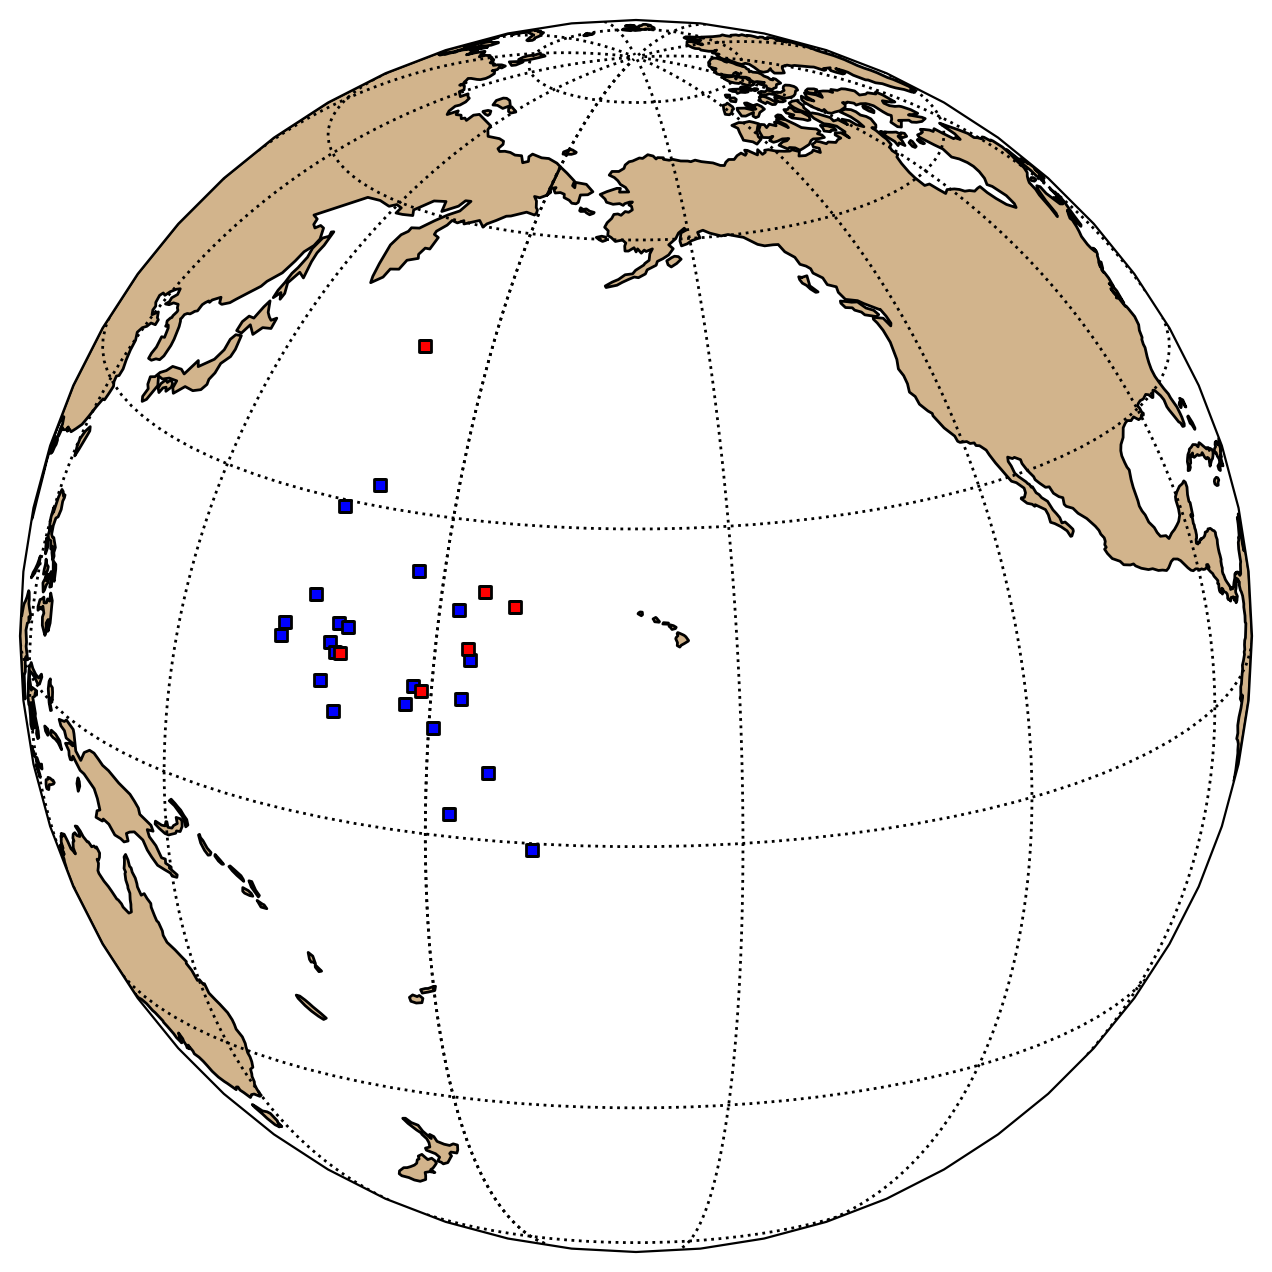

In [68]:
MIF_ax = ipmag.make_orthographic_map(central_latitude=20, central_longitude=200)
ipmag.plot_vgp(MIF_ax, Fairchild2017_MIF['vgp_lon'].tolist(), Fairchild2017_MIF['vgp_lat'].tolist(), marker='s', color='blue', label='Michipicoten Island Formation')
ipmag.plot_vgp(MIF_ax, Palmer1987_MIF['vgp_lon'].tolist(), Palmer1987_MIF['vgp_lat'].tolist(), marker='s', color='red', label='Michipicoten Island Formation')

# Import SWLLIP data

- Zhang et al., 2024 Death Valley and Grand Canyon mafic intrusions
- Let's only use the dated sites
- There is too few sites to make a meaningful pole mean so we only use these data for the site based approach

- Zhang, Y., Anderson, N. S., Mohr, M. T., Nelson, L. L., Macdonald, F. A., Schmitz, M. D., Thurston, O. G., Guenthner, W. R., Karlstrom, K. E., & Swanson-Hysell, N. L. (2024). Paleomagneticrecords from pulsed magmatism in the southwestern Laurentia large igneous province and Cardenas Basalt support rapid late Mesoproterozoic plate motion. Journal of Geophysical Research: Solid Earth, 129(10). https://doi.org/10.1029/2024jb029036


In [69]:
SWLLIP_data = pd.read_csv('../data/pmag_compiled/Zhang2024/Death_Valley_sites.txt',sep='\t',header=1)
SWLLIP_data['geologic_classes'] = 'Intrusive:Igneous'
SWLLIP_dated_sites = ['CS1', 'CS7', 'UI4', 'UI5']
SWLLIP_data = SWLLIP_data[SWLLIP_data['site'].isin(SWLLIP_dated_sites)].reset_index(drop=True)
SWLLIP_data['age_model'] = None
SWLLIP_data['height_type'] = None
SWLLIP_data['height'] = None
SWLLIP_data['height_upper'] = None
SWLLIP_data['height_lower'] = None
SWLLIP_data['age'] = 1098.1
SWLLIP_data['age_low'] = 1097.7
SWLLIP_data['age_high'] = 1098.5
SWLLIP_data['age_unit'] = 'Ma'
SWLLIP_data['age_uncertainty'] = 'gaussian'
# dir_k and dir_alpah95 are already in the data table
SWLLIP_data['dir_f'] = 1.0
SWLLIP_data['pole_name'] = 'SWLLIP'
SWLLIP_data['dir_polarity'] = 'n'
SWLLIP_data['citations'] = 'Zhang et al., 2024'
SWLLIP_data['geologic_types'] = 'Sill'
SWLLIP_data

,site,location,samples,specimens,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,lon,analysts,criteria,software_packages,citations,method_codes,result_quality,vgp_dm,vgp_dp,vgp_lat,vgp_lon,Unnamed: 28,geologic_classes,age_model,height_type,height,height_upper,height_lower,age,age_low,age_high,age_unit,age_uncertainty,dir_f,pole_name,geologic_types
0,CS1,Death Valley,CS1-1:CS1-2:CS1-3:CS1-4:CS1-5:CS1-6:CS1-7:CS1-8,CS1-1a:CS1-2a:CS1-3a:CS1-4a:CS1-5a:CS1-6a:CS1-7a:CS1-8a,4.2,mt,292.8,73.3,175,8,8,8,0,n,7.9599,100,35.968800,-116.919000,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,"Zhang et al., 2024",LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,7.5,6.7,41.7,203.7,NaN,Intrusive:Igneous,None,None,None,None,None,1098.1,1097.7,1098.5,Ma,gaussian,1.0,SWLLIP,Sill
1,CS7,Death Valley,CS7-5:CS7-8,CS7-5a:CS7-8a,19.5,mt,331.1,42.4,167,2,2,2,0,n,1.9940,100,35.815400,-116.388600,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,"Zhang et al., 2024",LP-DIR-T:DE-BFL:DA-DIR-TILT:LP-DC4:DA-DIR-GEO,g,24.0,14.8,62.7,137.2,NaN,Intrusive:Igneous,None,None,None,None,None,1098.1,1097.7,1098.5,Ma,gaussian,1.0,SWLLIP,Sill
2,UI4,Grand Canyon,UI4-1:UI4-2:UI4-3:UI4-4:UI4-5:UI4-7:UI4-8,UI4-1a:UI4-2a:UI4-3a:UI4-4a:UI4-5a:UI4-7a:UI4-8a,8.3,mt,314.1,51.6,54,7,7,7,0,n,6.8885,100,36.235278,-112.329444,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,"Zhang et al., 2024",LP-DIR-T:DE-BFL:DA-DIR-TILT:DE-BFL-A:LP-DC4:DE-FM:DA-DIR-GEO,g,11.3,7.7,52.2,165.4,sill,Intrusive:Igneous,None,None,None,None,None,1098.1,1097.7,1098.5,Ma,gaussian,1.0,SWLLIP,Sill
3,UI5,Grand Canyon,UI5-1:UI5-2:UI5-3:UI5-4:UI5-5:UI5-6:UI5-7:UI5-8,UI5-1a:UI5-2a:UI5-3a:UI5-4a:UI5-5a:UI5-6a:UI5-7a:UI5-8a,6.4,mt,295.6,49.3,76,8,8,8,0,n,7.9074,100,36.348333,-112.452500,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,"Zhang et al., 2024",LP-DIR-T:DE-BFL-A:DA-DIR-TILT:DE-BFL:LP-DC4:DE-FM:DA-DIR-GEO,g,8.5,5.6,36.8,170.8,sill,Intrusive:Igneous,None,None,None,None,None,1098.1,1097.7,1098.5,Ma,gaussian,1.0,SWLLIP,Sill


In [70]:
SWLLIP_data_mean_pole = ipmag.fisher_mean(dec=SWLLIP_data['vgp_lon'].tolist(), inc=SWLLIP_data['vgp_lat'].tolist())
SWLLIP_data_mean_pole

{'dec': 173.02605083654487,
 'inc': 50.55088427069385,
 'n': 4,
 'r': 3.811276146839893,
 'k': 15.896241782722084,
 'alpha95': 23.779104005323543,
 'csd': 20.315980578381}

# Import Duluth Complex data

- data are the filtered data frames from the 2021 Duluth Complex notebook, all tilt-corrected

- Beck, M. E. (1970). Paleomagnetism of Keweenawan intrusive rocks, Minnesota. Journal of Geophysical Research, 75(26), 4985–4996. https://doi.org/10.1029/jb075i026p04985
- Swanson-Hysell, N. L., Avery, M. S., Zhang, Y., Hodgin, E. B., Sherwood, R. J., Apen, F. E., Boerboom, T. J., Keller, B. C., & Cottle, J. M. (2021). The paleogeography of Laurentia in its early years:new constraints from the Paleoproterozoic East-Central Minnesota batholith. Tectonics. https://doi.org/10.1029/2021tc006751


In [71]:
Beck1970a_anorthosite = pd.read_csv('../data/pmag_compiled/Beck1970/Beck_anorthositic_series.txt',sep='\t',header=0)
Beck1970a_anorthosite['geologic_classes'] = 'Intrusive:Igneous'
Beck1970a_anorthosite = Beck1970a_anorthosite[Beck1970a_anorthosite['dir_tilt_correction'] == 100.0].reset_index(drop=True)

Beck1970a_layered = pd.read_csv('../data/pmag_compiled/Beck1970/Beck_layered_series.txt',sep='\t',header=0)
Beck1970a_layered['geologic_classes'] = 'Intrusive:Igneous'
Beck1970a_layered = Beck1970a_layered[Beck1970a_layered['dir_tilt_correction'] == 100.0].reset_index(drop=True)

SH2021_data = pd.read_csv('../data/pmag_compiled/Swanson-Hysell2021/sites.txt',sep='\t',header=0)
SH2021_data['geologic_classes'] = 'Intrusive:Igneous'
SH2021_data = SH2021_data[SH2021_data['dir_tilt_correction'] == 100.0].reset_index(drop=True)
# let's take FC1 mt component, FC4 mc componnet, and HCT1 mt component
SH2021_data = SH2021_data.iloc[[1, 2, 4]].reset_index(drop=True)
Duluth_Complex_data = pd.concat([SH2021_data, Beck1970a_anorthosite, Beck1970a_layered], ignore_index=True)
Duluth_Complex_data['age_model'] = None
Duluth_Complex_data['height_type'] = None
Duluth_Complex_data['height'] = None
Duluth_Complex_data['height_upper'] = None
Duluth_Complex_data['height_lower'] = None
Duluth_Complex_data['age'] = 1096
Duluth_Complex_data['age_low'] = 1095.5
Duluth_Complex_data['age_high'] = 1096.5
Duluth_Complex_data['age_unit'] = 'Ma'
Duluth_Complex_data['age_uncertainty'] = 'gaussian'
# dir_k and dir_alpah95 are already in the data table
Duluth_Complex_data['dir_f'] = 1.0
Duluth_Complex_data['pole_name'] = 'Duluth Complex'
Duluth_Complex_data['dir_polarity'] = 'n'
Duluth_Complex_data['citations'] = 'Swanson-Hysell et al., 2021: Beck, 1969'
Duluth_Complex_data.head()

,site,location,samples,specimens,age,age_sigma,age_unit,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,height,lat,lon,geologic_classes,geologic_types,lithologies,analysts,software_packages,citations,method_codes,result_quality,result_type,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,dir_n_total_specimens,blanket_demag_level_af,description,age_model,height_type,height_upper,height_lower,age_low,age_high,age_uncertainty,dir_f,pole_name
0,FC1,North Shore,FC1-1:FC1-2:FC1-3:FC1-4:FC1-5:FC1-6:FC1-7:FC1-8:FC1-9,FC1-1b:FC1-2b:FC1-3b:FC1-4b:FC1-5b:FC1-6b:FC1-7b:FC1-8b:FC1-9b,1096,0.16,Ma,6.500000,mt,284.110929,45.103706,64.0,9,9,9.0,0.0,n,8.8741,100,None,47.7826,268.6735,Intrusive:Igneous,Pluton,Gabbro,Yiming Zhang,pmagpy-4.2.25: demag_gui.v.3.0,"Swanson-Hysell et al., 2021: Beck, 1969",LP-DIR-T:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM,g,i,26.648106,28.593061,187.847899,-28.593061,7.847898,NaN,NaN,NaN,None,None,None,None,1095.5,1096.5,gaussian,1.0,Duluth Complex
1,FC4,North Shore,FC4-1:FC4-2:FC4-3:FC4-6:FC4-7:FC4-8:FC4-9,FC4-1a:FC4-2a:FC4-3a:FC4-6a:FC4-7a:FC4-8a:FC4-9a,1096,0.18,Ma,7.900000,mc,292.632873,38.265560,59.0,7,7,7.0,0.0,n,6.8977,100,None,47.7625,268.6173,Intrusive:Igneous,Pluton,Gabbro,Yiming Zhang,pmagpy-4.2.25: demag_gui.v.3.0,"Swanson-Hysell et al., 2021: Beck, 1969",LP-DIR-AF:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM,g,i,21.523703,30.815285,177.388326,-30.815285,357.388326,NaN,NaN,NaN,None,None,None,None,1095.5,1096.5,gaussian,1.0,Duluth Complex
2,HCT1,North Shore,HCT1-1:HCT1-2:HCT1-3:HCT1-5:HCT1-6:HCT1-8,HCT1-1b:HCT1-2b:HCT1-3b:HCT1-5b:HCT1-6b:HCT1-8b,1096,0.26,Ma,5.600000,mt,276.317559,55.283566,144.0,6,6,6.0,0.0,n,5.9652,100,None,47.6008,268.8505,Intrusive:Igneous,Pluton,Gabbro,Yiming Zhang,pmagpy-4.2.25: demag_gui.v.3.0,"Swanson-Hysell et al., 2021: Beck, 1969",LP-DIR-T:DE-BFL:DA-DIR-GEO:LP-DC4:DE-FM,g,i,35.816076,29.492268,201.037076,-29.492268,21.037076,NaN,NaN,NaN,None,None,None,None,1095.5,1096.5,gaussian,1.0,Duluth Complex
3,18,Anorthositic series,6B095:6B096:6B097:6B098:6B099:6B100:6B101,NaN,1096,NaN,Ma,5.547002,NaN,284.115300,54.526248,91.0,7,7,NaN,NaN,n,NaN,100,None,46.7500,-92.1700,Intrusive:Igneous,Pluton,Gabbro,NaN,NaN,"Swanson-Hysell et al., 2021: Beck, 1969",LT-AF-Z:DE-BLANKET,g,i,35.055567,33.720412,195.187570,-33.720412,15.187570,7.0,0.06,Quarry Containing heterogeneous coarse to very coarse feldspatic gabbros,None,None,None,None,1095.5,1096.5,gaussian,1.0,Duluth Complex
4,222,Anorthositic series,K133.1:K133.2:K133.3:K133.4:K133.5,NaN,1096,NaN,Ma,7.253789,NaN,272.964238,60.591129,74.5,5,5,NaN,NaN,n,NaN,100,None,46.7600,-92.1500,Intrusive:Igneous,Pluton,Gabbro,NaN,NaN,"Swanson-Hysell et al., 2021: Beck, 1969",LT-AF-Z:DE-BLANKET,g,i,41.574177,30.658536,207.566023,-30.658536,27.566023,5.0,0.06,"Very coarse-grained, massive gabbro",None,None,None,None,1095.5,1096.5,gaussian,1.0,Duluth Complex


In [72]:
Duluth_Complex_mean_pole = ipmag.fisher_mean(dec=Duluth_Complex_data['vgp_lon'].tolist(), inc=Duluth_Complex_data['vgp_lat'].tolist())
ipmag.print_pole_mean(Duluth_Complex_mean_pole)

Plon: 188.7  Plat: 35.6
Number of directions in mean (n): 24
Angular radius of 95% confidence (A_95): 3.1
Precision parameter (k) estimate: 91.1


# import Beaver Bay Complex data

- Zhang, Y., Swanson-Hysell, N. L., Schmitz, M. D., Miller, J. D., & Avery, M. S. (2021). Synchronous emplacement of the anorthosite xenolith-bearing Beaver River diabase and one of the largest lava flows on Earth. Geochemistry, Geophysics, Geosystems. https://doi.org/10.1029/2021gc009909


In [73]:
Zhang2021_data = pd.read_csv('../data/pmag_compiled/Zhang2021/sites.txt',sep='\t',header=0)
Zhang2021_data['geologic_classes'] = 'Intrusive:Igneous'
Zhang2021_data['age_model'] = None
Zhang2021_data['height_type'] = None
Zhang2021_data['height'] = None
Zhang2021_data['height_upper'] = None
Zhang2021_data['height_lower'] = None
Zhang2021_data['age'] = 1091.7
Zhang2021_data['age_low'] = 1091.5
Zhang2021_data['age_high'] = 1091.9
Zhang2021_data['age_unit'] = 'Ma'
Zhang2021_data['age_uncertainty'] = 'gaussian'
# dir_k and dir_alpah95 are already in the data table
Zhang2021_data['dir_f'] = 1.0
Zhang2021_data['dir_polarity'] = 'n'
Zhang2021_data['citations'] = 'Zhang et al., 2021'
Zhang2021_data['pole_name'] = 'Beaver River diabase'
Zhang2021_data['lithologies']= ['Anorthosite', 'Anorthosite', 'Anorthosite', 
                                'Anorthosite', 'Anorthosite', 'Anorthosite', 
                                'Anorthosite', 'Anorthosite', 'Anorthosite', 
                                'Diabase', 'Diabase', 'Diabase', 
                                'Diabase', 'Diabase', 'Diabase', 
                                'Diabase']
Zhang2021_data['geologic_types'] = 'Intrusion'

Zhang2021_data

,Cooling Unit,lon,lat,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,dir_n_specimens,dir_tilt_correction,geologic_classes,age_model,height_type,height,height_upper,height_lower,age,age_low,age_high,age_unit,age_uncertainty,dir_f,dir_polarity,citations,pole_name,lithologies,geologic_types
0,CU1,-91.379371,47.200436,34.305720,36.507587,192.077470,-36.507587,12.077470,AX1:BD1,288.856164,53.765464,601.447898,1.207352,24,24,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
1,CU2,-90.856288,47.582703,19.819897,23.471892,183.316437,-23.471892,3.316437,AX3:AX4:AX5:AX6:AX7:AX8:AX9:AX10:BD2,283.485793,35.785156,89.514851,2.434637,39,39,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
2,CU3,-91.167418,47.368922,20.816277,24.562438,183.445590,-24.562438,3.445590,AX11:AX13:BD3,284.100197,37.248595,195.068246,2.077850,25,25,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
3,CU4,-91.260390,47.291835,33.618349,41.098836,186.681162,-41.098836,6.681162,AX12:AX14:BD4,296.330123,53.055448,61.587260,4.082968,21,21,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
4,CU5,-91.263650,47.288661,35.756902,26.028155,204.185894,-26.028155,24.185894,AX15:AX16:AX17:AX18:BD5,270.983251,55.225147,135.359994,1.925420,41,41,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
5,CU6,-91.292925,47.263413,28.278455,36.731761,182.342484,-36.731761,2.342484,AX19:BD6,294.739092,47.094450,102.985727,3.531703,17,17,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
6,CU7,-91.288383,47.266610,42.921851,40.459190,202.028480,-40.459190,22.028480,AX20:BD7,287.412036,61.735181,158.404683,3.459236,12,12,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
7,CU8,-91.159176,47.411406,37.906376,41.625883,193.184698,-41.625883,13.184698,AX22:BD10,293.386651,57.294229,251.893387,2.118690,19,19,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
8,CU9,-91.291029,47.268486,31.275519,42.128549,181.719023,-42.128549,1.719023,AX21,299.940518,50.540577,782.577086,1.981368,8,8,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Anorthosite,Intrusion
9,CU10,-91.356198,47.212553,46.344382,37.051274,209.903101,-37.051274,29.903101,BD8,278.778760,64.495594,301.851493,2.784998,10,10,100,Intrusive:Igneous,None,None,None,None,None,1091.7,1091.5,1091.9,Ma,gaussian,1.0,n,"Zhang et al., 2021",Beaver River diabase,Diabase,Intrusion


In [74]:
Beaver_Bay_Complex_mean_pole = ipmag.fisher_mean(dec=Zhang2021_data['vgp_lon'].tolist(), inc=Zhang2021_data['vgp_lat'].tolist())
ipmag.print_pole_mean(Beaver_Bay_Complex_mean_pole)

Plon: 188.8  Plat: 32.7
Number of directions in mean (n): 16
Angular radius of 95% confidence (A_95): 5.9
Precision parameter (k) estimate: 40.7


# Import Cut Face Creek sandstone data

- Pierce, J., Zhang, Y., Hodgin, E. B., & Swanson-Hysell, N. L. (2022). Quantifying inclination shallowing and representing flattening uncertainty in sedimentary paleomagnetic poles. Geochemistry, Geophysics, Geosystems, 23(11). https://doi.org/10.1029/2022gc010682


In [75]:
Pierce2022_data = pd.read_csv('../data/pmag_compiled/Pierce2022/specimens.txt', sep='\t', header=1)
Pierce2022_data = Pierce2022_data[Pierce2022_data['dir_tilt_correction'] == 100]
Pierce2022_data = Pierce2022_data[Pierce2022_data['dir_comp'] == 'ht']

Pierce2022_data

,specimen,experiments,sample,site,dir_alpha95,dir_comp,dir_dec,dir_inc,dir_n_comps,dir_n_measurements,dir_tilt_correction,dir_dang,dir_mad_free,geologic_classes,geologic_types,lithologies,meas_step_max,meas_step_min,meas_step_unit,analysts,instrument_codes,software_packages,int_corr,citations,method_codes,result_quality,volume,weight
3,CF-100a,CF-100a_LP-DIR-T,CF-100,CF-100,NaN,ht,288.4,31.6,2.0,9.0,100.0,16.4,10.0,Sedimentary,Sediment Layer,Siltstone:Sandstone,953.0,923.0,K,NaN,hargrave 2021-02-11 20:25:12,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL:DA-DIR-TILT,g,NaN,NaN
15,CF-102a,CF-102a_LP-DIR-T,CF-102,CF-102,NaN,ht,259.5,30.0,3.0,6.0,100.0,0.0,19.5,Sedimentary,Sediment Layer,Siltstone:Sandstone,955.0,945.0,K,NaN,hargrave 2021-02-13 18:58:05,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
25,CF-103a,CF-103a_LP-DIR-T,CF-103,CF-103,NaN,ht,279.2,24.1,3.0,9.0,100.0,0.0,13.2,Sedimentary,Sediment Layer,Siltstone:Sandstone,957.0,937.0,K,NaN,hargrave 2021-02-13 18:59:29,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
40,CF-104a,CF-104a_LP-DIR-T,CF-104,CF-104,NaN,ht,310.0,34.8,2.0,7.0,100.0,0.0,10.5,Sedimentary,Sediment Layer,Siltstone:Sandstone,953.0,913.0,K,NaN,hargrave 2021-02-11 20:30:56,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
52,CF-106a,CF-106a_LP-DIR-T,CF-106,CF-106,NaN,ht,295.9,28.4,2.0,10.0,100.0,0.0,8.9,Sedimentary,Sediment Layer,Siltstone:Sandstone,960.0,937.0,K,NaN,hargrave 2021-02-13 19:00:55,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
58,CF-107a,CF-107a_LP-DIR-T,CF-107,CF-107,NaN,ht,276.5,43.3,3.0,10.0,100.0,0.0,9.4,Sedimentary,Sediment Layer,Siltstone:Sandstone,960.0,937.0,K,NaN,hargrave 2021-02-13 19:02:26,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
69,CF-108a,CF-108a_LP-DIR-T,CF-108,CF-108,NaN,ht,278.4,31.3,2.0,9.0,100.0,0.0,2.5,Sedimentary,Sediment Layer,Siltstone:Sandstone,957.0,937.0,K,NaN,hargrave 2021-02-13 20:01:17,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
74,CF-109a,CF-109a_LP-DIR-T,CF-109,CF-109,NaN,ht,277.1,29.2,3.0,10.0,100.0,0.0,7.1,Sedimentary,Sediment Layer,Siltstone:Sandstone,955.0,923.0,K,NaN,hargrave 2021-02-12 14:21:57,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
90,CF-10a,CF-10a_LP-DIR-T,CF-10,CF-10,NaN,ht,275.2,25.3,3.0,7.0,100.0,0.0,7.5,Sedimentary,Sediment Layer,Siltstone:Sandstone,954.0,937.0,K,NaN,hargrave 2020-11-24 21:43:43,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN
98,CF-110a,CF-110a_LP-DIR-T,CF-110,CF-110,NaN,ht,293.1,23.3,2.0,8.0,100.0,0.0,6.5,Sedimentary,Sediment Layer,Siltstone:Sandstone,960.0,945.0,K,NaN,hargrave 2021-02-13 19:05:40,pmagpy-4.2.24-1: demag_gui,u,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN


In [76]:
Pierce2022_data = pd.read_csv('../data/pmag_compiled/Pierce2022/specimens.txt', sep='\t', header=1)
Pierce2022_data = Pierce2022_data[Pierce2022_data['dir_tilt_correction'] == 100]
Pierce2022_data = Pierce2022_data[Pierce2022_data['dir_comp'] == 'ht']
Pierce2022_data['dir_comp_name'] = Pierce2022_data['dir_comp']
# add strat height info from sample file to specimen/site file
Pierce2022_sample = pd.read_csv('../data/pmag_compiled/Pierce2022/samples.txt', sep='\t', header=1, index_col='site')
Pierce2022_data['age_model'] = 'Cut Face Creek'
Pierce2022_data['height'] = Pierce2022_data['site'].map(Pierce2022_sample['height'])
Pierce2022_data['height_type'] = 'exact'
Pierce2022_data['height_upper'] = None
Pierce2022_data['height_lower'] = None
Pierce2022_data['age'] = 1092.6
Pierce2022_data['age_low'] = 1091.7
Pierce2022_data['age_high'] = 1093.5
Pierce2022_data['age_unit'] = 'Ma'
Pierce2022_data['age_uncertainty'] = 'uniform'
# convert MAD or aMAD (anchored fits) to alpha95 and k
Pierce2022_data['dir_alpha95'] = ipmag.mad_to_a95(Pierce2022_data['dir_mad_free'], Pierce2022_data['dir_n_measurements'], Pierce2022_data['method_codes'].str.contains('DE-BFL-A'))
Pierce2022_data['dir_k'] = (140 / Pierce2022_data['dir_alpha95'])**2
Pierce2022_data['dir_f'] = 'resample'
Pierce2022_data['dir_polarity'] = 'n'

Pierce2022_data['pole_name'] = 'Cut Face Creek Sandstone'
Pierce2022_data['citations'] = 'Pierce et al., 2022'
Pierce2022_data['dir_n_specimens'] = 1
Pierce2022_data['dir_n_samples'] = 1
Pierce2022_data['geologic_classes'] = 'Sedimentary'
Pierce2022_data['geologic_types'] = 'Sediment Layer'
Pierce2022_data['lat'] = 47.73055
Pierce2022_data['lon'] = 360-90.44128
Pierce2022_data = ipmag.vgp_calc(Pierce2022_data, 'yes', 'lon', 'lat', dec_tc='dir_dec', inc_tc='dir_inc')
Pierce2022_data['lithologies'] = 'Siltstone'
Pierce2022_data['location'] = 'Cut Face Creek'
Pierce2022_data['site'] = Pierce2022_data['sample']

# Pierce2022_data['f_nominal'] = 0.64 # roughly the nominal f factor from Pierce et al., 2022
# Pierce2022_data['f_sigma'] = 0.1 # the distribution of f factor is not normal but that of the paleolatitude is, I estimated the sigma from the overall 95% interval from find_ei function
Pierce2022_data.head()

,specimen,experiments,sample,site,dir_alpha95,dir_comp,dir_dec,dir_inc,dir_n_comps,dir_n_measurements,dir_tilt_correction,dir_dang,dir_mad_free,geologic_classes,geologic_types,lithologies,meas_step_max,meas_step_min,meas_step_unit,analysts,instrument_codes,software_packages,int_corr,citations,method_codes,result_quality,volume,weight,dir_comp_name,age_model,height,height_type,height_upper,height_lower,age,age_low,age_high,age_unit,age_uncertainty,dir_k,dir_f,dir_polarity,pole_name,dir_n_specimens,dir_n_samples,lat,lon,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,location
3,CF-100a,CF-100a_LP-DIR-T,CF-100,CF-100,25.700,ht,288.4,31.6,2.0,9.0,100.0,16.4,10.0,Sedimentary,Sediment Layer,Siltstone,953.0,923.0,K,NaN,hargrave 2021-02-11 20:25:12,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,47.0,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,29.674938,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,17.098005,24.865527,177.948229,-24.865527,357.948229,Cut Face Creek
15,CF-102a,CF-102a_LP-DIR-T,CF-102,CF-102,86.385,ht,259.5,30.0,3.0,6.0,100.0,0.0,19.5,Sedimentary,Sediment Layer,Siltstone,955.0,945.0,K,NaN,hargrave 2021-02-13 18:58:05,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,47.8,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,2.626512,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,16.102114,5.018080,198.060190,-5.018080,18.060190,Cut Face Creek
25,CF-103a,CF-103a_LP-DIR-T,CF-103,CF-103,55.176,ht,279.2,24.1,3.0,9.0,100.0,0.0,13.2,Sedimentary,Sediment Layer,Siltstone,957.0,937.0,K,NaN,hargrave 2021-02-13 18:59:29,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,48.4,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,6.438069,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,12.607330,15.453858,181.422840,-15.453858,1.422840,Cut Face Creek
40,CF-104a,CF-104a_LP-DIR-T,CF-104,CF-104,45.255,ht,310.0,34.8,2.0,7.0,100.0,0.0,10.5,Sedimentary,Sediment Layer,Siltstone,953.0,913.0,K,NaN,hargrave 2021-02-11 20:30:56,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,48.9,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,9.570242,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,19.162802,40.639544,162.032698,-40.639544,342.032698,Cut Face Creek
52,CF-106a,CF-106a_LP-DIR-T,CF-106,CF-106,36.846,ht,295.9,28.4,2.0,10.0,100.0,0.0,8.9,Sedimentary,Sediment Layer,Siltstone,960.0,937.0,K,NaN,hargrave 2021-02-13 19:00:55,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,49.3,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,14.436947,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,15.128211,28.472787,170.626377,-28.472787,350.626377,Cut Face Creek


In [77]:
Cut_Face_Creek_mean_pole = ipmag.fisher_mean(dec=Pierce2022_data['vgp_lon'].tolist(), inc=Pierce2022_data['vgp_lat'].tolist())
ipmag.print_pole_mean(Cut_Face_Creek_mean_pole)
Cut_Face_Creek_mean_pole_inc_corrected = ipmag.unsquish(incs=Cut_Face_Creek_mean_pole['inc'], f=0.64)
round(Cut_Face_Creek_mean_pole_inc_corrected, 1)

Plon: 178.5  Plat: 23.0
Number of directions in mean (n): 157
Angular radius of 95% confidence (A_95): 1.7
Precision parameter (k) estimate: 44.0
TypeError caught:  object of type 'numpy.float64' has no len()


33.6

# Import Cardenas data

- Zhang, Y., Anderson, N. S., Mohr, M. T., Nelson, L. L., Macdonald, F. A., Schmitz, M. D., Thurston, O. G., Guenthner, W. R., Karlstrom, K. E., & Swanson-Hysell, N. L. (2024). Paleomagneticrecords from pulsed magmatism in the southwestern Laurentia large igneous province and Cardenas Basalt support rapid late Mesoproterozoic plate motion. Journal of Geophysical Research: Solid Earth, 129(10). https://doi.org/10.1029/2024jb029036


In [78]:
Zhang2024_Cardenas = pd.read_csv('../data/pmag_compiled/Zhang2024/Cardenas_sites.txt', sep='\t', header=1)
Zhang2024_Cardenas['geologic_classes'] = 'Extrusive:Igneous'
Zhang2024_Cardenas['age_model'] = None
Zhang2024_Cardenas['height_type'] = None
Zhang2024_Cardenas['height'] = None
Zhang2024_Cardenas['height_upper'] = None
Zhang2024_Cardenas['height_lower'] = None
Zhang2024_Cardenas['age'] = 1082.18
Zhang2024_Cardenas['age_low'] = 1082.18-0.25
Zhang2024_Cardenas['age_high'] = 1082.18+0.25
Zhang2024_Cardenas['age_uncertainty'] = 'gaussian'
Zhang2024_Cardenas['age_unit'] = 'Ma'
Zhang2024_Cardenas['pole_name'] = 'Cardenas Basalt'
Zhang2024_Cardenas['dir_f'] = 1.0
Zhang2024_Cardenas['dir_polarity'] = 'n'
Zhang2024_Cardenas['lithologies'] = 'Basalt'
Zhang2024_Cardenas['geologic_types'] = 'Lava Flow'
Zhang2024_Cardenas.head()

,site,location,samples,specimens,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_n_specimens,dir_n_specimens_lines,dir_n_specimens_planes,dir_polarity,dir_r,dir_tilt_correction,lat,lon,analysts,criteria,software_packages,citations,method_codes,result_quality,vgp_dm,vgp_dp,vgp_lat,vgp_lon,rock type,geologic_classes,age_model,height_type,height,height_upper,height_lower,age,age_low,age_high,age_uncertainty,age_unit,pole_name,dir_f,lithologies,geologic_types
0,CB6,Grand Canyon,CB6-1:CB6-2:CB6-3:CB6-4:CB6-5:CB6-6:CB6-7:CB6-8,CB6-1a:CB6-2a:CB6-3a:CB6-4a:CB6-5a:CB6-6a:CB6-7a:CB6-8a,5.9,mt,252.7,47.0,88.0,8,8,8,0,n,7.9202,100,36.145833,-111.827500,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,7.6,4.9,3.8,190.7,lava flow,Extrusive:Igneous,None,None,None,None,None,1082.18,1081.93,1082.43,gaussian,Ma,Cardenas Basalt,1.0,Basalt,Lava Flow
1,CB7,Grand Canyon,CB7-1:CB7-2:CB7-3:CB7-4:CB7-5:CB7-6:CB7-7:CB7-8,CB7-1a:CB7-2a:CB7-3a:CB7-4a:CB7-5a:CB7-6a:CB7-7a:CB7-8a,5.4,mt,269.9,42.5,106.0,8,8,8,0,n,7.9337,100,36.146430,-111.826920,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,6.7,4.1,14.1,178.5,lava flow,Extrusive:Igneous,None,None,None,None,None,1082.18,1081.93,1082.43,gaussian,Ma,Cardenas Basalt,1.0,Basalt,Lava Flow
2,CB1,Grand Canyon,CB1-1:CB1-2:CB1-3:CB1-4:CB1-5:CB1-6:CB1-7:CB1-8,CB1-1a:CB1-2a:CB1-3a:CB1-4a:CB1-5a:CB1-6a:CB1-7a:CB1-8a,3.9,mt,270.3,51.1,200.0,8,8,8,0,n,7.9650,100,36.283889,-111.891944,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,5.3,3.6,18.4,184.5,lava flow,Extrusive:Igneous,None,None,None,None,None,1082.18,1081.93,1082.43,gaussian,Ma,Cardenas Basalt,1.0,Basalt,Lava Flow
3,CB2,Grand Canyon,CB2-1:CB2-2:CB2-3:CB2-4:CB2-5:CB2-6:CB2-7:CB2-8,CB2-1a:CB2-2a:CB2-3a:CB2-4a:CB2-5a:CB2-6a:CB2-7a:CB2-8a,3.1,mt,283.3,78.7,329.0,8,8,8,0,n,7.9787,100,36.283611,-111.891944,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,5.9,5.6,38.2,220.8,lava flow,Extrusive:Igneous,None,None,None,None,None,1082.18,1081.93,1082.43,gaussian,Ma,Cardenas Basalt,1.0,Basalt,Lava Flow
4,CB3,Grand Canyon,CB3-1:CB3-2:CB3-3:CB3-4:CB3-6:CB3-7:CB3-8,CB3-1a:CB3-2a:CB3-3a:CB3-4a:CB3-6a:CB3-7a:CB3-8a,8.1,mt,249.3,52.9,56.0,7,7,7,0,n,6.8937,100,36.283333,-111.892778,NaN,ACCEPT,pmagpy-4.2.24-1: demag_gui.v.3.0,This study,LP-DIR-T:DE-BFL-A:DA-DIR-TILT:LP-DC4:DE-FM:DA-DIR-GEO,g,11.2,7.7,5.1,196.5,lava flow,Extrusive:Igneous,None,None,None,None,None,1082.18,1081.93,1082.43,gaussian,Ma,Cardenas Basalt,1.0,Basalt,Lava Flow


In [79]:
Cardenas_mean_pole = ipmag.fisher_mean(dec=Zhang2024_Cardenas['vgp_lon'].tolist(), inc=Zhang2024_Cardenas['vgp_lat'].tolist())
ipmag.print_pole_mean(Cardenas_mean_pole)

Plon: 183.9  Plat: 15.9
Number of directions in mean (n): 18
Angular radius of 95% confidence (A_95): 7.4
Precision parameter (k) estimate: 22.7


# import Nonesuch data

- Slotznick, S. P., Swanson-Hysell, N. L., Zhang, Y., Clayton, K. E., Wellman, C. H., Tosca, N. J., & Strother, P. K. (2023). Reconstructing the paleoenvironment of an oxygenated Mesoproterozoic shoreline and its record of life. GSA Bulletin. https://doi.org/10.1130/B36634.1


- we recalculate the specimen strat heights with respect to the Fuentes et al., 2025 subsidencechron age model in notebook `Oronto_group_age_models.ipynb`. Therefore here we read in the updated `specimens_with_heights.csv` file.

In [80]:
Pierce2022_data = pd.read_csv('../data/pmag_compiled/Pierce2022/specimens.txt', sep='\t', header=1)
Pierce2022_data = Pierce2022_data[Pierce2022_data['dir_tilt_correction'] == 100]
Pierce2022_data = Pierce2022_data[Pierce2022_data['dir_comp'] == 'ht']
Pierce2022_data['dir_comp_name'] = Pierce2022_data['dir_comp']
# add strat height info from sample file to specimen/site file
Pierce2022_sample = pd.read_csv('../data/pmag_compiled/Pierce2022/samples.txt', sep='\t', header=1, index_col='site')
Pierce2022_data['age_model'] = 'Cut Face Creek'
Pierce2022_data['height'] = Pierce2022_data['site'].map(Pierce2022_sample['height'])
Pierce2022_data['height_type'] = 'exact'
Pierce2022_data['height_upper'] = None
Pierce2022_data['height_lower'] = None
Pierce2022_data['age'] = 1092.6
Pierce2022_data['age_low'] = 1091.7
Pierce2022_data['age_high'] = 1093.5
Pierce2022_data['age_unit'] = 'Ma'
Pierce2022_data['age_uncertainty'] = 'uniform'
# convert MAD or aMAD (anchored fits) to alpha95 and k
Pierce2022_data['dir_alpha95'] = ipmag.mad_to_a95(Pierce2022_data['dir_mad_free'], Pierce2022_data['dir_n_measurements'], Pierce2022_data['method_codes'].str.contains('DE-BFL-A'))
Pierce2022_data['dir_k'] = (140 / Pierce2022_data['dir_alpha95'])**2
Pierce2022_data['dir_f'] = 'resample'
Pierce2022_data['dir_polarity'] = 'n'

Pierce2022_data['pole_name'] = 'Cut Face Creek Sandstone'
Pierce2022_data['citations'] = 'Pierce et al., 2022'
Pierce2022_data['dir_n_specimens'] = 1
Pierce2022_data['dir_n_samples'] = 1
Pierce2022_data['geologic_classes'] = 'Sedimentary'
Pierce2022_data['geologic_types'] = 'Sediment Layer'
Pierce2022_data['lat'] = 47.73055
Pierce2022_data['lon'] = 360-90.44128
Pierce2022_data = ipmag.vgp_calc(Pierce2022_data, 'yes', 'lon', 'lat', dec_tc='dir_dec', inc_tc='dir_inc')
Pierce2022_data['lithologies'] = 'Siltstone'
Pierce2022_data['location'] = 'Cut Face Creek'
Pierce2022_data['site'] = Pierce2022_data['sample']

# Pierce2022_data['f_nominal'] = 0.64 # roughly the nominal f factor from Pierce et al., 2022
# Pierce2022_data['f_sigma'] = 0.1 # the distribution of f factor is not normal but that of the paleolatitude is, I estimated the sigma from the overall 95% interval from find_ei function
Pierce2022_data.head()

,specimen,experiments,sample,site,dir_alpha95,dir_comp,dir_dec,dir_inc,dir_n_comps,dir_n_measurements,dir_tilt_correction,dir_dang,dir_mad_free,geologic_classes,geologic_types,lithologies,meas_step_max,meas_step_min,meas_step_unit,analysts,instrument_codes,software_packages,int_corr,citations,method_codes,result_quality,volume,weight,dir_comp_name,age_model,height,height_type,height_upper,height_lower,age,age_low,age_high,age_unit,age_uncertainty,dir_k,dir_f,dir_polarity,pole_name,dir_n_specimens,dir_n_samples,lat,lon,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,location
3,CF-100a,CF-100a_LP-DIR-T,CF-100,CF-100,25.700,ht,288.4,31.6,2.0,9.0,100.0,16.4,10.0,Sedimentary,Sediment Layer,Siltstone,953.0,923.0,K,NaN,hargrave 2021-02-11 20:25:12,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,47.0,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,29.674938,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,17.098005,24.865527,177.948229,-24.865527,357.948229,Cut Face Creek
15,CF-102a,CF-102a_LP-DIR-T,CF-102,CF-102,86.385,ht,259.5,30.0,3.0,6.0,100.0,0.0,19.5,Sedimentary,Sediment Layer,Siltstone,955.0,945.0,K,NaN,hargrave 2021-02-13 18:58:05,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,47.8,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,2.626512,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,16.102114,5.018080,198.060190,-5.018080,18.060190,Cut Face Creek
25,CF-103a,CF-103a_LP-DIR-T,CF-103,CF-103,55.176,ht,279.2,24.1,3.0,9.0,100.0,0.0,13.2,Sedimentary,Sediment Layer,Siltstone,957.0,937.0,K,NaN,hargrave 2021-02-13 18:59:29,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,48.4,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,6.438069,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,12.607330,15.453858,181.422840,-15.453858,1.422840,Cut Face Creek
40,CF-104a,CF-104a_LP-DIR-T,CF-104,CF-104,45.255,ht,310.0,34.8,2.0,7.0,100.0,0.0,10.5,Sedimentary,Sediment Layer,Siltstone,953.0,913.0,K,NaN,hargrave 2021-02-11 20:30:56,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,48.9,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,9.570242,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,19.162802,40.639544,162.032698,-40.639544,342.032698,Cut Face Creek
52,CF-106a,CF-106a_LP-DIR-T,CF-106,CF-106,36.846,ht,295.9,28.4,2.0,10.0,100.0,0.0,8.9,Sedimentary,Sediment Layer,Siltstone,960.0,937.0,K,NaN,hargrave 2021-02-13 19:00:55,pmagpy-4.2.24-1: demag_gui,u,"Pierce et al., 2022",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,NaN,ht,Cut Face Creek,49.3,exact,None,None,1092.6,1091.7,1093.5,Ma,uniform,14.436947,resample,n,Cut Face Creek Sandstone,1,1,47.73055,269.55872,15.128211,28.472787,170.626377,-28.472787,350.626377,Cut Face Creek


In [81]:
Slotznick2023_data = pd.read_csv('../data/pmag_compiled/Slotznick2023/specimens_with_height.txt', sep='\t', header=1)

Slotznick2023_data = Slotznick2023_data[Slotznick2023_data['dir_tilt_correction'] == 100]
Slotznick2023_data = Slotznick2023_data[(Slotznick2023_data['dir_comp'] == 'mt') | (Slotznick2023_data['dir_comp'] == 'hdt')]
Slotznick2023_data['dir_comp_name'] = Slotznick2023_data['dir_comp']

Slotznick2023_data['pole_name'] = 'Nonesuch Formation'
Slotznick2023_data['dir_polarity'] = 'n'
Slotznick2023_data['citations'] = 'Slotznick et al., 2023'
Slotznick2023_data = Slotznick2023_data[~Slotznick2023_data['site'].str.contains('PF18-21|PF18-67|PF18-83|PF18-94|PF18-123')].reset_index(drop=True)

Slotznick2023_data['age_model'] = 'Oronto Group'
Slotznick2023_data['height_type'] = 'exact'
Slotznick2023_data['height_upper'] = None
Slotznick2023_data['height_lower'] = None
Slotznick2023_data['age'] = 1080
Slotznick2023_data['age_low'] = 1075
Slotznick2023_data['age_high'] = 1085.57
Slotznick2023_data['age_unit'] = 'Ma'
Slotznick2023_data['age_uncertainty'] = 'uniform'
Slotznick2023_data['dir_f'] = 'resample'
# convert MAD or aMAD (anchored fits) to alpha95 and k
Slotznick2023_data['dir_alpha95'] = ipmag.mad_to_a95(Slotznick2023_data['dir_mad_free'], Slotznick2023_data['dir_n_measurements'], Slotznick2023_data['method_codes'].str.contains('DE-BFL-A'))
Slotznick2023_data['dir_k'] = (140/Slotznick2023_data['dir_alpha95'])**2
Slotznick2023_data['dir_n_specimens'] = 1
Slotznick2023_data['dir_n_samples'] = 1
Slotznick2023_data['geologic_classes'] = 'Sedimentary'
Slotznick2023_data['geologic_types'] = 'Sediment Layer'
Slotznick2023_data['lat'] = 46.46082
Slotznick2023_data['lon'] = 360-90.52914
Slotznick2023_data = ipmag.vgp_calc(Slotznick2023_data, 'yes', 'lon', 'lat', dec_tc='dir_dec', inc_tc='dir_inc')
Slotznick2023_data['lithologies'] = 'Siltstone'
Slotznick2023_data['location'] = 'Potato River Falls'
Slotznick2023_data['site'] = Slotznick2023_data['sample']

Slotznick2023_data.head()

,specimen,experiments,sample,dir_alpha95,dir_comp,dir_dec,dir_inc,dir_n_comps,dir_n_measurements,dir_tilt_correction,dir_dang,dir_mad_free,meas_step_max,meas_step_min,meas_step_unit,analysts,instrument_codes,software_packages,int_corr,citations,method_codes,result_quality,weight,location,site,height,dir_comp_name,pole_name,dir_polarity,age_model,height_type,height_upper,height_lower,age,age_low,age_high,age_unit,age_uncertainty,dir_f,dir_k,dir_n_specimens,dir_n_samples,geologic_classes,geologic_types,lat,lon,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,lithologies
0,PF18-100a,PF18-100a_LP-DIR-T,PF18-100,6.678,mt,271.1,7.1,1.0,5.0,100.0,11.8,2.1,863.0,823.0,K,NaN,hargrave 2021-06-08 10:17:21,pmagpy-4.2.24-1: demag_gui,u,"Slotznick et al., 2023",LP-DIR-T:DE-BFL:DA-DIR-TILT,g,NaN,Potato River Falls,PF18-100,2016.94,mt,Nonesuch Formation,n,Oronto Group,exact,None,None,1080,1075,1085.57,Ma,uniform,resample,439.504415,1,1,Sedimentary,Sediment Layer,46.46082,269.47086,3.563681,3.339774,181.131370,-3.339774,1.131370,Siltstone
1,PF18-101a,PF18-101a_LP-DIR-T,PF18-101,23.904,mt,265.0,2.3,1.0,6.0,100.0,1.7,8.3,853.0,793.0,K,NaN,hargrave 2021-06-08 10:18:55,pmagpy-4.2.24-1: demag_gui,u,"Slotznick et al., 2023",LP-DIR-T:DE-BFL:DA-DIR-TILT,g,NaN,Potato River Falls,PF18-101,2017.30,mt,Nonesuch Formation,n,Oronto Group,exact,None,None,1080,1075,1085.57,Ma,uniform,resample,34.301642,1,1,Sedimentary,Sediment Layer,46.46082,269.47086,1.150463,-2.606169,183.891445,2.606169,3.891445,Siltstone
2,PF18-102a,PF18-102a_LP-DIR-T,PF18-102,46.170,hdt,264.0,26.6,2.0,16.0,100.0,0.0,11.4,965.0,913.0,K,NaN,hargrave 2021-06-08 10:20:33,pmagpy-4.2.24-1: demag_gui,u,"Slotznick et al., 2023",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,Potato River Falls,PF18-102,2017.95,hdt,Nonesuch Formation,n,Oronto Group,exact,None,None,1080,1075,1085.57,Ma,uniform,resample,9.194674,1,1,Sedimentary,Sediment Layer,46.46082,269.47086,14.056806,6.097401,193.486382,-6.097401,13.486382,Siltstone
3,PF18-102a,PF18-102a_LP-DIR-T,PF18-102,28.620,mt,272.8,15.8,2.0,5.0,100.0,11.7,9.0,863.0,823.0,K,NaN,hargrave 2021-06-08 10:20:33,pmagpy-4.2.24-1: demag_gui,u,"Slotznick et al., 2023",LP-DIR-T:DE-BFL:DA-DIR-TILT,g,NaN,Potato River Falls,PF18-102,2017.95,mt,Nonesuch Formation,n,Oronto Group,exact,None,None,1080,1075,1085.57,Ma,uniform,resample,23.928574,1,1,Sedimentary,Sediment Layer,46.46082,269.47086,8.053083,7.751129,183.025809,-7.751129,3.025809,Siltstone
4,PF18-104a,PF18-104a_LP-DIR-T,PF18-104,42.930,hdt,261.8,13.9,2.0,16.0,100.0,0.0,10.6,965.0,913.0,K,NaN,hargrave 2021-06-08 10:23:56,pmagpy-4.2.24-1: demag_gui,u,"Slotznick et al., 2023",LP-DIR-T:DE-BFL-A:DA-DIR-TILT,g,NaN,Potato River Falls,PF18-104,2018.57,hdt,Nonesuch Formation,n,Oronto Group,exact,None,None,1080,1075,1085.57,Ma,uniform,resample,10.634922,1,1,Sedimentary,Sediment Layer,46.46082,269.47086,7.053782,-0.486306,190.260746,0.486306,10.260746,Siltstone


# Import Freda data from Henry et al., 1977 and Fuentes et al., 2025

- The Freda sedimentary data are taken from Henry et al., 1977.
- There is only poor age constraints on the Nonesuch and Freda Formation such that constructing an age model is challenging without radiometric age bounds
- So let's use nominal age bound resample for both Nonesuch and Freda
- We modify the age assignment to both such that they obey stratigraphic order---that all Nonesuch poles are older than Freda poles
- Let's have the Nonesuch pole to be 1085.57 to 1075 Ma with a nominal age of 1080 Ma
- Let's have the Freda pole to be 1075-1050 Ma with a nominal age of 1070 Ma

- Henry, S. G., Mauk, F. J., & der Voo, R. V. (1977). Paleomagnetism of the upper keweenawan sediments: The nonesuch shale and freda sandstone. Canadian Journal of Earth Sciences, 14(5), 1128–1138. https://doi.org/10.1139/e77-103
- Fuentes, A. J., Fairchild, L. M., Hodgin, E. B., Alemu, T., & Swanson-Hysell, N. (2025). Termination of Laurentia’s rapid plate motion at the start of the Grenvillian orogeny. Journal of Geophysical Research: Solid Earth, 130(8), e2025JB031794. https://doi.org/10.1029/2025JB031794


In [82]:
Henry1977_data = pd.read_csv('../data/pmag_compiled/Henry1977/sites_with_height.txt', sep='\t', header=1)
Henry1977_data['geologic_classes'] = 'Sedimentary'
Henry1977_data['citations'] = 'Henry, 1977'
Henry1977_data['dir_polarity'] = 'n'
Henry1977_data['dir_n_specimens'] = [len(Henry1977_data['specimens'].iloc[i].split(':')) for i in range(len(Henry1977_data))]
Henry1977_data['age'] = np.where(Henry1977_data['formation'] == 'Freda', 1070, 1080)
Henry1977_data['age_high'] = np.where(Henry1977_data['formation'] == 'Freda', 1075, 1085.57)
Henry1977_data['age_low'] = np.where(Henry1977_data['formation'] == 'Freda', 1050, 1075)
Henry1977_data['pole_name'] = np.where(Henry1977_data['formation'] == 'Freda', 'Freda Formation', 'Nonesuch Formation')
Henry1977_data['age_uncertainty'] = 'uniform'

Henry1977_data['age_model'] = 'Oronto Group'
Henry1977_data['height_type'] = 'exact'
Henry1977_data['dir_f'] = 'resample'

# for those sites with only one sample, set the dir_alpha95 to the average of the whole dataset
mean_alpha95 = np.round(Henry1977_data['dir_alpha95'].mean(), 1)
for i in range(len(Henry1977_data)):
    if Henry1977_data['dir_n_samples'].iloc[i] == 1:
        Henry1977_data.at[i, 'dir_alpha95'] = mean_alpha95
        Henry1977_data.at[i, 'dir_k'] = (140/mean_alpha95)**2
    else:
        continue

# split the data into two formations
Henry1977_Nonesuch_data = Henry1977_data[Henry1977_data['formation'] == 'Nonesuch'].reset_index(drop=True)
Henry1977_Freda_data = Henry1977_data[Henry1977_data['formation'] == 'Freda'].reset_index(drop=True)

# dir_k is reported by the original study
# dir_alpha95 is reported by the original study

Henry1977_data

,age_high,age_low,age_unit,dir_alpha95,dir_comp_name,dir_dec,dir_inc,dir_k,dir_n_samples,dir_tilt_correction,formation,geologic_classes,geologic_types,lat,lithologies,location,lon,method_codes,samples,site,specimens,height,citations,dir_polarity,dir_n_specimens,age,pole_name,age_uncertainty,age_model,height_type,dir_f
0,1085.57,1075,Ma,7.4,PRIM,279.3,14.0,275.00,3,100,Nonesuch,Sedimentary,Sediment Layer,46.818,Shale,Big Iron River,-89.570,LP-DIR-T,NS4:NS5:NS6,2,NS4:NS5:NS6,2033,"Henry, 1977",n,3,1080,Nonesuch Formation,uniform,Oronto Group,exact,resample
1,1075.00,1050,Ma,4.9,PRIM,279.9,2.8,2558.00,2,100,Freda,Sedimentary,Sediment Layer,46.817,Sandstone,Big Iron River,-89.570,LP-DIR-T,NS7:NS9,3,NS7:NS9,2059,"Henry, 1977",n,2,1070,Freda Formation,uniform,Oronto Group,exact,resample
2,1075.00,1050,Ma,2.0,PRIM,285.5,4.9,2065.00,4,100,Freda,Sedimentary,Sediment Layer,46.817,Sandstone,Big Iron River,-89.571,LP-DIR-T,NS10:NS11:NS12:NS13,4,NS10:NS11:NS12:NS13,2071,"Henry, 1977",n,4,1070,Freda Formation,uniform,Oronto Group,exact,resample
3,1075.00,1050,Ma,12.6,PRIM,285.0,5.6,97.00,3,100,Freda,Sedimentary,Sediment Layer,46.815,Sandstone,Big Iron River,-89.570,LP-DIR-T,NS14:NS15:NS16:NS17,5,NS14:NS15:NS16:NS17,2102,"Henry, 1977",n,4,1070,Freda Formation,uniform,Oronto Group,exact,resample
4,1075.00,1050,Ma,13.1,PRIM,282.0,10.0,90.00,3,100,Freda,Sedimentary,Sediment Layer,46.815,Sandstone,Big Iron River,-89.569,LP-DIR-T,NS18:NS19:NS20,6,NS18:NS19:NS20,2134,"Henry, 1977",n,3,1070,Freda Formation,uniform,Oronto Group,exact,resample
5,1085.57,1075,Ma,8.0,PRIM,266.6,-7.3,306.25,1,100,Nonesuch,Sedimentary,Sediment Layer,46.820,Shale,Big Iron River,-89.572,LP-DIR-T,NS21:NS23:NS24:NS25,7,NS21:NS23:NS24:NS25,2003,"Henry, 1977",n,4,1080,Nonesuch Formation,uniform,Oronto Group,exact,resample
6,1085.57,1075,Ma,25.7,PRIM,276.0,11.7,10.00,5,100,Nonesuch,Sedimentary,Sediment Layer,46.820,Shale,Big Iron River,-89.572,LP-DIR-T,NS26:NS27:NS28:NS29,8,NS26:NS27:NS28:NS29,1985,"Henry, 1977",n,4,1080,Nonesuch Formation,uniform,Oronto Group,exact,resample
7,1085.57,1075,Ma,35.3,PRIM,288.0,-3.6,13.00,3,100,Nonesuch,Sedimentary,Sediment Layer,46.820,Shale,Big Iron River,-89.572,LP-DIR-T,NS30:NS31:NS32:NS33,9,NS30:NS31:NS32:NS33,1969,"Henry, 1977",n,4,1080,Nonesuch Formation,uniform,Oronto Group,exact,resample
8,1085.57,1075,Ma,8.0,PRIM,261.9,21.7,306.25,1,100,Nonesuch,Sedimentary,Sediment Layer,46.821,Shale,Big Iron River,-89.573,LP-DIR-T,NS35,10,NS35,1928,"Henry, 1977",n,1,1080,Nonesuch Formation,uniform,Oronto Group,exact,resample
9,1085.57,1075,Ma,10.6,PRIM,280.0,-0.6,136.00,3,100,Nonesuch,Sedimentary,Sediment Layer,46.821,Shale,Big Iron River,-89.573,LP-DIR-T,NS37:NS38,11,NS37:NS38,1912,"Henry, 1977",n,2,1080,Nonesuch Formation,uniform,Oronto Group,exact,resample


# pole mean DataFrame construction

### Siemens Creek Volcanics

In [83]:
pole_means.loc['PM'] = pd.Series({'PoleName' : 'Siemens Creek Volcanics',
                                        'SLat' : 46.5,
                                        'SLon' : 360-90.2,
                                        'PLat' : round(Powder_Mill_Pole_reliable['inc'],1),
                                        'PLon' : round(Powder_Mill_Pole_reliable['dec'],1),
                                        'A95' : round(Powder_Mill_Pole_reliable['alpha95'],1),
                                        'K' : round(Powder_Mill_Pole_reliable['k'],1),
                                        'N' : int(Powder_Mill_Pole_reliable['n']),
                                        'PolarityZone' : 'Alona Bay reversed-polarity zone',
                                        'PmagRef' : 'Palmer and Halls, 1986',
                                        'AgeNominal' : 1108,
                                        'AgeLower' : 1105,
                                        'AgeUpper' : 1110,
                                        'AgeInfo' : 'Older than the $^{\mathrm{207}}$Pb/$^{\mathrm{206}}$Pb date of 1107.3 $\pm$ 1.6 Ma from a rhyolite in the Kallander Creek Volcanics',
                                        'AgeRef' : 'Davis and Green, 1997',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1108)})

### Osler reverse (lower)

In [84]:
pole_means.loc['Osler_R1'] = pd.Series({'PoleName' : 'Osler reverse (lower)',
                                        'SLat' : 48.80,
                                        'SLon' : round(360-87.66,2),
                                        'PLat' : round(Osler_lowerR_pole['inc'],1),
                                        'PLon' : round(Osler_lowerR_pole['dec'],1),
                                        'A95' : round(Osler_lowerR_pole['alpha95'],1),
                                        'K' : round(Osler_lowerR_pole['k'],1),
                                        'N' : int(Osler_lowerR_pole['n']),
                                        'PolarityZone' : 'Alona Bay reversed-polarity zone',
                                        'PmagRef' : 'Swanson-Hysell et al., 2014b',
                                        'AgeNominal' : 1108,
                                        'AgeLower' : 1105.15,
                                        'AgeUpper' : 1110,
                                        'AgeInfo' : 'Older than 1105.15 $\pm$ 0.33 Ma Osler reverse (upper) pole, perhaps similar in age in Logan Sills ($^{\mathrm{207}}$Pb/$^{\mathrm{206}}$Pb date of 1109 $\pm$ 1 Ma)',
                                        'AgeRef' : 'Davis and Sutcliffe, 1985; this study',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 7,
                                        'color' : color_mapping.to_rgba(1108)})

### Osler reverse (upper)

In [85]:
pole_means.loc['Osler_R2'] = pd.Series({'PoleName' : 'Osler reverse (upper)',
                                        'SLat' : 48.59,
                                        'SLon' : 360-88.19,
                                        'PLat' : round(Osler_upperR_pole_new['inc'],1),
                                        'PLon' : round(Osler_upperR_pole_new['dec'],1),
                                        'A95' : round(Osler_upperR_pole_new['alpha95'],1),
                                        'N' : int(Osler_upperR_pole_new['n']),
                                        'K' : round(Osler_upperR_pole_new['k'],1),
                                        'PolarityZone' : 'Alona Bay reversed-polarity zone',
                                        'PmagRef' : 'Halls, 1974; Swanson-Hysell et al., 2014b; Swanson-Hysell et al., 2019',
                                        'AgeNominal' : 1105.15,
                                        'AgeLower' : 1104.82,
                                        'AgeUpper' : 1105.48,
                                        'AgeInfo' : '$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of 1105.15 $\pm$ 0.33 Ma for a rhyolite at Agate Point (this study)',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : 0.33,
                                        'Q' : 7,
                                        'color' : color_mapping.to_rgba(1105.15)})

### Osler normal

In [86]:
pole_means.loc['Osler_N'] = pd.Series({'PoleName' : 'Osler normal',
                                        'SLat' : 48.64,
                                        'SLon' : 271.91,
                                        'PLat' : round(OslerN_pole['inc'],1),
                                        'PLon' : round(OslerN_pole['dec'],1),
                                        'A95' : round(OslerN_pole['alpha95'],1),
                                        'K' : round(OslerN_pole['k'],1),
                                        'N' : int(OslerN_pole['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Halls, 1974; Swanson-Hysell et al., 2019',
                                        'AgeNominal' : 1095,
                                        'AgeLower' : 1080,
                                        'AgeUpper' : 1100,
                                        'AgeInfo' : 'Poorly known, significantly younger than the ca. 1105 Ma Agate Point Rhyolite date, pole position similiar to Portage Lake normal-polarity zone poles and distinct from Flour Bay normal-polarity zone pole and therefore likely younger than 1100 Ma date in the Alona Bay reversed-polarity zone',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 7,
                                        'color' : color_mapping.to_rgba(1095)})

### Mamainse lower reversed 1

In [87]:
pole_means.loc['MP_lowerR1'] = pd.Series({'PoleName' : 'Mamainse lower reversed 1',
                                        'SLat' : round(MP_sites_lowerR1.lat[0],2),
                                        'SLon' : round(MP_sites_lowerR1.lon[0],2),
                                        'PLat' : round(MPlowerR1_mean['inc'],1),
                                        'PLon' : round(MPlowerR1_mean['dec'],1),
                                        'A95' : round(MPlowerR1_mean['alpha95'],1),
                                        'K' : round(MPlowerR1_mean['k'],1),
                                        'N' : int(MPlowerR1_mean['n']),
                                        'PolarityZone' : 'Alona Bay reversed-polarity zone',
                                        'PmagRef' : 'Swanson-Hysell et al., 2014a',
                                        'AgeNominal' : 1109,
                                        'AgeLower' : 1106,
                                        'AgeUpper' : 1112,
                                        'AgeInfo' : 'Likely older than ca. 1105 Ma given distinct higher latitude pole position from Osler R1 and similar position to ca. 1107 Ma Siemens Creek Volcanic Pole',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 7,
                                        'color' : color_mapping.to_rgba(1109)})

### Mamainse lower reversed 2

In [88]:
pole_means.loc['MP_lowerR2'] = pd.Series({'PoleName' : 'Mamainse lower reversed 2',
                                        'SLat' : round(MP_sites_lowerR2.lat.tolist()[0],2),
                                        'SLon' : round(MP_sites_lowerR2.lon.tolist()[0],2),
                                        'PLat' : round(MPlowerR2_mean['inc'],1),
                                        'PLon' : round(MPlowerR2_mean['dec'],1),
                                        'A95' : round(MPlowerR2_mean['alpha95'],1),
                                        'K' : round(MPlowerR2_mean['k'],1),
                                        'N' : int(MPlowerR2_mean['n']),
                                        'PolarityZone' : 'Alona Bay reversed-polarity zone',
                                        'PmagRef' : 'Swanson-Hysell, 2014a',
                                        'AgeNominal' : 1105,
                                        'AgeLower' : 1100.4,
                                        'AgeUpper' : 1109,
                                        'AgeInfo' : 'Older than $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of 1100.4 Ma based on stratigraphic position; likely ca. 1105 Ma based on comparison with paleomagnetic data from the Osler Volcanic Group',
                                        'AgeRef' : 'Swanson-Hysell, 2014a',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 7,
                                        'color' : color_mapping.to_rgba(1105)})

### Mamainse lower normal and upper reversed

In [89]:
pole_means.loc['MP_lowerNupperR'] = pd.Series({'PoleName' : 'Mamainse lower normal and upper reversed',
                                        'SLat' : round(MP_sites_upperR.lat.tolist()[0],2),
                                        'SLon' : round(MP_sites_upperR.lon.tolist()[0],2),
                                        'PLat' : round(MPlower_N_upper_R_mean['inc'],1),
                                        'PLon' : round(MPlower_N_upper_R_mean['dec'],1),
                                        'A95' : round(MPlower_N_upper_R_mean['alpha95'],1),
                                        'K' : round(MPlower_N_upper_R_mean['k'],1),
                                        'N' : int(MPlower_N_upper_R_mean['n']),
                                        'PolarityZone' : 'Flour Bay normal and reversed polarity zones',
                                        'PmagRef' : 'Swanson-Hysell, 2014a',
                                        'AgeNominal' : 1100.36,
                                        'AgeLower' : 1100.10,
                                        'AgeUpper' : 1100.61,
                                        'AgeInfo' : 'Age constrained by $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of 1100.36 $\pm$ 0.25 Ma on Flour Bay tuff',
                                        'AgeRef' : 'Swanson-Hysell, 2014a',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : 0.25,
                                        'Q' : 7,
                                        'color' : color_mapping.to_rgba(1100.36)})

### Mamainse upper normal

In [90]:
pole_means.loc['MP_upperN'] = pd.Series({'PoleName' : 'Mamainse upper normal',
                                        'SLat' : round(MP_sites_upperN.lat.tolist()[0],2),
                                        'SLon' : round(MP_sites_upperN.lon.tolist()[0],2),
                                        'PLat' : round(MPupperN_mean['inc'],1),
                                        'PLon' : round(MPupperN_mean['dec'],1),
                                        'A95' : round(MPupperN_mean['alpha95'],1),
                                        'K' : round(MPupperN_mean['k'],1),
                                        'N' : int(MPupperN_mean['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Swanson-Hysell, 2014a',
                                        'AgeNominal' : 1094,
                                        'AgeLower' : 1090,
                                        'AgeUpper' : 1100,
                                        'AgeInfo' : 'Likely ca. 1094 Ma based on similar pole position to the Portage Lake Polarity Zone upper NE limb North Shore Volcanic Group poles',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 7,
                                        'color' : color_mapping.to_rgba(1094)})

### Grand Portage Basalts

In [91]:
pole_means.loc['Grand Portage Basalts'] = pd.Series({'PoleName' : 'Grand Portage Basalts',
                                        'SLat' : 47.93,
                                        'SLon' : 270.28,
                                        'PLat' : round(Grand_Portage_mean['inc'],1),
                                        'PLon' : round(Grand_Portage_mean['dec'],1),
                                        'A95' : round(Grand_Portage_mean['alpha95'],1),
                                        'K' : round(Grand_Portage_mean['k'],1),
                                        'N' : int(Grand_Portage_mean['n']),
                                        'PolarityZone' : 'Alona Bay reversed-polarity zone',
                                        'PmagRef' : 'Books, 1968; Tauxe and Kodama, 2009',
                                        'AgeNominal' : 1106,
                                        'AgeLower' : 1105.28,
                                        'AgeUpper' : 1108,
                                        'AgeInfo' : 'Close to, but slightly older than, $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U 1105.60 $\pm$ 0.32 Ma based on date from Red Rock Rhyolite',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 5,
                                        'color' : color_mapping.to_rgba(1106)})

### NSVG southwest sequence

In [92]:
pole_means.loc['NSVG_nswu'] = pd.Series({'PoleName' : 'North Shore Volcanic Group (upper SW sequence)',
                                        'SLat' : round(GB_Data_HT.lat.tolist()[0],2),
                                        'SLon' : round((GB_Data_HT.lon.tolist()[0]%360),2),
                                        'PLat' : round(nswu_mean['inc'],1),
                                        'PLon' : round(nswu_mean['dec'],1),
                                        'A95' : round(nswu_mean['alpha95'],1),
                                        'K' : round(nswu_mean['k'],1),
                                        'N' : int(nswu_mean['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Tauxe and Kodama, 2009; Swanson-Hysell et al., 2019',
                                        'AgeNominal' : 1096.18,
                                        'AgeLower' : 1093.94,
                                        'AgeUpper' : 1096.75,
                                        'AgeInfo' : '$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date on 40th Ave. Icelandite (1096.75 $\pm$ 0.28) provides a lower bound, the $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date on the Two Harbors Icelandite is within the sequence (1096.18 $\pm$ 0.32) and the Palisade Rhyolite (1093.94 $\pm$ 0.28) provides an upper bound',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : round(((1096.18-1093.94)/2),2),
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1096.18)})

### NSVG northeast sequence

In [93]:
pole_means.loc['NSVG_nneu'] = pd.Series({'PoleName' : 'North Shore Volcanic Group (upper NE sequence)',
                                        'SLat' : round(nneu_data_B72.lat.tolist()[0],2),
                                        'SLon' : round(nneu_data_B72.lon.tolist()[0]%360,2),
                                        'PLat' : round(nneu_pole_mean['inc'],1),
                                        'PLon' : round(nneu_pole_mean['dec'],1),
                                        'A95' : round(nneu_pole_mean['alpha95'],1),
                                        'K' : round(nneu_pole_mean['k'],1),
                                        'N' : int(nneu_pole_mean['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Books, 1972; Tauxe and Kodama, 2009',
                                        'AgeNominal' : 1095,
                                        'AgeLower' : 1092,
                                        'AgeUpper' : 1098,
                                        'AgeInfo' : "Younger than the the Devil's Kettle Rhyolite $^{\mathrm{207}}$Pb/$^{\mathrm{206}}$Pb date of 1097.7 $\pm$ 2.2 Ma, the new $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U 1093.38 $\pm$ 0.55 Ma date from the Grand Marais Rhyolite is near the top of the sequence with paleomagnetic data",
                                        'AgeRef' : 'Davis and Green, 1997: Fairchild et al., 2017',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1095)})

### Schroeder Lutsen basalts

In [94]:
pole_means.loc['SLB'] = pd.Series({'PoleName' : 'Schroeder Lutsen Basalts',
                                        'SLat' : 47.54,
                                        'SLon' : 269.10,
                                        'PLat' : round(SLB_pole_new['inc'],1),
                                        'PLon' : round(SLB_pole_new['dec'],1),
                                        'A95' : round(SLB_pole_new['alpha95'],1),
                                        'K' : round(SLB_pole_new['k'],1),
                                        'N' : int(SLB_pole_new['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Books, 1972; Tauxe and Kodama, 2009; Fairchild et al., 2017',
                                        'AgeNominal' : 1090,
                                        'AgeLower' : 1085,
                                        'AgeUpper' : 1091.7,
                                        'AgeInfo' : '$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of of 1091.48 $\pm$ 0.21 Ma on Beaver Bay Complex aplite provides maximum age constraint',
                                        'AgeRef' : 'Fairchild et al., 2017: Zhang et al., 2021',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1090)})

### Portage Lake Volcanics

In [95]:
pole_means.loc['PLV'] = pd.Series({'PoleName' : 'Portage Lake Volcanics',
                                        'SLat' : round(PLV_CCtoGS_B72.lat.tolist()[0],2),
                                        'SLon' : round(360+PLV_CCtoGS_B72.lon.tolist()[0],2),
                                        'PLat' : round(PLV_pole['inc'],1),
                                        'PLon' : round(PLV_pole['dec'],1),
                                        'A95' : round(PLV_pole['alpha95'],1),
                                        'K' : round(PLV_pole['k'],1),
                                        'N' : int(PLV_pole['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Books, 1972; Hnat et al., 2006',
                                        'AgeNominal' : round(((1093.36+1091.67)/2),2),
                                        'AgeLower' : 1091.59,
                                        'AgeUpper' : 1093.37,
                                        'AgeInfo' : '$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U dates on Copper City flow 1093.37 $\pm$ 0.53 Ma and Greenstone Flow 1091.59 $\pm$ 0.27 Ma provide a lower and upper bound',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : round(((1093.37-1091.59)/2),2),
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1091.59)})

### Lake Shore Traps

In [96]:
pole_means.loc['LST'] = pd.Series({'PoleName' : 'Lake Shore Traps',
                                        'SLat' : round(Diehl1994a_sites.lat.tolist()[0],2),
                                        'SLon' : 360+round(Diehl1994a_sites.lon.tolist()[0],2),
                                        'PLat' : round(LST_all_mean['inc'],1),
                                        'PLon' : round(LST_all_mean['dec'],1),
                                        'A95' : round(LST_all_mean['alpha95'],1),
                                        'K' : round(LST_all_mean['k'],1),
                                        'N' : int(LST_all_mean['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Diehl and Haig, 1994; Kulakov et al., 2013',
                                        'AgeNominal' : 1085.47,
                                        'AgeLower' : 1084,
                                        'AgeUpper' : 1091,
                                        'AgeInfo' : 'Younger than Greenstone Flow, $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date on Lake Shore Trap andesitic flow of 1085.47 $\pm$ 0.32 Ma',
                                        'AgeRef' : 'Fairchild et al., 2017; Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1085.47)})

### Quebec Mine Member (Michipicoten Island)

In [97]:
pole_means.loc['QM'] = pd.Series({'PoleName' : 'Quebec Mine Member (Michipicoten Island)',
                                        'SLat' : 47.80,
                                        'SLon' : 274.25,
                                        'PLat' : round(MI_QM_mean['inc'],1),
                                        'PLon' : round(MI_QM_mean['dec'],1),
                                        'A95' : round(MI_QM_mean['alpha95'],1),
                                        'K' : round(MI_QM_mean['k'],1),
                                        'N' : int(MI_QM_mean['n']),
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Palmer and Davis, 1987',
                                        'AgeNominal' : 1095,
                                        'AgeLower' : 1086.5,
                                        'AgeUpper' : 1100,
                                        'AgeInfo' : 'Older than ca. 1086.5 Ma $^{\mathrm{207}}$Pb/$^{\mathrm{206}}$Pb date on Michipicoten intrusive porphyry',
                                        'AgeRef' : 'Palmer and Davis, 1987',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 5,
                                        'color' : color_mapping.to_rgba(1095)})

### Michipicoten Island Formation

In [98]:
pole_means.loc['MI'] = pd.Series({'PoleName' : 'Michipicoten Island Formation',
                                        'SLat' : 47.70,
                                        'SLon' : 360-85.85,
                                        'PLat' : round(MIF_pole['inc'],1),
                                        'PLon' : round(MIF_pole['dec'],1),
                                        'A95' : round(MIF_pole['alpha95'],1),
                                        'K' : round(MIF_pole['k'],1),
                                        'N' : MIF_pole['n'],
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Palmer and Davis, 1987; Fairchild et al., 2017',
                                        'AgeNominal' : round(((1084.39+1083.52)/2),2),
                                        'AgeLower' : 1083.52,
                                        'AgeUpper' : 1084.39,
                                        'AgeInfo' : '$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U dates on the West Sand Bay tuff 1084.39 $\pm$ 0.21 Ma and the Davieux Island Rhyolite 1083.52 $\pm$ 0.23 Ma bracket the VGPs',
                                        'AgeRef' : 'Fairchild et al., 2017',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : round(((1084.39-1083.52)/2),2),
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(round(((1084.39+1083.52)/2),2))})

## Duluth Complex

In [99]:
pole_means.loc['Duluth_Complex'] = pd.Series({'PoleName' : 'Duluth Complex',
                                        'SLat' : round(Duluth_Complex_data['lat'].mean(),1),
                                        'SLon' : round((Duluth_Complex_data['lon'].mean())%360,1),
                                        'PLat' : round(Duluth_Complex_mean_pole['inc'],1),
                                        'PLon' : round(Duluth_Complex_mean_pole['dec'],1),
                                        'A95' : round(Duluth_Complex_mean_pole['alpha95'],1),
                                        'K' : round(Duluth_Complex_mean_pole['k'],1),
                                        'N' : Duluth_Complex_mean_pole['n'],
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Swanson-Hysell et al., 2021',
                                        'AgeNominal' : 1096,
                                        'AgeLower' : 1095.5,
                                        'AgeUpper' : 1096.5,
                                        'AgeInfo' : 'Duration of the emplacement of the complex calculated by resampling the dated units in Swanson-Hysell et al., 2021',
                                        'AgeRef' : 'Swanson-Hysell et al., 2021',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : (1096-1095.5)/2,
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1096)})

## Beaver Bay Complex

In [100]:
pole_means.loc['Beaver_Bay_Complex'] = pd.Series({'PoleName' : 'Beaver Bay Complex',
                                        'SLat' : round(Zhang2021_data['lat'].mean(),1),
                                        'SLon' : round((Zhang2021_data['lon'].mean())%360,1),
                                        'PLat' : round(Beaver_Bay_Complex_mean_pole['inc'],1),
                                        'PLon' : round(Beaver_Bay_Complex_mean_pole['dec'],1),
                                        'A95' : round(Beaver_Bay_Complex_mean_pole['alpha95'],1),
                                        'K' : round(Beaver_Bay_Complex_mean_pole['k'],1),
                                        'N' : Beaver_Bay_Complex_mean_pole['n'],
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Zhang et al., 2021',
                                        'AgeNominal' : 1091.7,
                                        'AgeLower' : 1091.5,
                                        'AgeUpper' : 1091.9,
                                        'AgeInfo' : 'Age of the complex bracketed by the CA-ID-TIMS dates from the anorthosite and the Silver Bay aplite',
                                        'AgeRef' : 'Zhang et al., 2021',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : 0.2,
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1091.7)})

## Cut Face Creek Sandstone

In [101]:
pole_means.loc['Cut_Face'] = pd.Series({'PoleName' : 'Cut Face Creek Sandstone',
                                        'SLat' : 47.73,
                                        'SLon' : 360-90.44,
                                        'PLat' : round(Cut_Face_Creek_mean_pole_inc_corrected,1),
                                        'PLon' : round(Cut_Face_Creek_mean_pole['dec'],1), 
                                        'A95' : round(Cut_Face_Creek_mean_pole['alpha95'],1),
                                        'K' : round(Cut_Face_Creek_mean_pole['k'],1),
                                        'N' : Cut_Face_Creek_mean_pole['n'],
                                        'PolarityZone' : 'Portage Lake normal-polarity zone (sed)',
                                        'PmagRef' : 'Pierce et al., 2022',
                                        'AgeNominal' : 1092.6,
                                        'AgeLower' : 1091.7,
                                        'AgeUpper' : 1093.5,
                                        'AgeInfo' : 'Data come from the Grand Marais Rhyolite and the Beaver River diabase',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019; Zhang et al., 2021',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1092.6)})

## Cardenas Basalt

In [102]:
pole_means.loc['Cardenas'] = pd.Series({'PoleName' : 'Cardenas Basalt',
                                        'SLat' : round(Zhang2024_Cardenas['lat'].mean(), 1),
                                        'SLon' : round((Zhang2024_Cardenas['lon'].mean())%360,1),
                                        'PLat' : round(Cardenas_mean_pole['inc'], 1),
                                        'PLon' : round(Cardenas_mean_pole['dec'], 1),
                                        'A95' : round(Cardenas_mean_pole['alpha95'], 1),
                                        'K' : round(Cardenas_mean_pole['k']),
                                        'N' :  Cardenas_mean_pole['n'],
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Zhang et al., 2024',
                                        'AgeNominal' : 1082.18,
                                        'AgeLower' : 1082.18-1.25/2,
                                        'AgeUpper' : 1082.18+1.25/2,
                                        'AgeInfo' : 'Data come from Mohr et al., 2024',
                                        'AgeRef' : 'Mohr et al., 2024; Zhang et al., 2024',
                                        'GaussianOrUniform' : 'gaussian',
                                        'Gaussian_2sigma' : 1.25,
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1082.18)})

## Nonesuch Formation

In [103]:
# Now the Nonesuch Formation pole is superseeded by Slotznick et al., 2023 
# whose has many time averages and implements the Kent ellipse approach to quantify inclination shallowing in the pole position
pole_means.loc['Nonesuch'] = pd.Series({'PoleName' : 'Nonesuch Formation',
                                        'SLat' : 46.7,
                                        'SLon' : 360-89.9,
                                        'PLat' : 6.6,
                                        'PLon' : 182.9,
                                        'A95' : 2.8,
                                        'K' : (140/2.8)**2,
                                        'N' : 182,
                                        'PolarityZone' : 'Portage Lake normal-polarity zone',
                                        'PmagRef' : 'Slotznick et al., 2023',
                                        'AgeNominal' : 1080,
                                        'AgeLower' : 1075,
                                        'AgeUpper' : 1085.57,
                                        'AgeInfo' : 'Likely younger than Michipicoten Island Formation. Deposited prior to eruption of Bear Lake Volcanics in lower Freda Sandstone',
                                        'AgeRef' : 'Cumming et al., 2013',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1080)})

## Freda Formation

In [104]:
# Nonesuch_pole = pmag.dia_vgp(276.8,ipmag.unsquish(8.1, 0.6),7.8,46.7,-89.9)
# Nonesuch_A95 = np.sqrt(Nonesuch_pole[2]*Nonesuch_pole[3])

Freda_pole = pmag.dia_vgp(272.4,ipmag.unsquish(1.5, 0.6),5.9,46.7,-89.9)
Freda_A95 = np.sqrt(Freda_pole[2]*Freda_pole[3])

TypeError caught:  object of type 'float' has no len()


In [105]:
pole_means.loc['Freda'] = pd.Series({'PoleName' : 'Freda Formation',
                                        'SLat' : 46.7,
                                        'SLon' : 360-89.9,
                                        'PLat' : 2.2,
                                        'PLon' : 179.0,
                                        'A95' : round(Freda_A95,1),
                                        'K' : round((140/round(Freda_A95,1))**2,1),
                                        'N' : 20,
                                        'PolarityZone' : 'Portage Lake normal-polarity zone (sed)',
                                        'PmagRef' : 'Henry et al., 1977',
                                        'AgeNominal' : 1070,
                                        'AgeLower' : 1050,
                                        'AgeUpper' : 1075,
                                        'AgeInfo' : 'Data come from lowermost Freda Formation. Interbedded Bear Lake Volcanics suggest that not too much younger than youngest rift volcanism',
                                        'AgeRef' : 'Swanson-Hysell et al., 2019',
                                        'GaussianOrUniform' : 'uniform',
                                        'Q' : 6,
                                        'color' : color_mapping.to_rgba(1070)})

In [106]:
pole_means

,PoleName,SLat,SLon,PLat,PLon,A95,K,N,PolarityZone,PmagRef,AgeNominal,AgeLower,AgeUpper,AgeInfo,AgeRef,Gaussian_2sigma,GaussianOrUniform,Q,color
PM,Siemens Creek Volcanics,46.5,269.8,45.8,214.0,9.2,28.3,10,Alona Bay reversed-polarity zone,"Palmer and Halls, 1986",1108,1105,1110,Older than the $^{\mathrm{207}}$Pb/$^{\mathrm{206}}$Pb date of 1107.3 $\pm$ 1.6 Ma from a rhyolite in the Kallander Creek Volcanics,"Davis and Green, 1997",NaN,uniform,6,"(0.281446, 0.08432, 0.407414, 1.0)"
Osler_R1,Osler reverse (lower),48.8,272.34,40.9,218.6,4.8,31.5,30,Alona Bay reversed-polarity zone,"Swanson-Hysell et al., 2014b",1108,1105.15,1110,"Older than 1105.15 $\pm$ 0.33 Ma Osler reverse (upper) pole, perhaps similar in age in Logan Sills ($^{\mathrm{207}}$Pb/$^{\mathrm{206}}$Pb date of 1109 $\pm$ 1 Ma)","Davis and Sutcliffe, 1985; this study",NaN,uniform,7,"(0.281446, 0.08432, 0.407414, 1.0)"
Osler_R2,Osler reverse (upper),48.59,271.81,42.3,203.4,3.7,24.4,64,Alona Bay reversed-polarity zone,"Halls, 1974; Swanson-Hysell et al., 2014b; Swanson-Hysell et al., 2019",1105.15,1104.82,1105.48,$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of 1105.15 $\pm$ 0.33 Ma for a rhyolite at Agate Point (this study),"Swanson-Hysell et al., 2019",0.33,gaussian,7,"(0.276194, 0.190074, 0.493001, 1.0)"
Osler_N,Osler normal,48.64,271.91,32.0,171.9,9.7,90.9,4,Portage Lake normal-polarity zone,"Halls, 1974; Swanson-Hysell et al., 2019",1095,1080,1100,"Poorly known, significantly younger than the ca. 1105 Ma Agate Point Rhyolite date, pole position similiar to Portage Lake normal-polarity zone poles and distinct from Flour Bay normal-polarity zone pole and therefore likely younger than 1100 Ma date in the Alona Bay reversed-polarity zone","Swanson-Hysell et al., 2019",NaN,uniform,7,"(0.153364, 0.497, 0.557724, 1.0)"
MP_lowerR1,Mamainse lower reversed 1,47.1,275.29,49.5,227.0,5.3,31.7,24,Alona Bay reversed-polarity zone,"Swanson-Hysell et al., 2014a",1109,1106,1112,Likely older than ca. 1105 Ma given distinct higher latitude pole position from Osler R1 and similar position to ca. 1107 Ma Siemens Creek Volcanic Pole,"Swanson-Hysell et al., 2019",NaN,uniform,7,"(0.276022, 0.044167, 0.370164, 1.0)"
MP_lowerR2,Mamainse lower reversed 2,47.09,275.27,37.5,205.2,4.5,78.6,14,Alona Bay reversed-polarity zone,"Swanson-Hysell, 2014a",1105,1100.4,1109,Older than $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of 1100.4 Ma based on stratigraphic position; likely ca. 1105 Ma based on comparison with paleomagnetic data from the Osler Volcanic Group,"Swanson-Hysell, 2014a",NaN,uniform,7,"(0.275191, 0.194905, 0.496005, 1.0)"
MP_lowerNupperR,Mamainse lower normal and upper reversed,47.07,275.26,36.1,189.7,4.9,37.3,24,Flour Bay normal and reversed polarity zones,"Swanson-Hysell, 2014a",1100.36,1100.1,1100.61,Age constrained by $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date of 1100.36 $\pm$ 0.25 Ma on Flour Bay tuff,"Swanson-Hysell, 2014a",0.25,gaussian,7,"(0.21813, 0.347432, 0.550038, 1.0)"
MP_upperN,Mamainse upper normal,47.06,275.25,31.2,183.2,2.5,94.4,34,Portage Lake normal-polarity zone,"Swanson-Hysell, 2014a",1094,1090,1100,Likely ca. 1094 Ma based on similar pole position to the Portage Lake Polarity Zone upper NE limb North Shore Volcanic Group poles,"Swanson-Hysell et al., 2019",NaN,uniform,7,"(0.141935, 0.526453, 0.555991, 1.0)"
Grand Portage Basalts,Grand Portage Basalts,47.93,270.28,46.0,201.7,6.8,38.4,13,Alona Bay reversed-polarity zone,"Books, 1968; Tauxe and Kodama, 2009",1106,1105.28,1108,"Close to, but slightly older than, $^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U 1105.60 $\pm$ 0.32 Ma based on date from Red Rock Rhyolite","Swanson-Hysell et al., 2019",NaN,uniform,5,"(0.280868, 0.160771, 0.472899, 1.0)"
NSVG_nswu,North Shore Volcanic Group (upper SW sequence),47.2,268.5,36.7,179.3,2.1,55.0,87,Portage Lake normal-polarity zone,"Tauxe and Kodama, 2009; Swanson-Hysell et al., 2019",1096.18,1093.94,1096.75,"$^{\mathrm{206}}$Pb/$^{\mathrm{238}}$U date on 40th Ave. Icelandite (1096.75 $\p

In [107]:
pole_means.to_csv('../data/pmag_compiled/Keweenawan_pole_means.csv', index=False)

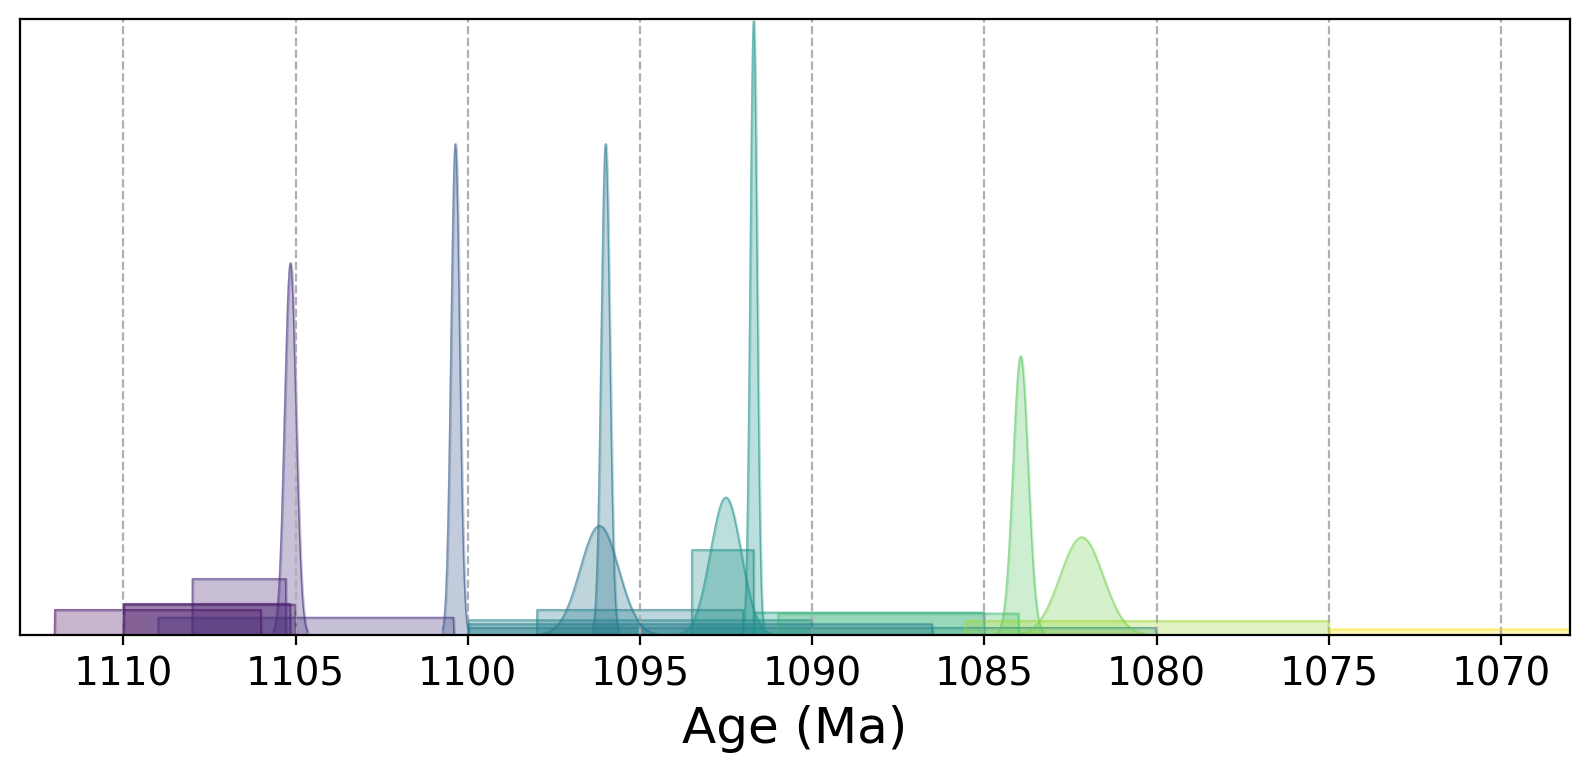

In [108]:
plt.figure(figsize = (10, 4))
for i in range(pole_means.shape[0]):
        
    max_y = 0
    if pole_means['GaussianOrUniform'][i] == 'uniform':
        x = np.linspace(pole_means['AgeLower'][i], pole_means['AgeUpper'][i], 500)
        y = np.zeros(500)
        y[(x< pole_means['AgeUpper'][i]) & (x>pole_means['AgeLower'][i])] = 1.0/(pole_means['AgeUpper'][i]-pole_means['AgeLower'][i])
        if max_y < max(y):
            max_y = max(y)

    else: 
        mu = pole_means['AgeNominal'][i]
        sigma = pole_means['Gaussian_2sigma'][i]/2

        x = np.linspace(mu-3*sigma,mu+3*sigma, 1000)
        y = st.norm.pdf(x, mu, sigma)
        if max_y < max(y):
            max_y = max(y)
    plt.plot(x, y, color = pole_means['color'][i], lw=0.5, alpha=0.5)
    plt.fill_between(x, y, color = pole_means['color'][i], alpha = 0.3)
plt.grid(1, ls='--')
plt.xlim(1068, 1113)
plt.ylim(0, 4)

plt.xlabel('Age (Ma)', fontsize=18)
# plt.ylabel('Prior\nprobability', fontsize=14)
# plt.yticks([0, 1, 2, 3, 4], fontsize=14)
plt.yticks([])
plt.xticks(fontsize=14)
plt.gca().invert_xaxis()
# plt.savefig('../figure/Keweenawan_pole_means_age_distribution.pdf', bbox_inches='tight')
plt.show()


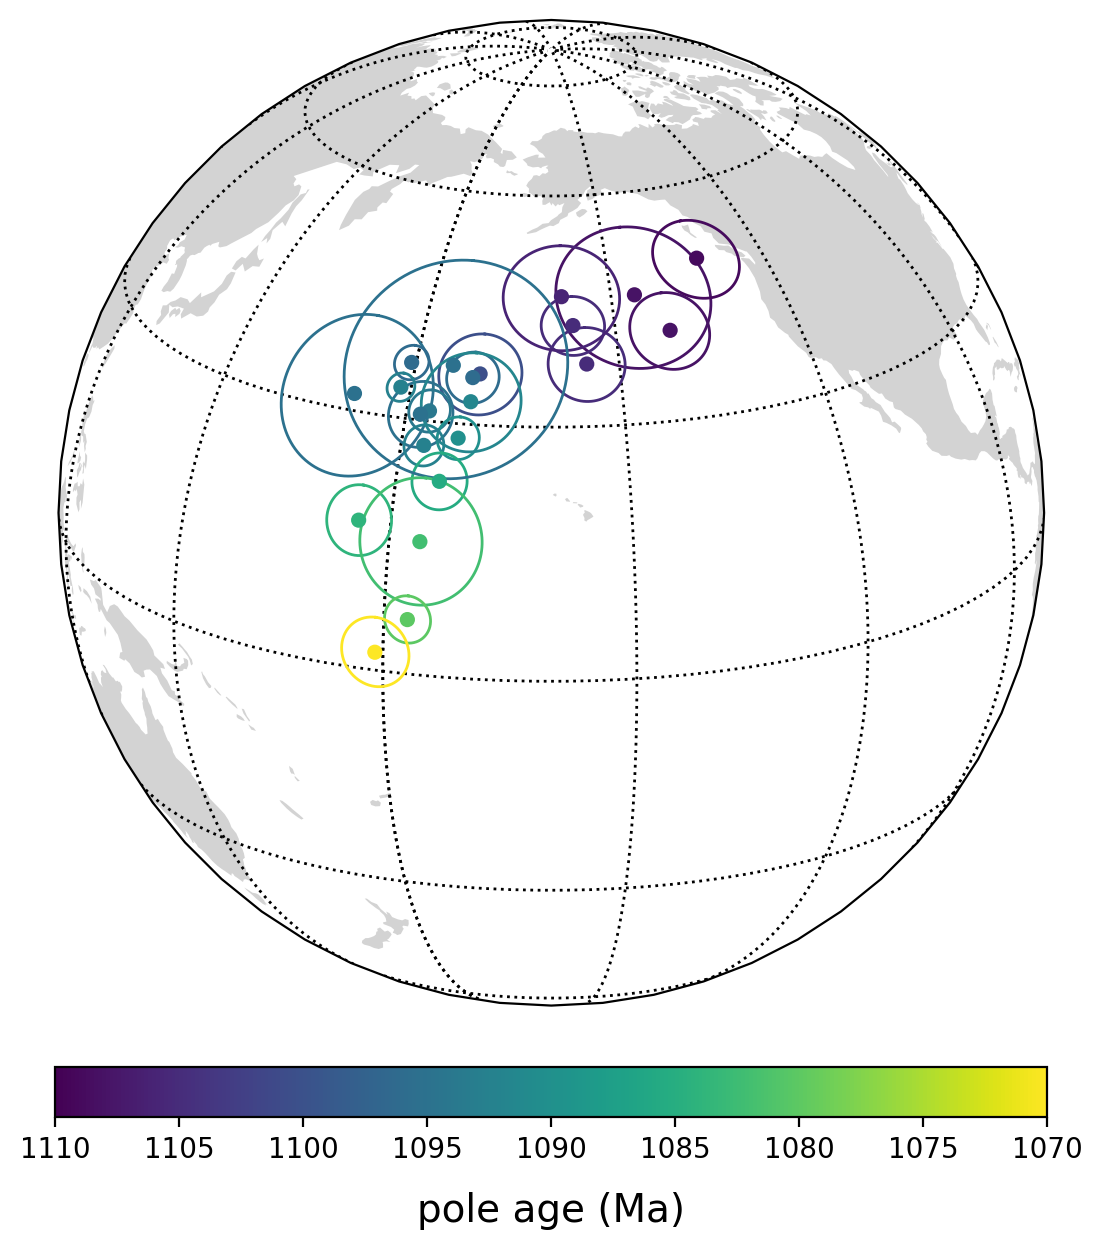

In [109]:
pole_mean_ax = ipmag.make_orthographic_map(central_latitude=20, central_longitude=200, land_edge_color=None, land_color='lightgrey')
ipmag.plot_poles_colorbar(pole_mean_ax, pole_means['PLon'], pole_means['PLat'], pole_means['A95'], colorvalues=pole_means['AgeNominal'].tolist(), 
                          vmin=1070, vmax=1110, colormap='viridis_r', edgecolor=None)
# flip the colorbar
cb = pole_mean_ax.get_figure().get_axes()[1]
cb.invert_xaxis()
cb.set_xlabel('pole age (Ma)', fontsize=14, labelpad=10)
# plt.savefig('../figure/Keweenawan_pole_means.pdf', bbox_inches='tight')
plt.show()

## Calculate formation-level running mean pole

In [110]:
def running_mean_APWP(data,window_length,spacing,max_age,min_age, central_longitude=200, central_latitude=20):
    '''
    function for calculating running mean poles at the formation level 

    Parameters
    ----------
    data : DataFrame
        paleomagnetic pole mean DataFrame
    window_length : int
        length of the running mean window in Ma
    spacing : int
        spacing of the running mean poles in Ma
    max_age : int
        maximum age of the running mean poles in Ma
    min_age : int
        minimum age of the running mean poles in Ma
    '''
    mean_pole_ages = np.arange(min_age,max_age+spacing,spacing)
    running_means = pd.DataFrame(columns=['age','N','A95','PLon','PLat'])
    for age in mean_pole_ages:
        window_min = age - (window_length/2)
        window_max = age + (window_length/2)
        poles = pole_means.loc[(data['AgeNominal'] >= window_min) & (data['AgeNominal'] <= window_max)]
        mean = ipmag.fisher_mean(dec=poles['PLon'].tolist(),inc=poles['PLat'].tolist())
        # print(mean)
        running_means.loc[age] = [age, mean['n'], mean['alpha95'], mean['dec'], mean['inc']]
        
    m = ipmag.make_orthographic_map(central_longitude=central_longitude,central_latitude=central_latitude,
                                     land_color='lightgrey',land_edge_color=None)
    ipmag.plot_vgp(m, pole_means['PLon'], pole_means['PLat'], color='black', label='underlying pole means', edge=None, alpha=0.5)

    for n in range(0,len(running_means['PLon'].tolist())):
        ipmag.plot_pole(m,running_means['PLon'].tolist()[n],
                        running_means['PLat'].tolist()[n],
                        running_means['A95'].tolist()[n],
                        marker='o',
                        color=color_mapping.to_rgba(running_means['age'].tolist()[n]), edgecolor=None)
        
    return running_means, m

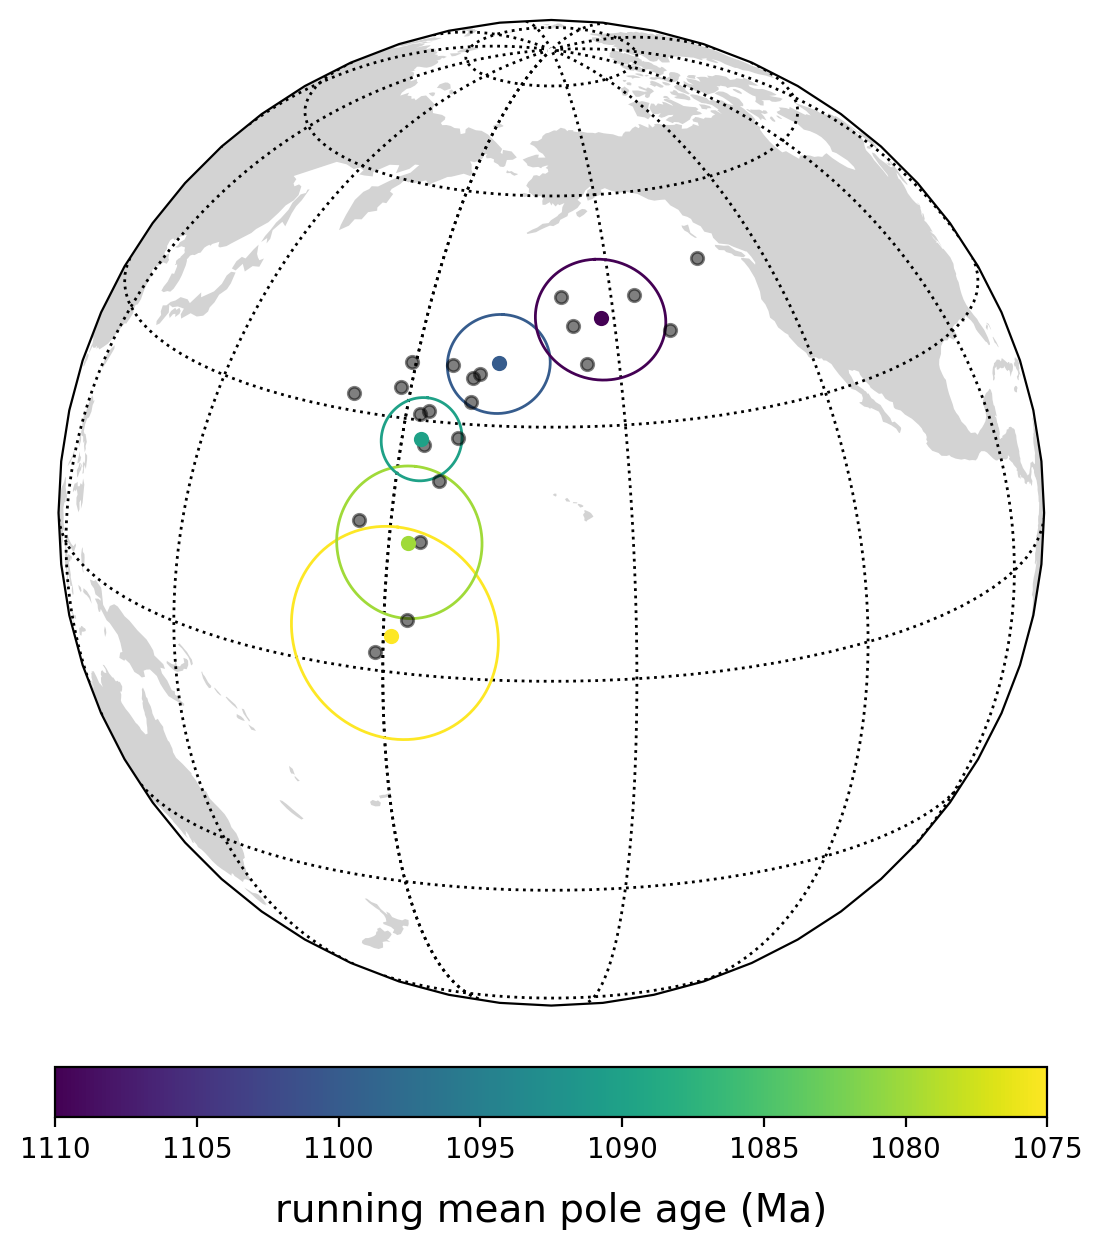

In [111]:
running_mean, running_mean_ax = running_mean_APWP(pole_means,20,10,1110,1070)
running_mean_cb = plt.colorbar(color_mapping, ax=running_mean_ax,label='Age (Ma)', orientation='horizontal', shrink=0.8, pad=0.05)
running_mean_cb.set_label('running mean pole age (Ma)', fontsize=14, labelpad=10)
# invert the colorbar
running_mean_cb.ax.invert_xaxis()
# plt.savefig('../figure/Keweenawan_running_mean_poles.pdf', bbox_inches='tight')

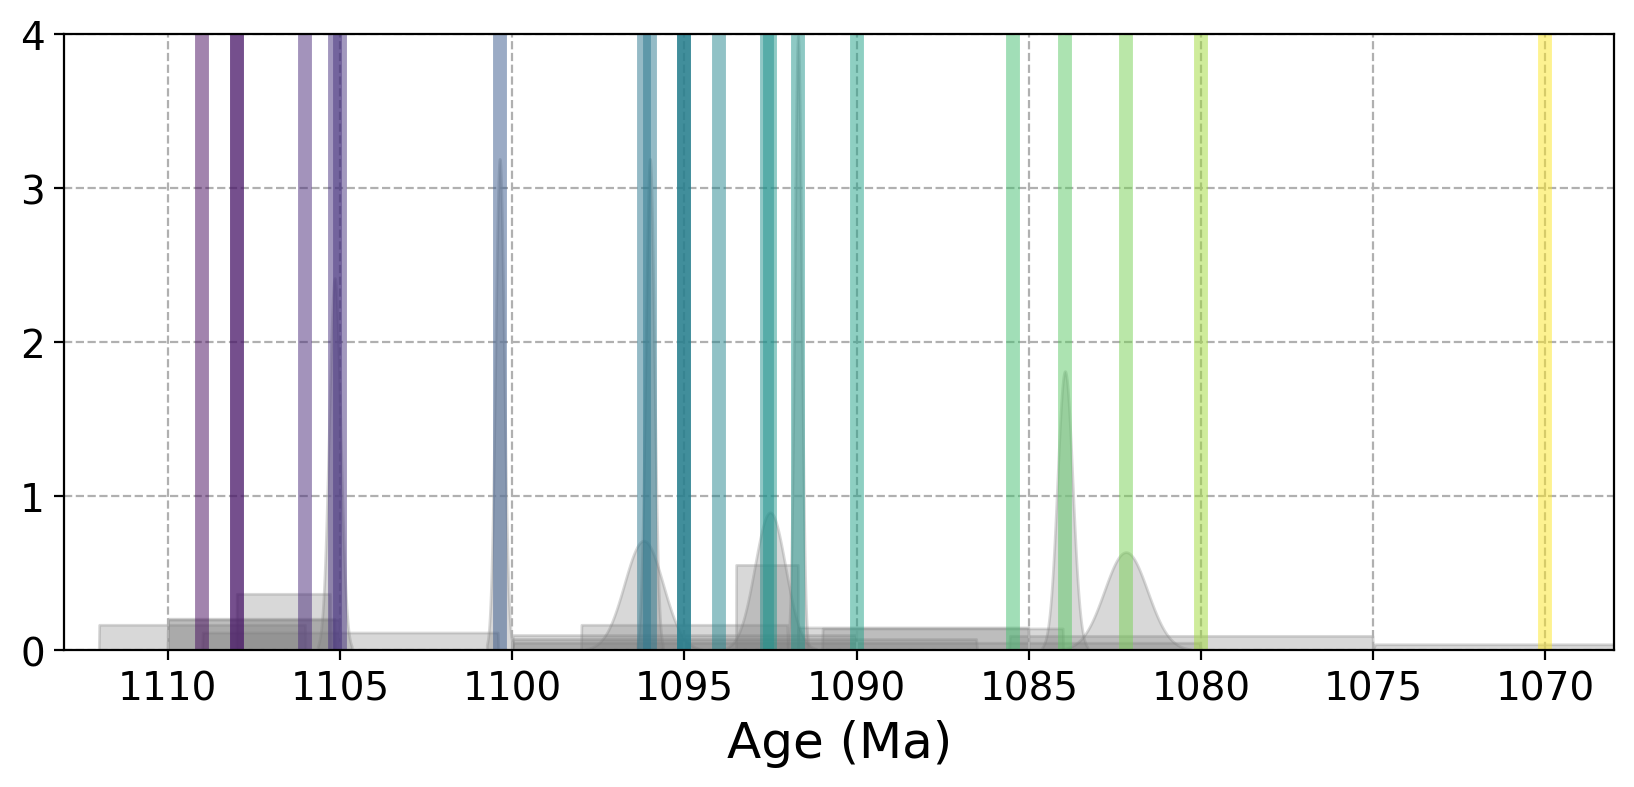

In [112]:
plt.figure(figsize = (10, 4))
for i in range(pole_means.shape[0]):
    plt.axvline(pole_means['AgeNominal'][i], color = pole_means['color'][i], lw=5, alpha=0.5)
    max_y = 0
    if pole_means['GaussianOrUniform'][i] == 'uniform':
        x = np.linspace(pole_means['AgeLower'][i], pole_means['AgeUpper'][i], 500)
        y = np.zeros(500)
        y[(x< pole_means['AgeUpper'][i]) & (x>pole_means['AgeLower'][i])] = 1.0/(pole_means['AgeUpper'][i]-pole_means['AgeLower'][i])
        if max_y < max(y):
            max_y = max(y)

    else: 
        mu = pole_means['AgeNominal'][i]
        sigma = pole_means['Gaussian_2sigma'][i]/2

        x = np.linspace(mu-3*sigma,mu+3*sigma, 1000)
        y = st.norm.pdf(x, mu, sigma)
        if max_y < max(y):
            max_y = max(y)
    # plt.plot(x, y, color = pole_means['color'][i], lw=0.5, alpha=0.5)
    plt.fill_between(x, y, color = 'grey', alpha = 0.3)
plt.grid(1, ls='--')
plt.xlim(1068, 1113)
plt.ylim(0, 4)

plt.xlabel('Age (Ma)', fontsize=18)
# plt.ylabel('Prior\nprobability', fontsize=14)
plt.yticks([0, 1, 2, 3, 4], fontsize=14)
plt.xticks(fontsize=14)
plt.gca().invert_xaxis()
# plt.savefig('../figure/Keweenawan_running_mean_age_distribution.pdf', bbox_inches='tight')
plt.show()


# overall site level data table


In [113]:
Keweenawan_track_sites = pd.concat([Osler_reverse_lower_site,
                                    Osler_reverse_upper_site,
                                    Osler_normal_site,
                                    MP_sites_lowerR1,
                                    MP_sites_lowerR2,
                                    MP_sites_lower_normal,
                                    MP_sites_upperN,
                                    Grand_portage_site,
                                    NNEU_sites,
                                    NSWU_sites,
                                    SLB_sites,
                                    PLV_sites,
                                    LST_sites,
                                    Palmer1986_PM_reliable,
                                    Palmer1987_QM_sites,
                                    Fairchild_Palmer_MIF_data,
                                    SWLLIP_data,
                                    Duluth_Complex_data,
                                    Zhang2021_data,
                                    Pierce2022_data,
                                    Zhang2024_Cardenas,
                                    Slotznick2023_data,
                                    Henry1977_data,
                                    ]).reset_index(drop=True)

Keweenawan_track_sites = Keweenawan_track_sites[['pole_name', 'citations', 'location', 'site', 'lat', 'lon', 'age', 'age_high', 'age_low', 'age_unit',
                                                 'age_uncertainty','dir_dec', 'dir_inc', 'dir_k', 'dir_f', 'dir_alpha95', 'dir_r','dir_tilt_correction', 
                                                 'dir_polarity', 'dir_n_specimens', 'dir_n_samples', 'vgp_lat', 'vgp_lon', 'vgp_lat_rev', 'vgp_lon_rev',
                                                'vgp_dm', 'vgp_dp', 'geologic_classes', 'lithologies','geologic_types', 'age_model', 'height_type', 
                                                'height', 'height_upper', 'height_lower']]

Keweenawan_track_sites['dir_dec'] = Keweenawan_track_sites['dir_dec'].astype(np.float64)
Keweenawan_track_sites['dir_inc'] = Keweenawan_track_sites['dir_inc'].astype(np.float64)
Keweenawan_track_sites['lat'] = Keweenawan_track_sites['lat'].astype(np.float64)
Keweenawan_track_sites['lon'] = Keweenawan_track_sites['lon'].astype(np.float64)
Keweenawan_track_sites = ipmag.vgp_calc(Keweenawan_track_sites, tilt_correction='yes', site_lon='lon', site_lat='lat', dec_tc='dir_dec', inc_tc='dir_inc')
Keweenawan_track_sites['Plon'] = None
Keweenawan_track_sites['Plat'] = None
Keweenawan_track_sites['Plon'] = np.where(Keweenawan_track_sites['dir_polarity']== 'n', Keweenawan_track_sites['vgp_lon'], Keweenawan_track_sites['vgp_lon_rev'])
Keweenawan_track_sites['Plon'] = Keweenawan_track_sites['Plon']%360
Keweenawan_track_sites['Plat'] = np.where(Keweenawan_track_sites['dir_polarity']== 'n', Keweenawan_track_sites['vgp_lat'], Keweenawan_track_sites['vgp_lat_rev'])
Keweenawan_track_sites.head()

,pole_name,citations,location,site,lat,lon,age,age_high,age_low,age_unit,age_uncertainty,dir_dec,dir_inc,dir_k,dir_f,dir_alpha95,dir_r,dir_tilt_correction,dir_polarity,dir_n_specimens,dir_n_samples,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev,vgp_dm,vgp_dp,geologic_classes,lithologies,geologic_types,age_model,height_type,height,height_upper,height_lower,paleolatitude,Plon,Plat
0,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(11.8 to 26.4),48.8122,272.3380,1108.0,1110.0,1105.15,Ma,uniform,79.7,-70.5,384.087791,1.0,2.7,NaN,100,r,7.0,7.0,-33.098356,49.588330,33.098356,229.588330,NaN,NaN,Extrusive:Igneous,Basalt,Lava Flow,Osler Volcanic Group,exact,11.8,None,None,-54.692457,229.588330,33.098356
1,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(116.3 to 118.8),48.8062,272.3366,1108.0,1110.0,1105.15,Ma,uniform,74.1,-70.3,79.752604,1.0,6.4,NaN,100,r,6.0,6.0,-30.447349,51.831739,30.447349,231.831739,NaN,NaN,Extrusive:Igneous,Basalt,Lava Flow,Osler Volcanic Group,exact,116.3,None,None,-54.393410,231.831739,30.447349
2,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(119.7 to 122.1),48.8060,272.3366,1108.0,1110.0,1105.15,Ma,uniform,87.5,-68.9,84.775087,1.0,6.8,NaN,100,r,5.0,5.0,-35.321456,43.912252,35.321456,223.912252,NaN,NaN,Extrusive:Igneous,Basalt,Lava Flow,Osler Volcanic Group,exact,119.7,None,None,-52.341346,223.912252,35.321456
3,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(122.1 to 123.7),48.8058,272.3367,1108.0,1110.0,1105.15,Ma,uniform,75.7,-69.1,136.054422,1.0,4.9,NaN,100,r,6.0,6.0,-29.952660,49.585495,29.952660,229.585495,NaN,NaN,Extrusive:Igneous,Basalt,Lava Flow,Osler Volcanic Group,exact,122.1,None,None,-52.630096,229.585495,29.952660
4,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(28.3 to 29.2),48.8107,272.3377,1108.0,1110.0,1105.15,Ma,uniform,109.8,-66.8,184.089415,1.0,3.9,NaN,100,r,7.0,7.0,-45.769076,30.954452,45.769076,210.954452,NaN,NaN,Extrusive:Igneous,Basalt,Lava Flow,Osler Volcanic Group,exact,28.3,None,None,-49.396782,210.954452,45.769076


In [114]:
Keweenawan_track_sites.to_csv('../data/pmag_compiled/Keweenawan_track_sites.csv', index=False)

In [115]:
Keweenawan_track_sites.iloc[777]

pole_name                  Nonesuch Formation
citations              Slotznick et al., 2023
location                   Potato River Falls
site                                 PF18-100
lat                                  46.46082
lon                                 269.47086
age                                    1080.0
age_high                              1085.57
age_low                                1075.0
age_unit                                   Ma
age_uncertainty                       uniform
dir_dec                                 271.1
dir_inc                                   7.1
dir_k                              439.504415
dir_f                                resample
dir_alpha95                             6.678
dir_r                                     NaN
dir_tilt_correction                     100.0
dir_polarity                                n
dir_n_specimens                             1
dir_n_samples                               1
vgp_lat                           

In [116]:
Keweenawan_track_sites = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites.csv')
Keweenawan_track_sites_igneous = Keweenawan_track_sites[~Keweenawan_track_sites['geologic_classes'].str.contains('Sedimentary')].reset_index(drop=1)
Keweenawan_track_sites_sedimentary = Keweenawan_track_sites[Keweenawan_track_sites['geologic_classes'].str.contains('Sedimentary')].reset_index(drop=1)

In [117]:
Keweenawan_track_sites_sedimentary['pole_name'].unique()

array(['Cut Face Creek Sandstone', 'Nonesuch Formation',
       'Freda Formation'], dtype=object)

In [118]:
Keweenawan_track_sites_igneous['pole_name'].unique()

array(['Osler reverse lower', 'Osler reverse upper', 'Osler normal',
       'Mamainse lower R1', 'Mamainse lower R2', 'Mamainse lower normal',
       'Mamainse upper normal', 'Grand Portage Basalts',
       'North Shore Volcanic Group (upper NE sequence)',
       'North Shore Volcanic Group (upper SW sequence)',
       'Schroeder Lutsen Basalts', 'Portage Lake Volcanics',
       'Lake Shore Traps', 'Powder Mill Group Volcanics',
       'Quebec Mine Member (Michipicoten Island)',
       'Michipicoten Island Formation', 'SWLLIP', 'Duluth Complex',
       'Beaver River diabase', 'Cardenas Basalt'], dtype=object)

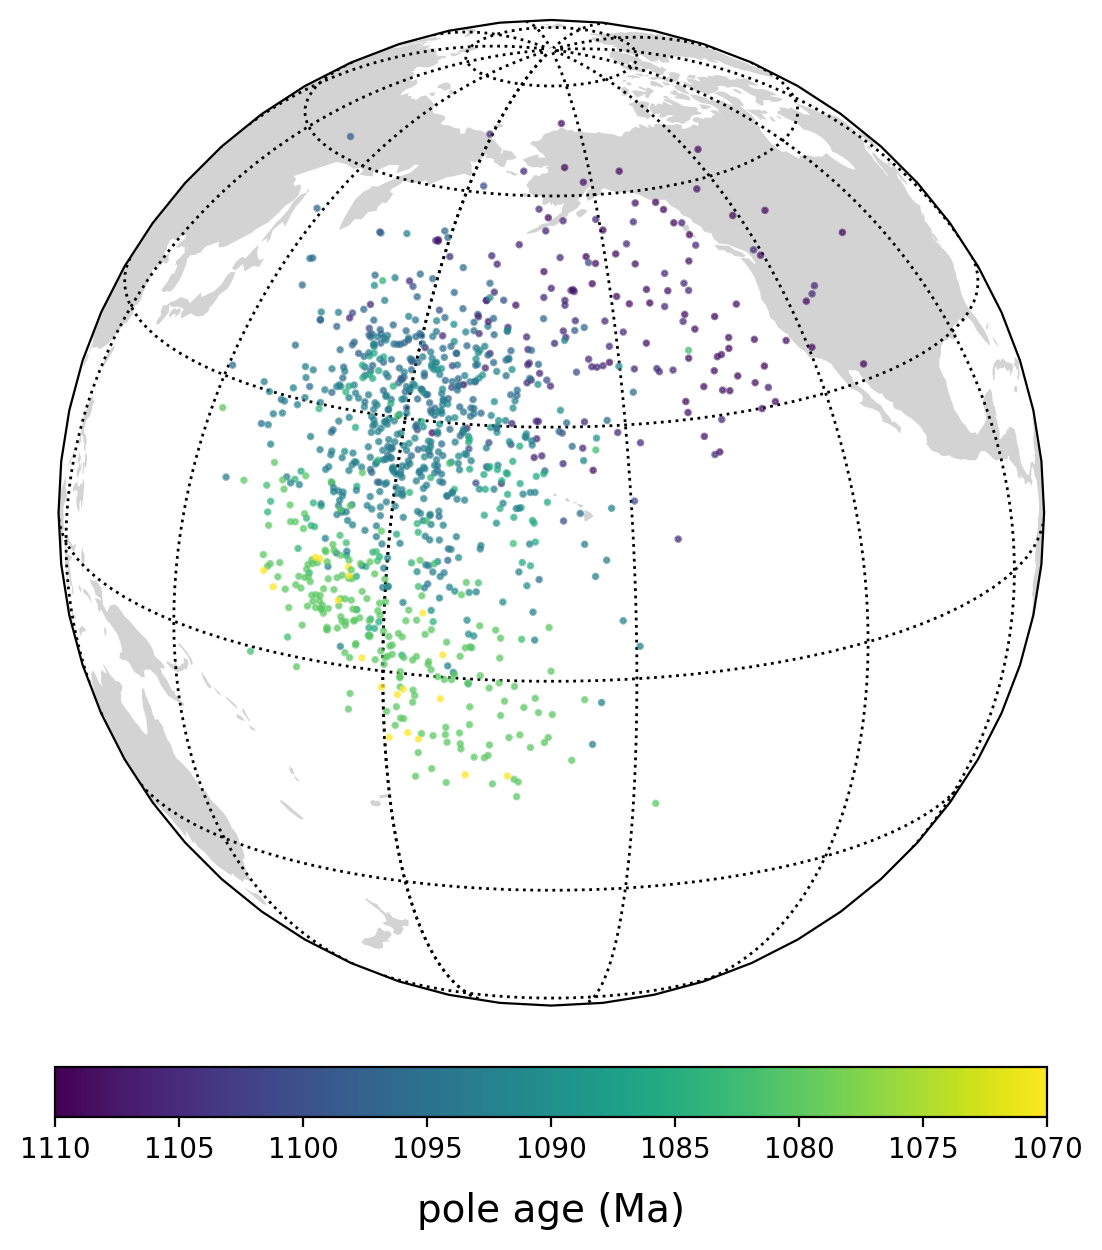

In [119]:
all_sites_ax = ipmag.make_orthographic_map(200, 20, land_color='lightgrey', land_edge_color=None)
ipmag.plot_poles_colorbar(all_sites_ax, Keweenawan_track_sites['Plon'], Keweenawan_track_sites['Plat'], 
                          np.zeros(Keweenawan_track_sites.shape[0]), Keweenawan_track_sites['age'], 
                          vmin=1070, vmax=1110, colormap='viridis_r', edgecolor=None, alpha=0.6, markersize=3)
# flip the colorbar
cb = all_sites_ax.get_figure().get_axes()[1]
cb.invert_xaxis()
cb.set_xlabel('pole age (Ma)', fontsize=14, labelpad=10)
# plt.savefig('../figure/Keweenawan_VGPs.pdf', bbox_inches='tight')
plt.show()